# Matrix Profile Prototype for Financial Motif Discovery

This notebook is a fast prototype for studying motif discovery in BTCUSDT 1-minute financial time series.

The main goal is to understand whether Matrix Profile can identify repeated local market patterns in a way that is visually interpretable and experimentally reproducible.

This prototype intentionally uses a small time slice so that the full workflow can be executed quickly. Later, the same structure can be scaled to longer periods, different assets, different window sizes, and richer feature representations.

In this notebook, I focus on four practical questions:

1. Can repeated price patterns be detected from raw close prices?
2. Can the detected motifs be visually verified?
3. Do the motif windows show similar returns, ranges, drawdowns, and volume behavior?
4. Can this workflow be cached and reused efficiently for larger thesis experiments?

The long-term thesis direction is to compare raw, univariate feature-based, and multivariate motif discovery under changing market regimes.

Below notebooks aggregates and illustrates the Matrix Profiling Methodology for specific asset, for now the cells are ran on short timeframes to see the reasult.

| Part         |                 Full thesis run |         Quick notebook run |
| ------------ | ------------------------------: | -------------------------: |
| Data         |         Full 2025 or multi-year |           1 week / 1 month |
| Window sweep |                 Many `m` values |               One `m` only |
| Motifs       |                  Top 15 or more |                      Top 3 |
| Methods      | STUMP + MSTUMP + events + plots | One or two selected blocks |
| Recompute MP |                      Every time |     Save and reload `.npz` |
| Plots        |                       All plots |       Only essential plots |


# Notebook Index

## 1. Configuration & Data

| Cell | Title | Description |
|---|---|---|
| 1 | Configuration | Set asset, timeframe, window size, paths |
| 2 | Data Loading | Load OHLCV + feature columns |
| 3 | Data Cleaning | Build clean analysis dataframe |
| 4 | Data Slicing | Apply RUN_MODE (quick timeframe) |
| 5 | Initial Plot | Visualize price series |

---

## 2. Matrix Profile

| Cell | Title | Description |
|---|---|---|
| 6 | Cache Setup | Prepare cache path |
| 7 | MP Computation | Compute Matrix Profile (STUMP) |
| 8 | MP Summary | Validate and inspect MP |

---

## 3. Motif Discovery

| Cell | Title | Description |
|---|---|---|
| 9 | Top-K Motifs | Extract non-overlapping motifs |
| 10 | MP Visualization | Plot MP with motifs and neighbors |
| 11 | Motif Windows | Plot motifs on price chart |
| 12 | Shape Comparison | Z-normalized motif overlays |

---

## 4. Motif Statistics

| Cell | Title | Description |
|---|---|---|
| 13 | Movement Stats | Returns, range, drawdown, volume |
| 14 | Consistency Score | Compute 0–10 motif quality score |
| 15 | Score Interpretation | Explain motif strength |

---

## 5. Advanced Visualization

| Cell | Title | Description |
|---|---|---|
| 16 | Score Visualization | Bar chart + heatmap |
| 17 | Boxplots | Distribution of motif behavior |
| 18 | Pattern Space | Distance matrix + PCA |

---

## 6. Sensitivity Analysis

| Cell | Title | Description |
|---|---|---|
| 19 | Window Study | m = 15, 30, 60, 120 |
| 20 | Window Plots | Visualize sensitivity results |

---

## 7. Extended Motifs

| Cell | Title | Description |
|---|---|---|
| 21 | Top-15 Motifs | Extract extended motif set |
| 22 | Timing Analysis | Motif occurrences over time |

---

## 8. Representation Comparison

| Cell | Title | Description |
|---|---|---|
| 23 | Raw vs Returns | Motif discovery comparison |
| 24 | Comparison Plots | Distance + distribution |
| 25 | Overlap Analysis | Tolerance-based matching |

---

## 9. Multivariate Analysis

| Cell | Title | Description |
|---|---|---|
| 26 | Feature Setup | log_return + volatility |
| 27 | MSTUMP | Multivariate MP computation |
| 28 | Multivariate Motifs | Extract and summarize motifs |

---

## 10. Final Output

| Cell | Title | Description |
|---|---|---|
| 29 | Representation Compare | Raw vs uni vs multi |
| 30 | Save Results | Export + scalability plan |

---

## Scope Covered

- Matrix Profile motif discovery  
- Financial interpretation of motifs  
- Consistency scoring  
- Window-size sensitivity  
- Representation effects  
- Multivariate extension  
- Scalable pipeline  

---

End of Index

In [2]:
# ============================================================
# CELL 1: NOTEBOOK CONFIGURATION AND IMPORTS
# ============================================================

from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Main notebook controls
# ------------------------------------------------------------

ASSET = "BTCUSDT"

# Use "quick" for fast prototype.
# Later use "medium" or "full" for serious thesis runs.
RUN_MODE = "quick"          # options: "quick", "medium", "full"

# If False, previously computed matrix profiles are loaded from cache.
# If True, matrix profiles are recomputed.
FORCE_RECOMPUTE = False

# ------------------------------------------------------------
# Analysis type
# ------------------------------------------------------------

# "raw_close" = baseline motifs on close price
# "feature"   = motifs on engineered feature such as log_return
ANALYSIS_TYPE = "raw_close"      # options: "raw_close", "feature"

# Feature used when ANALYSIS_TYPE = "feature"
FEATURE = "log_return"

# ------------------------------------------------------------
# Window and motif controls
# ------------------------------------------------------------

# Since data is 1-minute, m=60 means 60-minute motifs.
WINDOW_MINUTES = 60

# Use 3 for prototype. Later change to 15.
TOP_K_MOTIFS = 3

# ------------------------------------------------------------
# Time slicing
# ------------------------------------------------------------

# For quick visual experiments, keep this small.
# Later you only change these dates.
TIME_SLICE = {
    "quick": {
        "start": "2025-01-01",
        "end": "2025-01-08",
    },
    "medium": {
        "start": "2025-01-01",
        "end": "2025-03-01",
    },
    "full": {
        "start": None,
        "end": None,
    },
}

# ------------------------------------------------------------
# Optional switches for later notebook sections
# ------------------------------------------------------------

RUN_RAW_CLOSE_MOTIFS = True
RUN_FEATURE_MOTIFS = True

RUN_MATRIX_PROFILE_PLOT = True
RUN_MOTIF_LOCATION_PLOT = True
RUN_NORMALIZED_OVERLAY_PLOT = True
RUN_MOTIF_CALENDAR_PLOT = True

RUN_EVENT_CHECKS = False
RUN_REGIME_CHECKS = False
RUN_VIX_CHECKS = False

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()

# This tries to find the repo root whether you run from repo root
# or from inside notebooks/MP_Study_Summary.
possible_roots = [
    NOTEBOOK_DIR,
    NOTEBOOK_DIR.parent,
    NOTEBOOK_DIR.parent.parent,
    NOTEBOOK_DIR.parent.parent.parent,
]

PROJECT_ROOT = None

for root in possible_roots:
    if (root / "data").exists() and (root / "notebooks").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find project root. Make sure the notebook is inside the MastersThesis repo."
    )

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "crypto" / "1min" / f"{ASSET}_1m_processed.parquet"

CACHE_DIR = PROJECT_ROOT / "data" / "processed" / "matrix_profiles"
RESULTS_DIR = PROJECT_ROOT / "reports" / "results" / "MP_Study_Summary_short"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Derived config
# ------------------------------------------------------------

START_DATE = TIME_SLICE[RUN_MODE]["start"]
END_DATE = TIME_SLICE[RUN_MODE]["end"]

if ANALYSIS_TYPE == "raw_close":
    TARGET_COLUMN = "close"
else:
    TARGET_COLUMN = FEATURE

RUN_CONFIG = {
    "asset": ASSET,
    "run_mode": RUN_MODE,
    "analysis_type": ANALYSIS_TYPE,
    "target_column": TARGET_COLUMN,
    "window_minutes": WINDOW_MINUTES,
    "top_k_motifs": TOP_K_MOTIFS,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "force_recompute": FORCE_RECOMPUTE,
    "data_path": str(DATA_PATH),
    "cache_dir": str(CACHE_DIR),
    "results_dir": str(RESULTS_DIR),
}

print("Notebook configuration loaded successfully.")
print(json.dumps(RUN_CONFIG, indent=2))

Notebook configuration loaded successfully.
{
  "asset": "BTCUSDT",
  "run_mode": "quick",
  "analysis_type": "raw_close",
  "target_column": "close",
  "window_minutes": 60,
  "top_k_motifs": 3,
  "start_date": "2025-01-01",
  "end_date": "2025-01-08",
  "force_recompute": false,
  "data_path": "c:\\Users\\learn\\OneDrive\\Desktop\\Masters Thesis\\MastersThesis\\data\\processed\\crypto\\1min\\BTCUSDT_1m_processed.parquet",
  "cache_dir": "c:\\Users\\learn\\OneDrive\\Desktop\\Masters Thesis\\MastersThesis\\data\\processed\\matrix_profiles",
  "results_dir": "c:\\Users\\learn\\OneDrive\\Desktop\\Masters Thesis\\MastersThesis\\reports\\results\\MP_Study_Summary_short"
}


## Notebook Configuration

This notebook is designed to be controlled from one configuration cell.

The most important parameters are:

| Parameter | Meaning |
|---|---|
| `RUN_MODE` | Controls whether the notebook runs on a small sample or a larger dataset |
| `ANALYSIS_TYPE` | Decides whether motifs are extracted from raw close prices or engineered features |
| `TARGET_COLUMN` | The actual time series used for Matrix Profile computation |
| `WINDOW_MINUTES` | The subsequence length. Since the data is 1-minute, `m=60` means 60-minute patterns |
| `TOP_K_MOTIFS` | Number of motif pairs extracted for inspection |
| `START_DATE`, `END_DATE` | The selected time range for the experiment |
| `FORCE_RECOMPUTE` | If `False`, the notebook loads a cached Matrix Profile when available |

This structure is important because motif discovery can become computationally expensive on multi-year minute-level data. By making the timeframe, feature, and window size configurable, the same notebook can be used both for quick development and for larger benchmark experiments.

Load and inspect BTCUSDT 1-minute data

## Loading BTCUSDT 1-Minute Data

The dataset used here is processed BTCUSDT 1-minute OHLCV data.

Each row represents one minute of trading activity and contains:

| Column | Meaning |
|---|---|
| `open` | First traded price in the minute |
| `high` | Highest traded price in the minute |
| `low` | Lowest traded price in the minute |
| `close` | Last traded price in the minute |
| `volume` | Total traded volume in the minute |
| `log_return` | Logarithmic return from one minute to the next |
| `volatility_*` | Rolling volatility features over different windows |

The raw dataset is large, covering several years of minute-level trading data. For this prototype, I load the full processed file but only analyze a small slice. This keeps the notebook fast while preserving the same workflow that can later be applied to the full dataset.

In [3]:
# ============================================================
# CELL 2: LOAD AND INSPECT BTCUSDT 1-MINUTE DATA
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

df_raw = pd.read_parquet(DATA_PATH)

print("Data loaded successfully.")
print(f"Raw shape: {df_raw.shape}")
print("\nColumns:")
print(list(df_raw.columns))

# ------------------------------------------------------------
# Basic timestamp validation
# ------------------------------------------------------------

if "timestamp" not in df_raw.columns:
    raise ValueError("Expected column 'timestamp' not found in dataframe.")

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], utc=True, errors="coerce")
df_raw = df_raw.dropna(subset=["timestamp"])
df_raw = df_raw.sort_values("timestamp").drop_duplicates(subset=["timestamp"])
df_raw = df_raw.reset_index(drop=True)

print("\nTimestamp range:")
print("Start:", df_raw["timestamp"].min())
print("End:  ", df_raw["timestamp"].max())

# ------------------------------------------------------------
# Basic OHLCV validation
# ------------------------------------------------------------

expected_cols = ["open", "high", "low", "close", "volume"]
missing_cols = [col for col in expected_cols if col not in df_raw.columns]

if missing_cols:
    print("\nWarning: Missing expected OHLCV columns:", missing_cols)
else:
    print("\nOHLCV columns found.")

for col in expected_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

# ------------------------------------------------------------
# Quick data quality summary
# ------------------------------------------------------------

summary_df = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [str(df_raw[col].dtype) for col in df_raw.columns],
    "missing_values": [df_raw[col].isna().sum() for col in df_raw.columns],
    "missing_pct": [round(df_raw[col].isna().mean() * 100, 4) for col in df_raw.columns],
})

display(summary_df)

print("\nPreview:")
display(df_raw.head())

Data loaded successfully.
Raw shape: (4502648, 12)

Columns:
['timestamp', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'volatility_240m', 'realized_volatility_60m']

Timestamp range:
Start: 2017-08-17 04:00:00+00:00
End:   2026-03-15 23:59:00+00:00

OHLCV columns found.


,column,dtype,missing_values,missing_pct
0,timestamp,"datetime64[ms, UTC]",0,0.0000
1,open,float64,0,0.0000
2,high,float64,0,0.0000
3,low,float64,0,0.0000
4,close,float64,0,0.0000
5,volume,float64,0,0.0000
6,log_return,float64,1,0.0000
7,pct_return,float64,1,0.0000
8,volatility_30m,float64,30,0.0007
9,volatility_60m,float64,60,0.0013



Preview:


,timestamp,open,high,low,close,volume,log_return,pct_return,volatility_30m,volatility_60m,volatility_240m,realized_volatility_60m
0,2017-08-17 04:00:00+00:00,4261.48,4261.48,4261.48,4261.48,1.775183,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-08-17 04:01:00+00:00,4261.48,4261.48,4261.48,4261.48,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
2,2017-08-17 04:02:00+00:00,4280.56,4280.56,4280.56,4280.56,0.261074,0.004467,0.004477,NaN,NaN,NaN,NaN
3,2017-08-17 04:03:00+00:00,4261.48,4261.48,4261.48,4261.48,0.012008,-0.004467,-0.004457,NaN,NaN,NaN,NaN
4,2017-08-17 04:04:00+00:00,4261.48,4261.48,4261.48,4261.48,0.140796,0.000000,0.000000,NaN,NaN,NaN,NaN


Apply time slice and build analysis dataframe

## Time Slice Selection

The full BTCUSDT dataset contains millions of 1-minute observations. Running Matrix Profile on the full dataset every time would be inefficient during development.

For this prototype, I select a short time interval:

- Start: `2025-01-01`
- End: `2025-01-08`
- Frequency: 1-minute
- Approximate rows: 7 days × 1440 minutes = 10,080 rows

This is large enough to demonstrate motif discovery but small enough to run quickly.

Later, the same notebook can be scaled simply by changing the timeframe. For example:

| Use case | Timeframe |
|---|---|
| Quick visual prototype | 7 days |
| Medium experiment | 1 to 3 months |
| Thesis benchmark | Multiple years |
| Full robustness study | Full available history |

This makes the workflow flexible and reproducible.


In [4]:
# ============================================================
# CELL 3: APPLY TIME SLICE AND BUILD ANALYSIS DATAFRAME
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Apply selected time slice
# ------------------------------------------------------------

if START_DATE is not None:
    start_ts = pd.Timestamp(START_DATE, tz="UTC")
    df = df[df["timestamp"] >= start_ts]

if END_DATE is not None:
    end_ts = pd.Timestamp(END_DATE, tz="UTC")
    df = df[df["timestamp"] < end_ts]

df = df.sort_values("timestamp").reset_index(drop=True)

if df.empty:
    raise ValueError(
        f"No data found for selected slice: start={START_DATE}, end={END_DATE}"
    )

# ------------------------------------------------------------
# Validate target column
# ------------------------------------------------------------

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' not found. Available columns: {list(df.columns)}"
    )

# ------------------------------------------------------------
# Build clean analysis dataframe
# Avoid duplicate columns when TARGET_COLUMN is already 'close'
# ------------------------------------------------------------

base_cols = ["timestamp", "open", "high", "low", "close", "volume"]

analysis_cols = base_cols.copy()
if TARGET_COLUMN not in analysis_cols:
    analysis_cols.append(TARGET_COLUMN)

analysis_df = df[analysis_cols].copy()

analysis_df[TARGET_COLUMN] = pd.to_numeric(analysis_df[TARGET_COLUMN], errors="coerce")
analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan)
analysis_df = analysis_df.dropna(subset=[TARGET_COLUMN])
analysis_df = analysis_df.reset_index(drop=True)

# ------------------------------------------------------------
# Convert target series for Matrix Profile
# ------------------------------------------------------------

series = analysis_df[TARGET_COLUMN].astype(float).to_numpy()
timestamps = analysis_df["timestamp"].reset_index(drop=True)

m = int(WINDOW_MINUTES)

if len(series) <= m:
    raise ValueError(
        f"Series length {len(series)} is too small for window size m={m}. "
        "Use a longer time slice or smaller WINDOW_MINUTES."
    )

# ------------------------------------------------------------
# Slice summary
# ------------------------------------------------------------

slice_summary = {
    "run_mode": RUN_MODE,
    "analysis_type": ANALYSIS_TYPE,
    "target_column": TARGET_COLUMN,
    "rows_after_slice": int(len(analysis_df)),
    "start": str(analysis_df["timestamp"].min()),
    "end": str(analysis_df["timestamp"].max()),
    "window_minutes": int(WINDOW_MINUTES),
    "subsequence_count": int(len(series) - m + 1),
    "top_k_motifs": int(TOP_K_MOTIFS),
}

print("Analysis dataframe created successfully.")
print(json.dumps(slice_summary, indent=2))

display(analysis_df.head())

Analysis dataframe created successfully.
{
  "run_mode": "quick",
  "analysis_type": "raw_close",
  "target_column": "close",
  "rows_after_slice": 10080,
  "start": "2025-01-01 00:00:00+00:00",
  "end": "2025-01-07 23:59:00+00:00",
  "window_minutes": 60,
  "subsequence_count": 10021,
  "top_k_motifs": 3
}


,timestamp,open,high,low,close,volume
0,2025-01-01 00:00:00+00:00,93576.00,93610.93,93537.50,93610.93,8.21827
1,2025-01-01 00:01:00+00:00,93610.93,93652.00,93606.20,93652.00,12.14029
2,2025-01-01 00:02:00+00:00,93652.00,93702.15,93635.98,93702.15,11.60597
3,2025-01-01 00:03:00+00:00,93702.14,93702.15,93654.48,93677.98,8.72958
4,2025-01-01 00:04:00+00:00,93677.98,93677.99,93659.92,93661.20,5.24749


## Visual Check of the Selected Market Period

Before computing motifs, I first visualize the selected price period.

This is a necessary sanity check because Matrix Profile will search for repeated subsequences inside this selected interval. If the chosen window contains unusual jumps, flat periods, or missing data, the motifs may be affected.

This plot helps answer:

- What market phase are we analyzing?
- Is the selected slice trending, ranging, or volatile?
- Are there obvious jumps or structural changes?
- Is the slice suitable for a fast prototype run?

For raw-close motif discovery, this visual context is especially important because the algorithm operates directly on the price-level series.

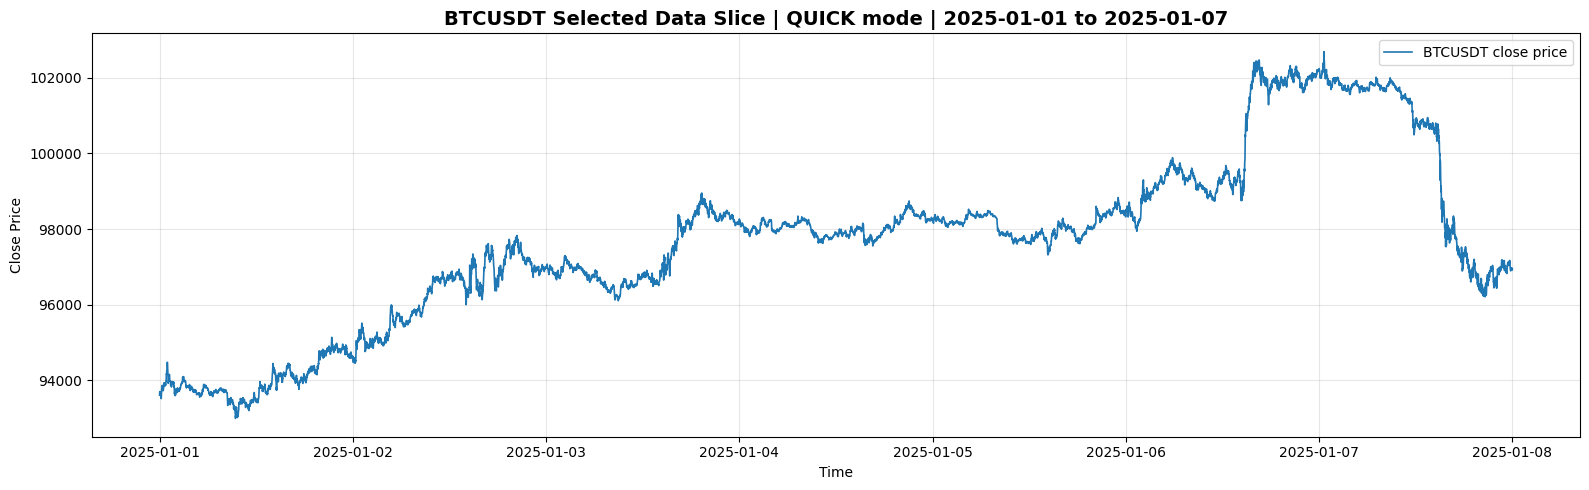

Selected slice plotted successfully.


In [5]:
# ============================================================
# CELL 4: VISUALIZE SELECTED DATA SLICE
# ============================================================

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    analysis_df["timestamp"],
    analysis_df["close"],
    linewidth=1.2,
    label="BTCUSDT close price"
)

ax.set_title(
    f"{ASSET} Selected Data Slice | {RUN_MODE.upper()} mode | "
    f"{analysis_df['timestamp'].min().date()} to {analysis_df['timestamp'].max().date()}",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("Close Price")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("Selected slice plotted successfully.")

| ☝🏻What it shows                    | Why it matters                                             |
| -------------------------------- | ---------------------------------------------------------- |
| Close price over selected period | Lets us see the market context before motifs               |
| 7-day quick slice                | Confirms we are not running full decade data               |
| Baseline visual                  | Later motif windows will be highlighted on this same chart |


## Matrix Profile Caching

Matrix Profile computation is the most expensive step in this notebook.

To avoid recomputing the same Matrix Profile repeatedly, I save the computed profile to disk as a compressed `.npz` file.

The cache stores:

| Object | Meaning |
|---|---|
| `mp` | Matrix Profile values |
| `mpi` | Nearest-neighbor indices |
| `series` | Input time series used for computation |
| `timestamps` | Timestamp alignment for the series |
| Metadata | Asset, feature, window size, run mode, and date range |

This is important for two reasons:

1. **Speed**: The first run computes the profile, later runs load it instantly.
2. **Reproducibility**: Every cached file is tied to a specific asset, feature, window size, and time range.

This design will be very useful later when comparing raw close, log-return, volatility-based, and multivariate motif discovery experiments.


In [6]:
# ============================================================
# CELL 5: MATRIX PROFILE CACHE HELPERS
# ============================================================

def safe_name(text):
    """
    Convert text into a safe filename component.
    """
    return (
        str(text)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "-")
    )


def make_mp_cache_path(
    asset,
    analysis_type,
    target_column,
    window_minutes,
    run_mode,
    start_date,
    end_date,
):
    """
    Build a unique cache filename for the current Matrix Profile run.
    """
    start_part = "full_start" if start_date is None else safe_name(start_date)
    end_part = "full_end" if end_date is None else safe_name(end_date)

    filename = (
        f"{safe_name(asset)}_"
        f"{safe_name(analysis_type)}_"
        f"{safe_name(target_column)}_"
        f"m{int(window_minutes)}_"
        f"{safe_name(run_mode)}_"
        f"{start_part}_to_{end_part}.npz"
    )

    return CACHE_DIR / filename


def save_mp_cache(cache_path, **arrays):
    """
    Save Matrix Profile arrays and metadata to compressed .npz.
    """
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(cache_path, **arrays)
    print(f"Saved Matrix Profile cache:\n{cache_path}")


def load_mp_cache(cache_path):
    """
    Load Matrix Profile cache if it exists.
    """
    cache_path = Path(cache_path)

    if cache_path.exists():
        print(f"Loaded Matrix Profile cache:\n{cache_path}")
        return np.load(cache_path, allow_pickle=True)

    print("No cache found. Matrix Profile will be computed.")
    return None


mp_cache_path = make_mp_cache_path(
    asset=ASSET,
    analysis_type=ANALYSIS_TYPE,
    target_column=TARGET_COLUMN,
    window_minutes=WINDOW_MINUTES,
    run_mode=RUN_MODE,
    start_date=START_DATE,
    end_date=END_DATE,
)

print("Cache path prepared:")
print(mp_cache_path)

Cache path prepared:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\matrix_profiles\BTCUSDT_raw_close_close_m60_quick_2025-01-01_to_2025-01-08.npz


## Matrix Profile Computation

The Matrix Profile is a vector that stores, for every subsequence in a time series, the distance to its nearest non-trivial neighbor.

In simple terms:

- A low Matrix Profile value means the subsequence has a very similar match elsewhere.
- A high Matrix Profile value means the subsequence is unusual or difficult to match.
- Motifs are found near valleys in the Matrix Profile.
- Discords are found near peaks in the Matrix Profile.

For this prototype, I use a window size of:

$$
m = 60
$$

Since the data is sampled every minute, this means each subsequence represents a 60-minute market pattern.

For raw-close analysis, the input series is:

$$
x_t = close_t
$$

The Matrix Profile is computed using z-normalized Euclidean distance, meaning that patterns are compared by shape rather than absolute price level.

In [7]:
# ============================================================
# CELL 6: COMPUTE OR LOAD MATRIX PROFILE
# ============================================================

import stumpy

cache_used = False
mp_elapsed_seconds = None

cached = None if FORCE_RECOMPUTE else load_mp_cache(mp_cache_path)

if cached is not None:
    mp = cached["mp"]
    mpi = cached["mpi"]
    cached_series = cached["series"]
    cached_timestamps = pd.to_datetime(cached["timestamps"], utc=True)

    cache_used = True
    print("Using cached Matrix Profile.")

else:
    print("Computing Matrix Profile...")
    print(f"Target column: {TARGET_COLUMN}")
    print(f"Series length: {len(series):,}")
    print(f"Window size m: {m} minutes")
    print(f"Subsequence count: {len(series) - m + 1:,}")

    t0 = time.time()

    mp_raw = stumpy.stump(series, m=m)

    mp_elapsed_seconds = time.time() - t0

    # STUMPY output columns:
    # column 0 = matrix profile values
    # column 1 = matrix profile nearest-neighbor indices
    mp = mp_raw[:, 0].astype(float)
    mpi = mp_raw[:, 1].astype(int)

    save_mp_cache(
        mp_cache_path,
        mp=mp,
        mpi=mpi,
        series=series,
        timestamps=timestamps.astype(str).to_numpy(),
        m=np.array([m]),
        asset=np.array([ASSET]),
        analysis_type=np.array([ANALYSIS_TYPE]),
        target_column=np.array([TARGET_COLUMN]),
        run_mode=np.array([RUN_MODE]),
        start_date=np.array([str(START_DATE)]),
        end_date=np.array([str(END_DATE)]),
    )

print("\nMatrix Profile ready.")
print(f"Cache used: {cache_used}")
print(f"MP length: {len(mp):,}")
print(f"Finite MP values: {np.isfinite(mp).sum():,} / {len(mp):,}")

if mp_elapsed_seconds is not None:
    print(f"Elapsed time: {mp_elapsed_seconds:.2f} seconds")

Loaded Matrix Profile cache:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\matrix_profiles\BTCUSDT_raw_close_close_m60_quick_2025-01-01_to_2025-01-08.npz
Using cached Matrix Profile.

Matrix Profile ready.
Cache used: True
MP length: 10,021
Finite MP values: 10,021 / 10,021


Extract top-k non-overlapping motifs

## Motif Extraction

After computing the Matrix Profile, I extract the top motif pairs.

A motif pair consists of:

| Component | Meaning |
|---|---|
| Motif window | A subsequence selected from the Matrix Profile valley |
| Nearest-neighbor window | The most similar matching subsequence |
| Profile value | Distance between the two matched subsequences |

Lower profile values indicate stronger motif matches.

I also enforce a non-overlap rule so that the selected motifs are not trivial duplicates of nearby overlapping windows. This is important because adjacent subsequences in a 1-minute time series are naturally very similar due to overlap.

The extracted motif table gives the exact timestamps of each detected pattern, which allows later cross-checking with:

- market events
- volatility regimes
- VIX movement
- BTC/ETH alignment
- news or macro events

In [8]:
# ============================================================
# CELL 7: EXTRACT TOP-K NON-OVERLAPPING MOTIFS
# ============================================================

def extract_top_k_motifs(mp, mpi, timestamps, m, top_k=3):
    """
    Extract top-k non-overlapping motif pairs from a Matrix Profile.

    Lower Matrix Profile values indicate more similar subsequences.
    Non-overlap is enforced so that selected motif windows are not trivial
    near-duplicates of each other.
    """

    mp = np.asarray(mp, dtype=float)
    mpi = np.asarray(mpi, dtype=int)

    timestamps = pd.Series(pd.to_datetime(timestamps, utc=True)).reset_index(drop=True)

    candidate_order = np.argsort(np.where(np.isfinite(mp), mp, np.inf))

    selected = []
    used_ranges = []

    def overlaps_existing(start_idx, end_idx, used_ranges):
        for used_start, used_end in used_ranges:
            if start_idx <= used_end and end_idx >= used_start:
                return True
        return False

    for motif_idx in candidate_order:
        if len(selected) >= top_k:
            break

        neighbor_idx = int(mpi[motif_idx])

        if neighbor_idx < 0 or neighbor_idx >= len(mp):
            continue

        motif_start_idx = int(motif_idx)
        motif_end_idx = int(motif_idx + m - 1)

        neighbor_start_idx = int(neighbor_idx)
        neighbor_end_idx = int(neighbor_idx + m - 1)

        if motif_end_idx >= len(timestamps) or neighbor_end_idx >= len(timestamps):
            continue

        # Avoid selecting overlapping motif or neighbor windows.
        if overlaps_existing(motif_start_idx, motif_end_idx, used_ranges):
            continue

        if overlaps_existing(neighbor_start_idx, neighbor_end_idx, used_ranges):
            continue

        selected.append({
            "rank": len(selected) + 1,
            "motif_idx": motif_start_idx,
            "motif_end_idx": motif_end_idx,
            "neighbor_idx": neighbor_start_idx,
            "neighbor_end_idx": neighbor_end_idx,
            "motif_start": timestamps.iloc[motif_start_idx],
            "motif_end": timestamps.iloc[motif_end_idx],
            "neighbor_start": timestamps.iloc[neighbor_start_idx],
            "neighbor_end": timestamps.iloc[neighbor_end_idx],
            "profile_value": float(mp[motif_idx]),
            "window_minutes": int(m),
            "target_column": TARGET_COLUMN,
            "analysis_type": ANALYSIS_TYPE,
        })

        used_ranges.append((motif_start_idx, motif_end_idx))
        used_ranges.append((neighbor_start_idx, neighbor_end_idx))

    return pd.DataFrame(selected)


motifs_df = extract_top_k_motifs(
    mp=mp,
    mpi=mpi,
    timestamps=timestamps,
    m=m,
    top_k=TOP_K_MOTIFS,
)

print(f"Extracted top {len(motifs_df)} non-overlapping motif pairs.")
display(motifs_df)

Extracted top 3 non-overlapping motif pairs.


,rank,motif_idx,motif_end_idx,neighbor_idx,neighbor_end_idx,motif_start,motif_end,neighbor_start,neighbor_end,profile_value,window_minutes,target_column,analysis_type
0,1,9292,9351,6195,6254,2025-01-07 10:52:00+00:00,2025-01-07 11:51:00+00:00,2025-01-05 07:15:00+00:00,2025-01-05 08:14:00+00:00,1.576078,60,close,raw_close
1,2,3415,3474,8067,8126,2025-01-03 08:55:00+00:00,2025-01-03 09:54:00+00:00,2025-01-06 14:27:00+00:00,2025-01-06 15:26:00+00:00,1.817904,60,close,raw_close
2,3,1681,1740,803,862,2025-01-02 04:01:00+00:00,2025-01-02 05:00:00+00:00,2025-01-01 13:23:00+00:00,2025-01-01 14:22:00+00:00,1.827565,60,close,raw_close


## Matrix Profile Valley Visualization

This plot shows the Matrix Profile over the selected time period.

The key interpretation is:

- Valleys represent repeated patterns.
- Peaks represent unusual patterns.
- The selected motif locations are marked directly on the Matrix Profile.
- The nearest-neighbor locations show where the matching patterns occur.

This visualization is useful because it connects the mathematical output of Matrix Profile with the actual motif extraction process.

Instead of treating motifs as a black-box result, this plot shows exactly where the algorithm found strong repeated subsequences.

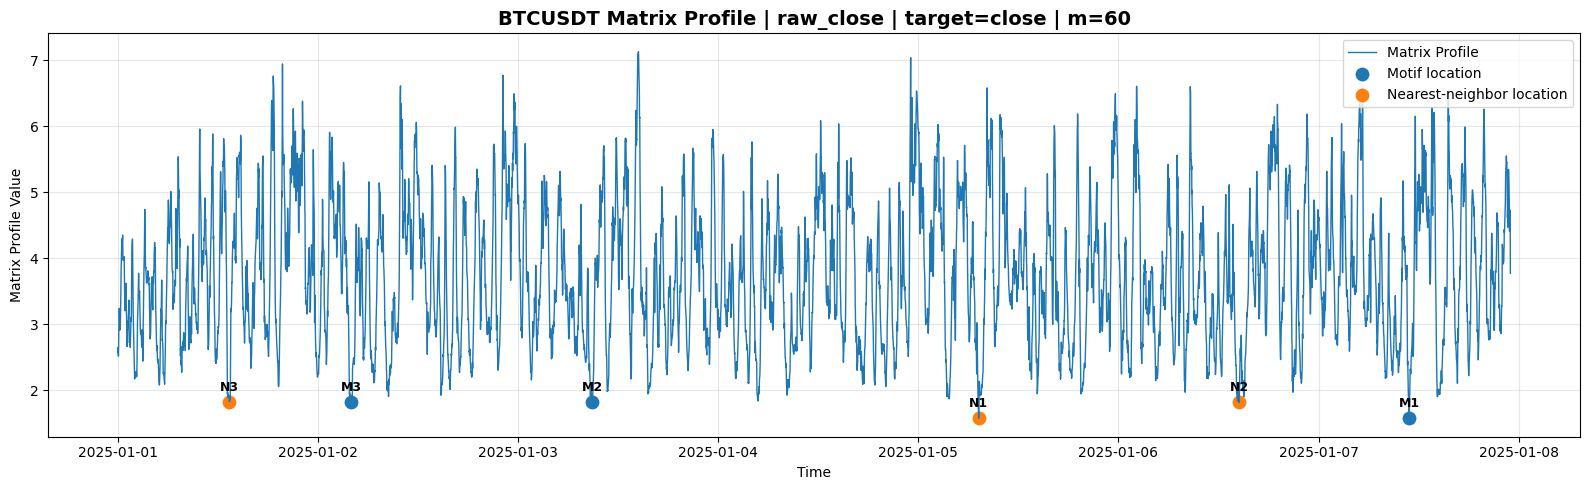

Interpretation:
- Lower Matrix Profile values indicate stronger repeated patterns.
- Marked motif points are the subsequences selected as top motifs.
- Marked nearest-neighbor points are the matched subsequences.


In [9]:
# ============================================================
# CELL 8: PLOT MATRIX PROFILE WITH MOTIF LOCATIONS
# ============================================================

mp_timestamps = timestamps.iloc[:len(mp)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))

# Matrix Profile curve
ax.plot(
    mp_timestamps,
    mp,
    linewidth=1.0,
    label="Matrix Profile"
)

# Motif indices
ax.scatter(
    motifs_df["motif_idx"].map(lambda i: mp_timestamps.iloc[i]),
    motifs_df["profile_value"],
    s=80,
    marker="o",
    label="Motif location"
)

# Neighbor indices
neighbor_values = [mp[idx] for idx in motifs_df["neighbor_idx"]]

ax.scatter(
    motifs_df["neighbor_idx"].map(lambda i: mp_timestamps.iloc[i]),
    neighbor_values,
    s=80,
    marker="o",
    label="Nearest-neighbor location"
)

# Annotate motif ranks
for _, row in motifs_df.iterrows():
    motif_x = mp_timestamps.iloc[int(row["motif_idx"])]
    motif_y = float(row["profile_value"])
    ax.annotate(
        f"M{int(row['rank'])}",
        (motif_x, motif_y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    nn_x = mp_timestamps.iloc[int(row["neighbor_idx"])]
    nn_y = float(mp[int(row["neighbor_idx"])])
    ax.annotate(
        f"N{int(row['rank'])}",
        (nn_x, nn_y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    f"{ASSET} Matrix Profile | {ANALYSIS_TYPE} | target={TARGET_COLUMN} | m={m}",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("Matrix Profile Value")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Lower Matrix Profile values indicate stronger repeated patterns.")
print("- Marked motif points are the subsequences selected as top motifs.")
print("- Marked nearest-neighbor points are the matched subsequences.")

Highlight motif windows on the full close-price chart

## Motif Windows on the Original Price Timeline

After identifying motif pairs, I project them back onto the original BTCUSDT price chart.

This is one of the most important interpretability steps.

The shaded regions show:

- where the motif window occurs
- where its nearest-neighbor match occurs

This allows me to inspect whether the detected patterns make sense in market time.

Important questions:

- Did the matched windows occur on the same day or different days?
- Did they appear before or after large price movements?
- Are they part of similar market phases?
- Do they occur near volatility changes?

This plot bridges the gap between algorithmic detection and financial interpretation.

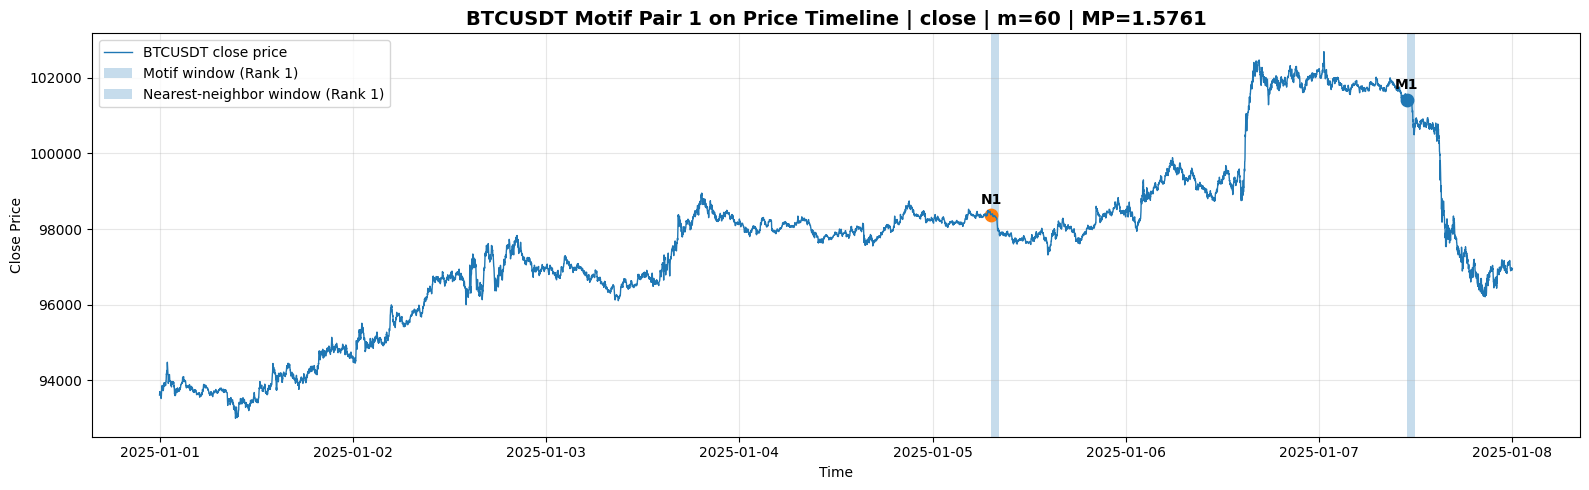

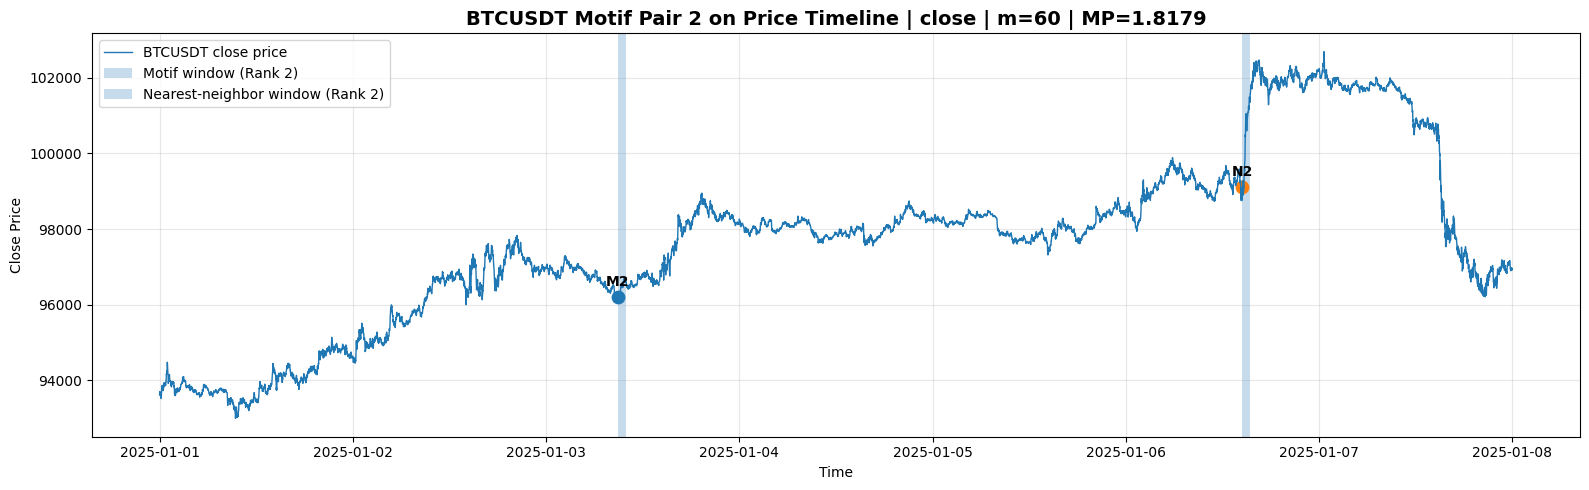

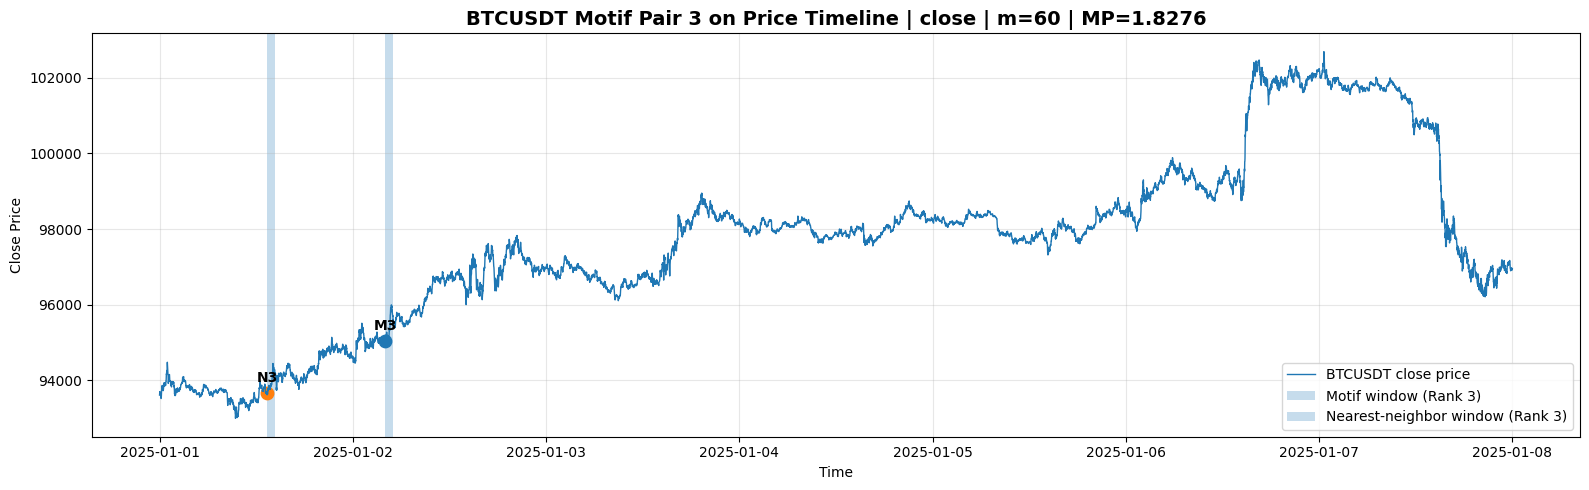

Motif timeline visualization completed.


In [10]:
# ============================================================
# CELL 9: HIGHLIGHT MOTIF WINDOWS ON THE PRICE CHART
# ============================================================

if motifs_df.empty:
    print("No motifs available to plot.")
else:
    for _, row in motifs_df.iterrows():
        fig, ax = plt.subplots(figsize=(16, 5))

        # Full close-price series
        ax.plot(
            analysis_df["timestamp"],
            analysis_df["close"],
            linewidth=1.0,
            label="BTCUSDT close price"
        )

        # Motif window shading
        ax.axvspan(
            row["motif_start"],
            row["motif_end"],
            alpha=0.25,
            label=f"Motif window (Rank {int(row['rank'])})"
        )

        # Neighbor window shading
        ax.axvspan(
            row["neighbor_start"],
            row["neighbor_end"],
            alpha=0.25,
            label=f"Nearest-neighbor window (Rank {int(row['rank'])})"
        )

        # Mark start points
        motif_price = analysis_df.iloc[int(row["motif_idx"])]["close"]
        neighbor_price = analysis_df.iloc[int(row["neighbor_idx"])]["close"]

        ax.scatter(
            row["motif_start"],
            motif_price,
            s=80,
            marker="o"
        )

        ax.scatter(
            row["neighbor_start"],
            neighbor_price,
            s=80,
            marker="o"
        )

        # Annotations
        ax.annotate(
            f"M{int(row['rank'])}",
            (row["motif_start"], motif_price),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

        ax.annotate(
            f"N{int(row['rank'])}",
            (row["neighbor_start"], neighbor_price),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

        ax.set_title(
            f"{ASSET} Motif Pair {int(row['rank'])} on Price Timeline | "
            f"{TARGET_COLUMN} | m={m} | MP={row['profile_value']:.4f}",
            fontsize=14,
            fontweight="bold"
        )
        ax.set_xlabel("Time")
        ax.set_ylabel("Close Price")
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

print("Motif timeline visualization completed.")

☝🏻Why this plot matters

This helps you answer things like:

Did the motif happen on different days?
Did similar structure appear during rising or falling markets?
Are repeated patterns clustered around specific market phases?
Later, can these windows be cross-checked with:
regime labels
major events
VIX
BTC news periods

For each motif pair:

extracts the motif subsequence
extracts its nearest-neighbor subsequence
z-normalizes both
overlays them on the same chart

This is the cleanest way to show:

“These two 60-minute windows have a very similar shape.”

## Normalized Motif Shape Comparison

Matrix Profile compares subsequences using z-normalized distance.

This means each window is standardized before comparison:

$$
z_i = \frac{x_i - \mu_x}{\sigma_x}
$$

where:

- $x_i$ is the original value at step $i$
- $\mu_x$ is the mean of the subsequence
- $\sigma_x$ is the standard deviation of the subsequence

The goal is to compare shape rather than absolute price level.

This overlay plot shows the motif window and nearest-neighbor window after z-normalization. If the two lines overlap closely, the motif match is visually convincing.

This is especially useful for raw-close motifs because BTC price may trade at different levels, but the local shape can still be similar.

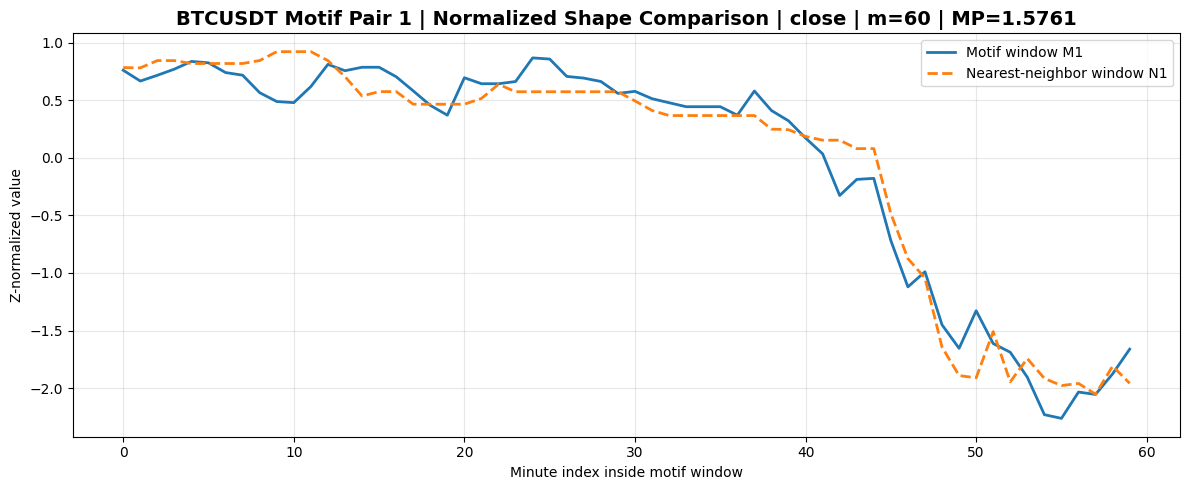

Rank 1: M1 = 2025-01-07 10:52:00+00:00 to 2025-01-07 11:51:00+00:00 | N1 = 2025-01-05 07:15:00+00:00 to 2025-01-05 08:14:00+00:00


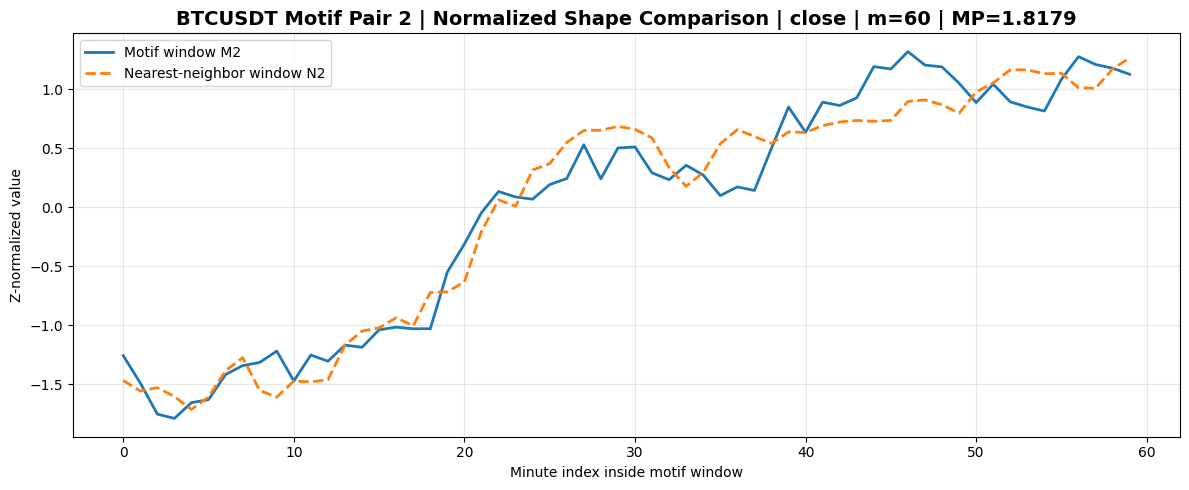

Rank 2: M2 = 2025-01-03 08:55:00+00:00 to 2025-01-03 09:54:00+00:00 | N2 = 2025-01-06 14:27:00+00:00 to 2025-01-06 15:26:00+00:00


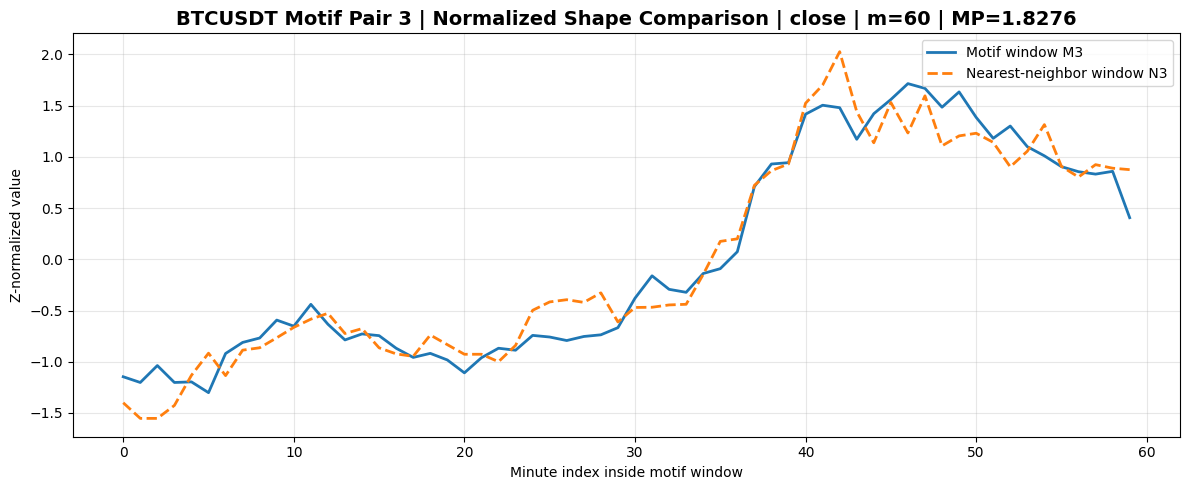

Rank 3: M3 = 2025-01-02 04:01:00+00:00 to 2025-01-02 05:00:00+00:00 | N3 = 2025-01-01 13:23:00+00:00 to 2025-01-01 14:22:00+00:00


In [11]:
# ============================================================
# CELL 10: NORMALIZED MOTIF OVERLAY
# ============================================================

def z_normalize(x):
    """
    Z-normalize a 1D array.
    """
    x = np.asarray(x, dtype=float)
    std = np.std(x)
    if std == 0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / std


if motifs_df.empty:
    print("No motifs available to overlay.")
else:
    for _, row in motifs_df.iterrows():
        motif_idx = int(row["motif_idx"])
        neighbor_idx = int(row["neighbor_idx"])

        motif_seq = series[motif_idx:motif_idx + m]
        neighbor_seq = series[neighbor_idx:neighbor_idx + m]

        motif_seq_z = z_normalize(motif_seq)
        neighbor_seq_z = z_normalize(neighbor_seq)

        x_axis = np.arange(m)

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(
            x_axis,
            motif_seq_z,
            linewidth=2,
            label=f"Motif window M{int(row['rank'])}"
        )

        ax.plot(
            x_axis,
            neighbor_seq_z,
            linewidth=2,
            linestyle="--",
            label=f"Nearest-neighbor window N{int(row['rank'])}"
        )

        ax.set_title(
            f"{ASSET} Motif Pair {int(row['rank'])} | Normalized Shape Comparison | "
            f"{TARGET_COLUMN} | m={m} | MP={row['profile_value']:.4f}",
            fontsize=14,
            fontweight="bold"
        )
        ax.set_xlabel("Minute index inside motif window")
        ax.set_ylabel("Z-normalized value")
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

        print(
            f"Rank {int(row['rank'])}: "
            f"M{int(row['rank'])} = {row['motif_start']} to {row['motif_end']} | "
            f"N{int(row['rank'])} = {row['neighbor_start']} to {row['neighbor_end']}"
        )

Why this plot matters

This plot is essential because:

raw timelines show where motifs happened
Matrix Profile plot shows how strong they are
this overlay shows what they actually looked like

So together, you now have:

data slice overview
matrix profile valleys
motif locations on timeline
normalized shape similarity

Raw motif pair comparison in original price scale

## Original-Scale Motif Comparison

The normalized overlay shows whether two windows have similar shape. However, for financial interpretation, the original price scale is also important.

This plot compares the motif and nearest-neighbor windows without normalization.

It helps answer:

- Did both windows move by a similar absolute amount?
- Did one pattern occur at a much higher price level?
- Is the similarity mostly shape-based or also magnitude-based?
- Are the two windows financially comparable?

This distinction matters because Matrix Profile can find strong shape similarity even when the actual price levels or movement magnitudes differ.

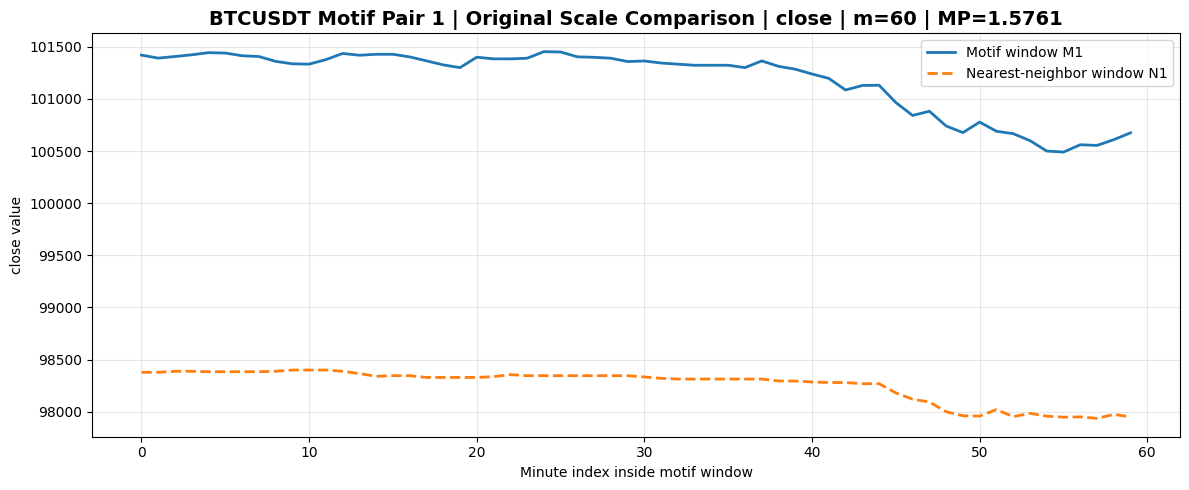

Rank 1
Motif window:   2025-01-07 10:52:00+00:00 to 2025-01-07 11:51:00+00:00
Neighbor window:2025-01-05 07:15:00+00:00 to 2025-01-05 08:14:00+00:00
Motif start/end value:    101420.0100 -> 100674.9800
Neighbor start/end value: 98378.4400 -> 97951.0100
----------------------------------------------------------------------------------------------------


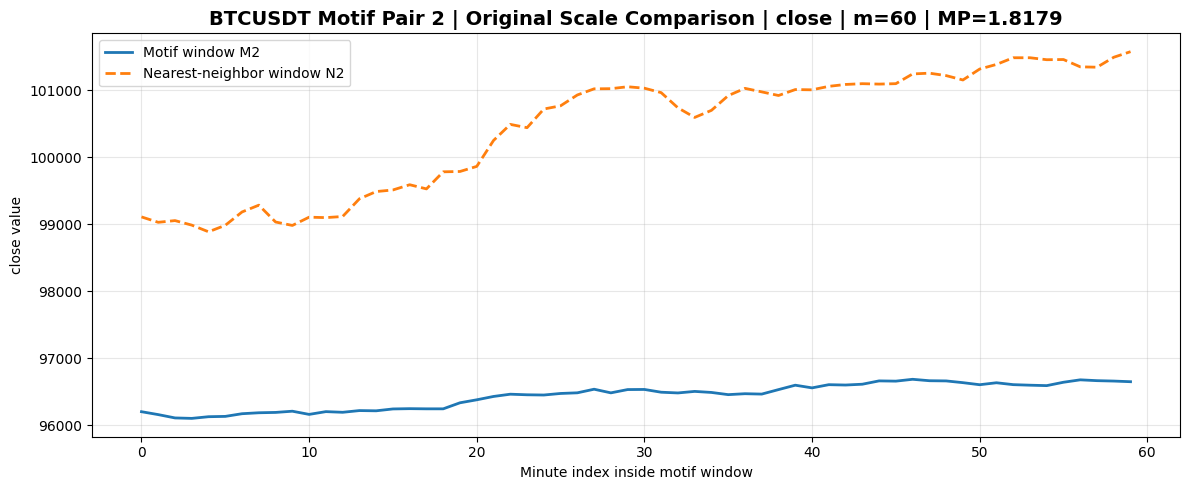

Rank 2
Motif window:   2025-01-03 08:55:00+00:00 to 2025-01-03 09:54:00+00:00
Neighbor window:2025-01-06 14:27:00+00:00 to 2025-01-06 15:26:00+00:00
Motif start/end value:    96204.6900 -> 96651.9900
Neighbor start/end value: 99110.0500 -> 101574.5300
----------------------------------------------------------------------------------------------------


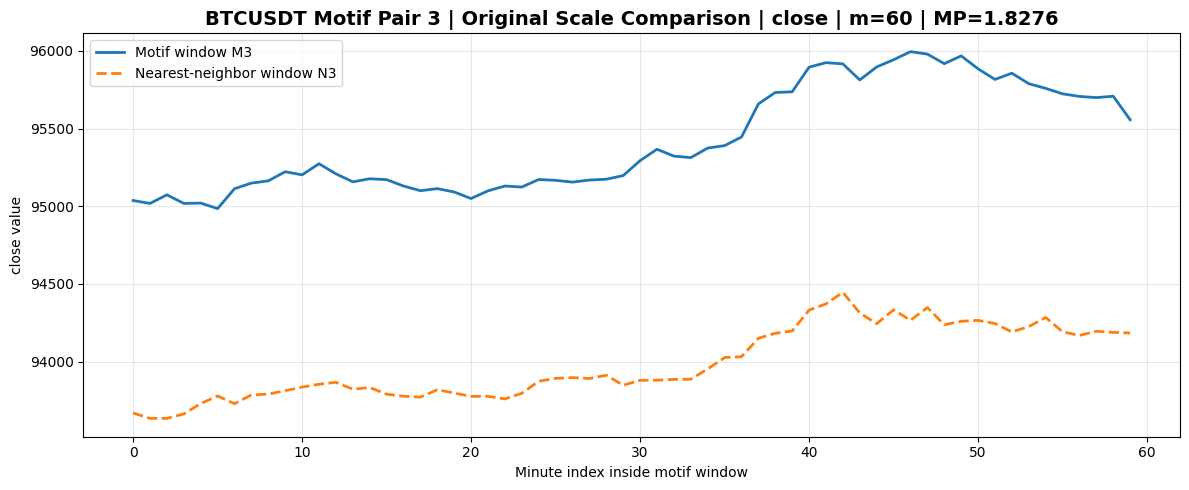

Rank 3
Motif window:   2025-01-02 04:01:00+00:00 to 2025-01-02 05:00:00+00:00
Neighbor window:2025-01-01 13:23:00+00:00 to 2025-01-01 14:22:00+00:00
Motif start/end value:    95036.8200 -> 95556.5600
Neighbor start/end value: 93669.2800 -> 94184.7900
----------------------------------------------------------------------------------------------------


In [12]:
# ============================================================
# CELL 11: RAW MOTIF PAIR COMPARISON IN ORIGINAL SCALE
# ============================================================

if motifs_df.empty:
    print("No motifs available for raw-scale comparison.")
else:
    for _, row in motifs_df.iterrows():
        motif_idx = int(row["motif_idx"])
        neighbor_idx = int(row["neighbor_idx"])

        motif_seq = series[motif_idx:motif_idx + m]
        neighbor_seq = series[neighbor_idx:neighbor_idx + m]

        x_axis = np.arange(m)

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(
            x_axis,
            motif_seq,
            linewidth=2,
            label=f"Motif window M{int(row['rank'])}"
        )

        ax.plot(
            x_axis,
            neighbor_seq,
            linewidth=2,
            linestyle="--",
            label=f"Nearest-neighbor window N{int(row['rank'])}"
        )

        ax.set_title(
            f"{ASSET} Motif Pair {int(row['rank'])} | Original Scale Comparison | "
            f"{TARGET_COLUMN} | m={m} | MP={row['profile_value']:.4f}",
            fontsize=14,
            fontweight="bold"
        )

        ax.set_xlabel("Minute index inside motif window")
        ax.set_ylabel(f"{TARGET_COLUMN} value")
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

        print(f"Rank {int(row['rank'])}")
        print(f"Motif window:   {row['motif_start']} to {row['motif_end']}")
        print(f"Neighbor window:{row['neighbor_start']} to {row['neighbor_end']}")
        print(f"Motif start/end value:    {motif_seq[0]:.4f} -> {motif_seq[-1]:.4f}")
        print(f"Neighbor start/end value: {neighbor_seq[0]:.4f} -> {neighbor_seq[-1]:.4f}")
        print("-" * 100)

Motif movement statistics

## Motif-Level Movement Statistics

Visual similarity alone is not enough for a research-grade motif study.

For each motif pair, I calculate interpretable financial statistics:

| Statistic | Purpose |
|---|---|
| Window return | Measures direction and magnitude of movement |
| Absolute change | Measures raw price movement |
| High-low range | Measures intrawindow amplitude |
| Max drawdown | Measures downside movement inside the window |
| Realized volatility | Measures local variability |
| Volume sum | Measures trading activity |
| Correlation | Measures shape similarity between motif and neighbor |

These statistics help evaluate whether the detected motifs are only visually similar or also financially similar.

This is an important step toward building a benchmark, because motif quality should not depend only on Matrix Profile distance.

In [13]:
# ============================================================
# CELL 12: MOTIF MOVEMENT STATISTICS
# ============================================================

def compute_window_stats(window_df, value_col="close"):
    """
    Compute interpretable statistics for one motif window.
    """

    values = window_df[value_col].astype(float).to_numpy()
    volume = window_df["volume"].astype(float).to_numpy() if "volume" in window_df.columns else None

    start_value = values[0]
    end_value = values[-1]

    simple_return = (end_value / start_value) - 1 if start_value != 0 else np.nan
    abs_change = end_value - start_value

    high_value = np.max(values)
    low_value = np.min(values)
    high_low_range = high_value - low_value
    high_low_range_pct = high_low_range / start_value if start_value != 0 else np.nan

    running_max = np.maximum.accumulate(values)
    drawdowns = (values / running_max) - 1
    max_drawdown = np.min(drawdowns)

    realized_vol = np.std(np.diff(np.log(values))) if np.all(values > 0) and len(values) > 1 else np.nan

    volume_sum = np.sum(volume) if volume is not None else np.nan
    volume_mean = np.mean(volume) if volume is not None else np.nan

    return {
        "start_value": start_value,
        "end_value": end_value,
        "abs_change": abs_change,
        "simple_return": simple_return,
        "high_value": high_value,
        "low_value": low_value,
        "high_low_range": high_low_range,
        "high_low_range_pct": high_low_range_pct,
        "max_drawdown": max_drawdown,
        "realized_vol": realized_vol,
        "volume_sum": volume_sum,
        "volume_mean": volume_mean,
    }


def safe_corr(a, b):
    """
    Correlation between two same-length arrays.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if len(a) != len(b):
        return np.nan

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


motif_stats_records = []

for _, row in motifs_df.iterrows():
    motif_idx = int(row["motif_idx"])
    neighbor_idx = int(row["neighbor_idx"])

    motif_window_df = analysis_df.iloc[motif_idx:motif_idx + m].copy()
    neighbor_window_df = analysis_df.iloc[neighbor_idx:neighbor_idx + m].copy()

    motif_stats = compute_window_stats(motif_window_df, value_col=TARGET_COLUMN)
    neighbor_stats = compute_window_stats(neighbor_window_df, value_col=TARGET_COLUMN)

    motif_seq = motif_window_df[TARGET_COLUMN].astype(float).to_numpy()
    neighbor_seq = neighbor_window_df[TARGET_COLUMN].astype(float).to_numpy()

    motif_seq_z = z_normalize(motif_seq)
    neighbor_seq_z = z_normalize(neighbor_seq)

    raw_corr = safe_corr(motif_seq, neighbor_seq)
    z_corr = safe_corr(motif_seq_z, neighbor_seq_z)

    motif_stats_records.append({
        "rank": int(row["rank"]),
        "profile_value": float(row["profile_value"]),
        "motif_start": row["motif_start"],
        "motif_end": row["motif_end"],
        "neighbor_start": row["neighbor_start"],
        "neighbor_end": row["neighbor_end"],

        "motif_return_pct": motif_stats["simple_return"] * 100,
        "neighbor_return_pct": neighbor_stats["simple_return"] * 100,

        "motif_abs_change": motif_stats["abs_change"],
        "neighbor_abs_change": neighbor_stats["abs_change"],

        "motif_range_pct": motif_stats["high_low_range_pct"] * 100,
        "neighbor_range_pct": neighbor_stats["high_low_range_pct"] * 100,

        "motif_max_drawdown_pct": motif_stats["max_drawdown"] * 100,
        "neighbor_max_drawdown_pct": neighbor_stats["max_drawdown"] * 100,

        "motif_realized_vol": motif_stats["realized_vol"],
        "neighbor_realized_vol": neighbor_stats["realized_vol"],

        "motif_volume_sum": motif_stats["volume_sum"],
        "neighbor_volume_sum": neighbor_stats["volume_sum"],

        "raw_price_corr": raw_corr,
        "z_normalized_corr": z_corr,
    })

motif_stats_df = pd.DataFrame(motif_stats_records)

print("Motif movement statistics created.")
display(motif_stats_df)

Motif movement statistics created.


,rank,profile_value,motif_start,motif_end,neighbor_start,neighbor_end,motif_return_pct,neighbor_return_pct,motif_abs_change,neighbor_abs_change,motif_range_pct,neighbor_range_pct,motif_max_drawdown_pct,neighbor_max_drawdown_pct,motif_realized_vol,neighbor_realized_vol,motif_volume_sum,neighbor_volume_sum,raw_price_corr,z_normalized_corr
0,1,1.576078,2025-01-07 10:52:00+00:00,2025-01-07 11:51:00+00:00,2025-01-05 07:15:00+00:00,2025-01-05 08:14:00+00:00,-0.734599,-0.434475,-745.03,-427.43,0.949467,0.471323,-0.949159,-0.471220,0.000522,0.000249,1341.43193,286.2620,0.979300,0.979300
1,2,1.817904,2025-01-03 08:55:00+00:00,2025-01-03 09:54:00+00:00,2025-01-06 14:27:00+00:00,2025-01-06 15:26:00+00:00,0.464946,2.486610,447.30,2464.48,0.606031,2.710643,-0.103664,-0.452760,0.000330,0.001178,540.26082,4782.4928,0.972460,0.972460
2,3,1.827565,2025-01-02 04:01:00+00:00,2025-01-02 05:00:00+00:00,2025-01-01 13:23:00+00:00,2025-01-01 14:22:00+00:00,0.546883,0.550351,519.74,515.51,1.062599,0.865844,-0.456431,-0.293555,0.000642,0.000544,916.77700,542.4033,0.972167,0.972167


Motif statistics visual summary

## Visual Summary of Motif Statistics

The bar charts summarize motif behavior across several dimensions.

These plots make it easier to compare motif and nearest-neighbor windows side by side.

The most important checks are:

1. **Return similarity**  
   Do the motif and neighbor move in the same direction?

2. **Range similarity**  
   Do they have similar amplitude?

3. **Drawdown similarity**  
   Do they show similar downside risk?

4. **Volume similarity**  
   Do similar price patterns happen under similar trading activity?

5. **Correlation similarity**  
   Does the shape match remain strong after normalization?

This helps move the analysis from “the algorithm found something” to “the detected pattern can be interpreted and evaluated.”

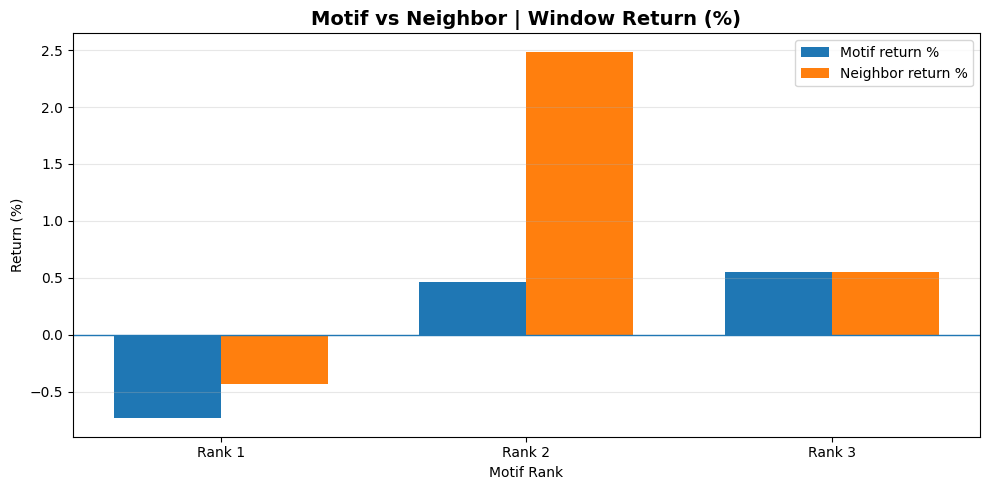

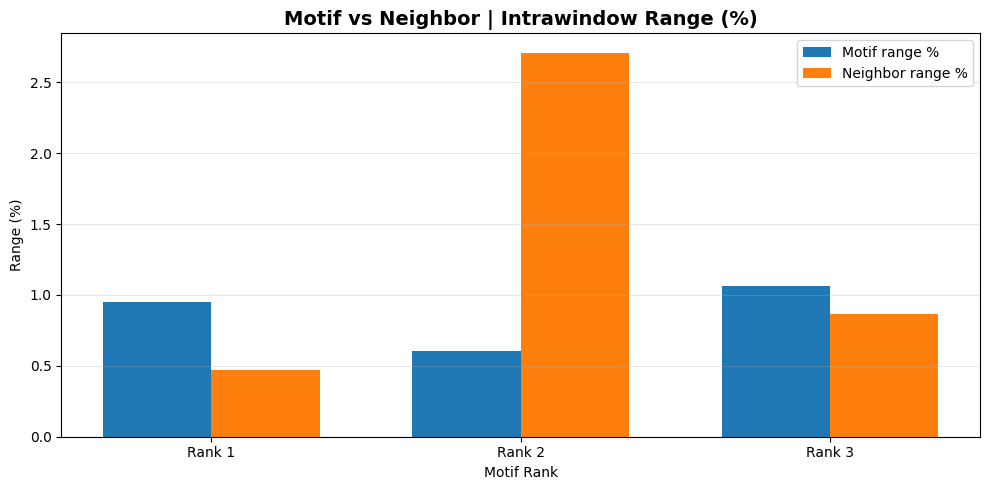

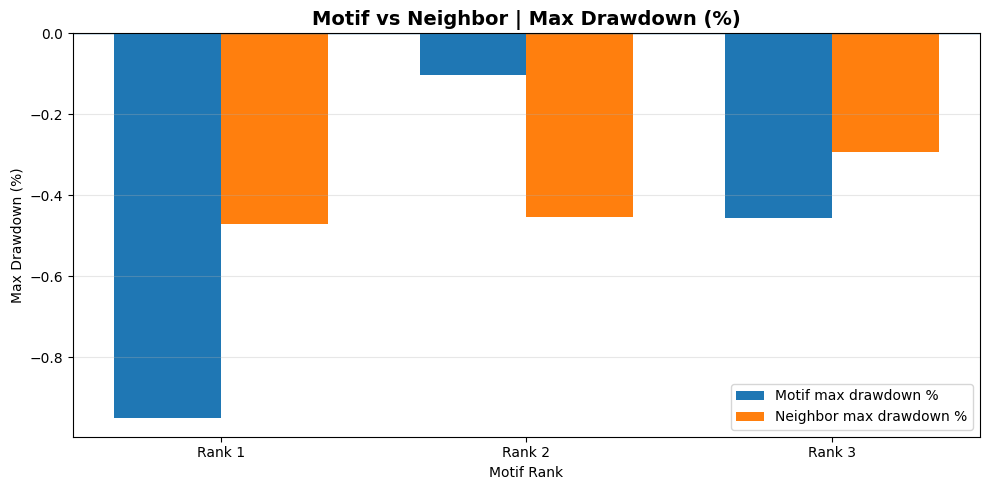

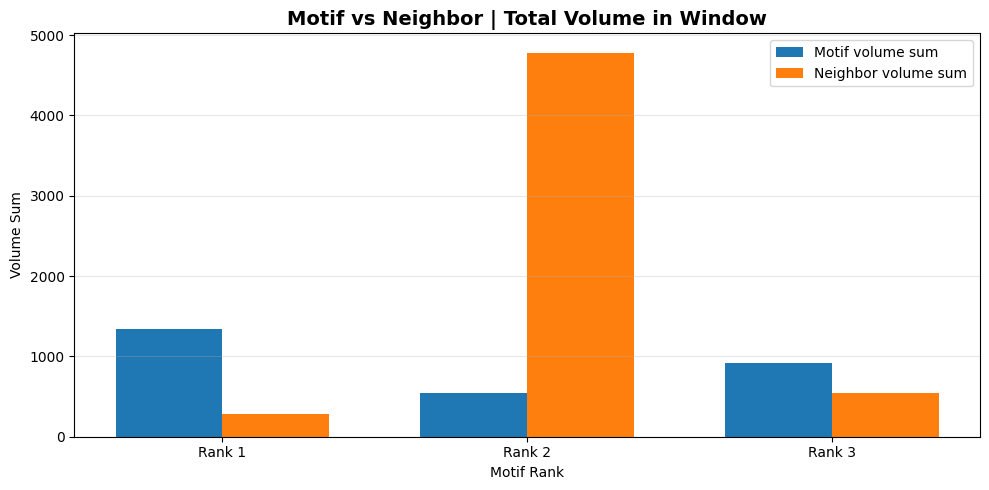

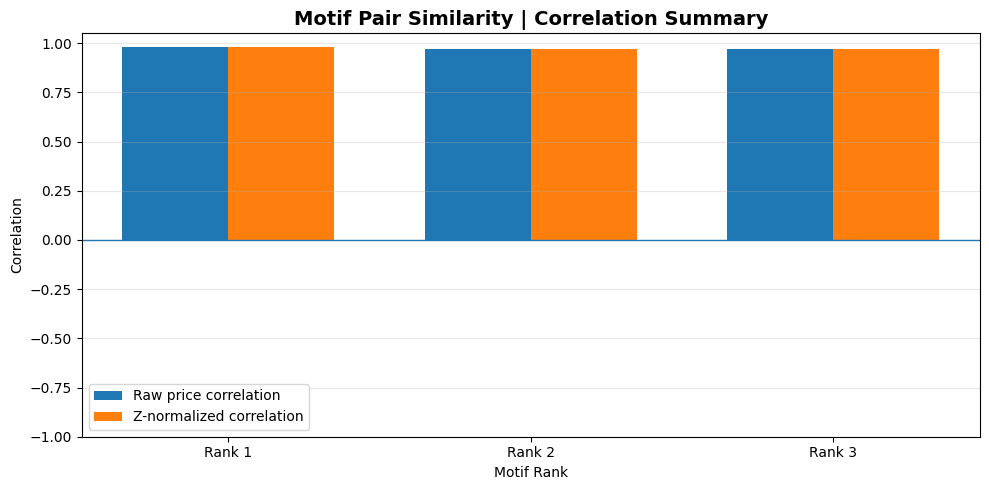

Interpretation guide:
- Return plot: tells whether matched windows moved in the same direction and with similar magnitude.
- Range plot: shows whether the windows had similar internal amplitude / movement span.
- Max drawdown plot: shows downside risk similarity inside the motif windows.
- Volume plot: useful for checking whether pattern similarity also coincides with similar trading activity.
- Correlation plot: summarizes raw and normalized shape similarity.


In [14]:
# ============================================================
# CELL 13: MOTIF STATISTICS VISUAL SUMMARY
# ============================================================

if motif_stats_df.empty:
    print("No motif statistics available to plot.")
else:
    plot_df = motif_stats_df.copy()
    plot_df["rank_label"] = plot_df["rank"].apply(lambda x: f"Rank {x}")

    x = np.arange(len(plot_df))
    width = 0.35

    # --------------------------------------------------------
    # 1. Return comparison
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, plot_df["motif_return_pct"], width, label="Motif return %")
    ax.bar(x + width/2, plot_df["neighbor_return_pct"], width, label="Neighbor return %")
    ax.set_title("Motif vs Neighbor | Window Return (%)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Motif Rank")
    ax.set_ylabel("Return (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["rank_label"])
    ax.axhline(0, linewidth=1)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 2. High-low range comparison
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, plot_df["motif_range_pct"], width, label="Motif range %")
    ax.bar(x + width/2, plot_df["neighbor_range_pct"], width, label="Neighbor range %")
    ax.set_title("Motif vs Neighbor | Intrawindow Range (%)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Motif Rank")
    ax.set_ylabel("Range (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["rank_label"])
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 3. Max drawdown comparison
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, plot_df["motif_max_drawdown_pct"], width, label="Motif max drawdown %")
    ax.bar(x + width/2, plot_df["neighbor_max_drawdown_pct"], width, label="Neighbor max drawdown %")
    ax.set_title("Motif vs Neighbor | Max Drawdown (%)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Motif Rank")
    ax.set_ylabel("Max Drawdown (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["rank_label"])
    ax.axhline(0, linewidth=1)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 4. Volume comparison
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, plot_df["motif_volume_sum"], width, label="Motif volume sum")
    ax.bar(x + width/2, plot_df["neighbor_volume_sum"], width, label="Neighbor volume sum")
    ax.set_title("Motif vs Neighbor | Total Volume in Window", fontsize=14, fontweight="bold")
    ax.set_xlabel("Motif Rank")
    ax.set_ylabel("Volume Sum")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["rank_label"])
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 5. Similarity / correlation summary
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, plot_df["raw_price_corr"], width, label="Raw price correlation")
    ax.bar(x + width/2, plot_df["z_normalized_corr"], width, label="Z-normalized correlation")
    ax.set_title("Motif Pair Similarity | Correlation Summary", fontsize=14, fontweight="bold")
    ax.set_xlabel("Motif Rank")
    ax.set_ylabel("Correlation")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["rank_label"])
    ax.set_ylim(-1.0, 1.05)
    ax.axhline(0, linewidth=1)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Interpretation guide:")
    print("- Return plot: tells whether matched windows moved in the same direction and with similar magnitude.")
    print("- Range plot: shows whether the windows had similar internal amplitude / movement span.")
    print("- Max drawdown plot: shows downside risk similarity inside the motif windows.")
    print("- Volume plot: useful for checking whether pattern similarity also coincides with similar trading activity.")
    print("- Correlation plot: summarizes raw and normalized shape similarity.")

Clear zoomed motif-pair dashboard

## Clear Side-by-Side Motif Dashboard

This dashboard compares each motif pair in a more human-readable way.

For every motif rank, I show:

- the motif window on the left
- the nearest-neighbor window on the right
- the same y-axis scale for fair comparison
- a compact statistics box below the plot

This is useful because a motif should be interpretable, not only mathematically close.

The dashboard helps identify cases where:

- the shape is very similar
- the price level is different
- the movement magnitude is different
- the correlation is high but the financial behavior differs

This is directly relevant for financial motif discovery, where repeated shapes may or may not represent repeated market behavior.

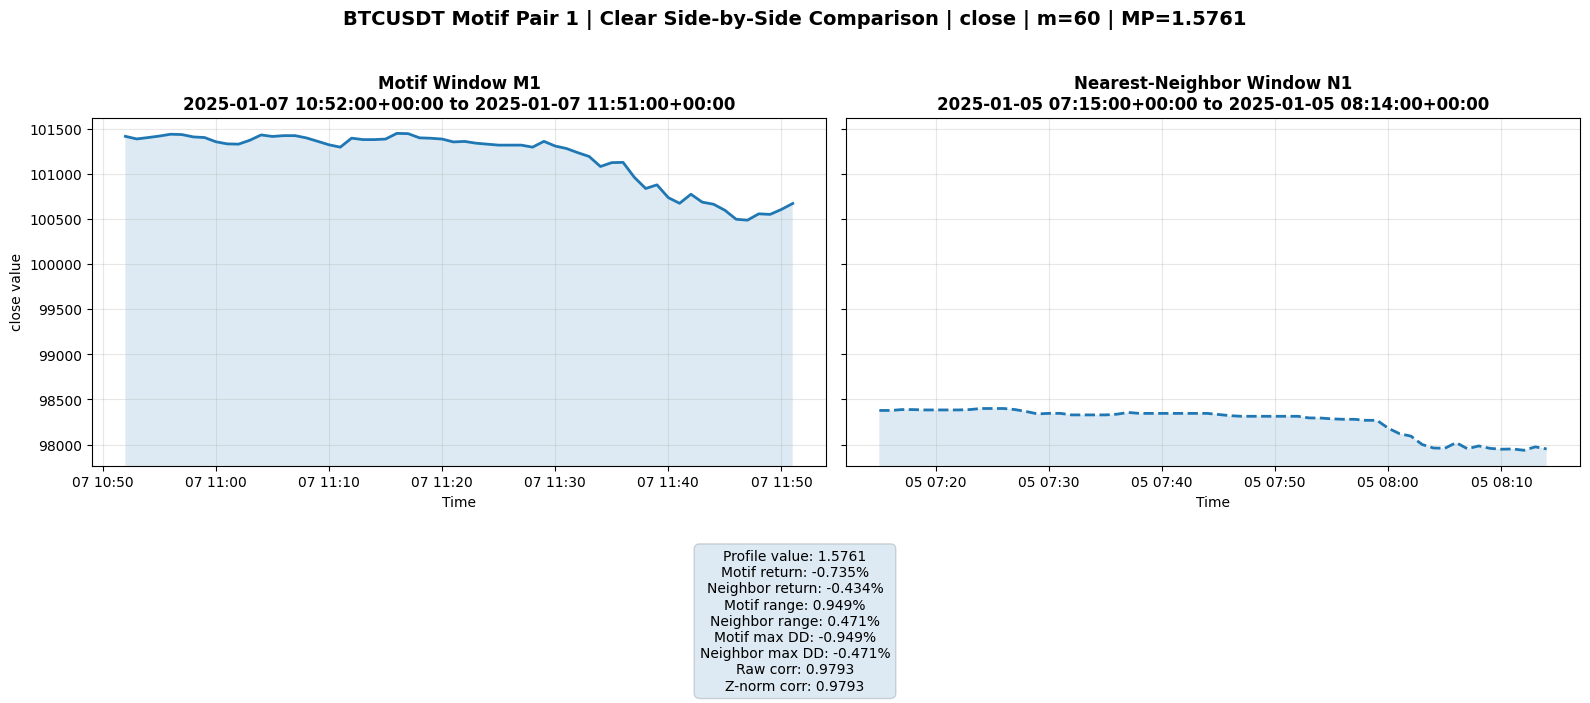

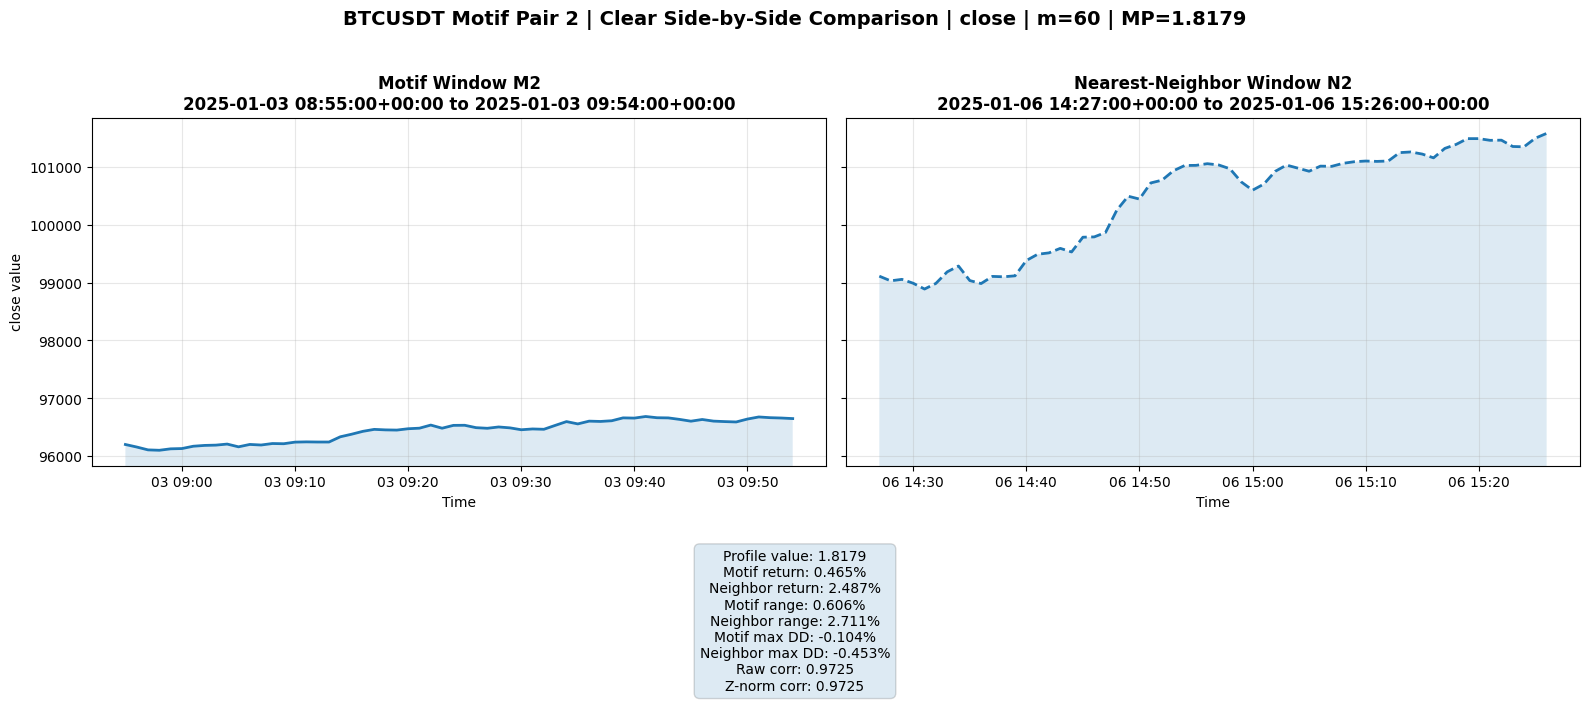

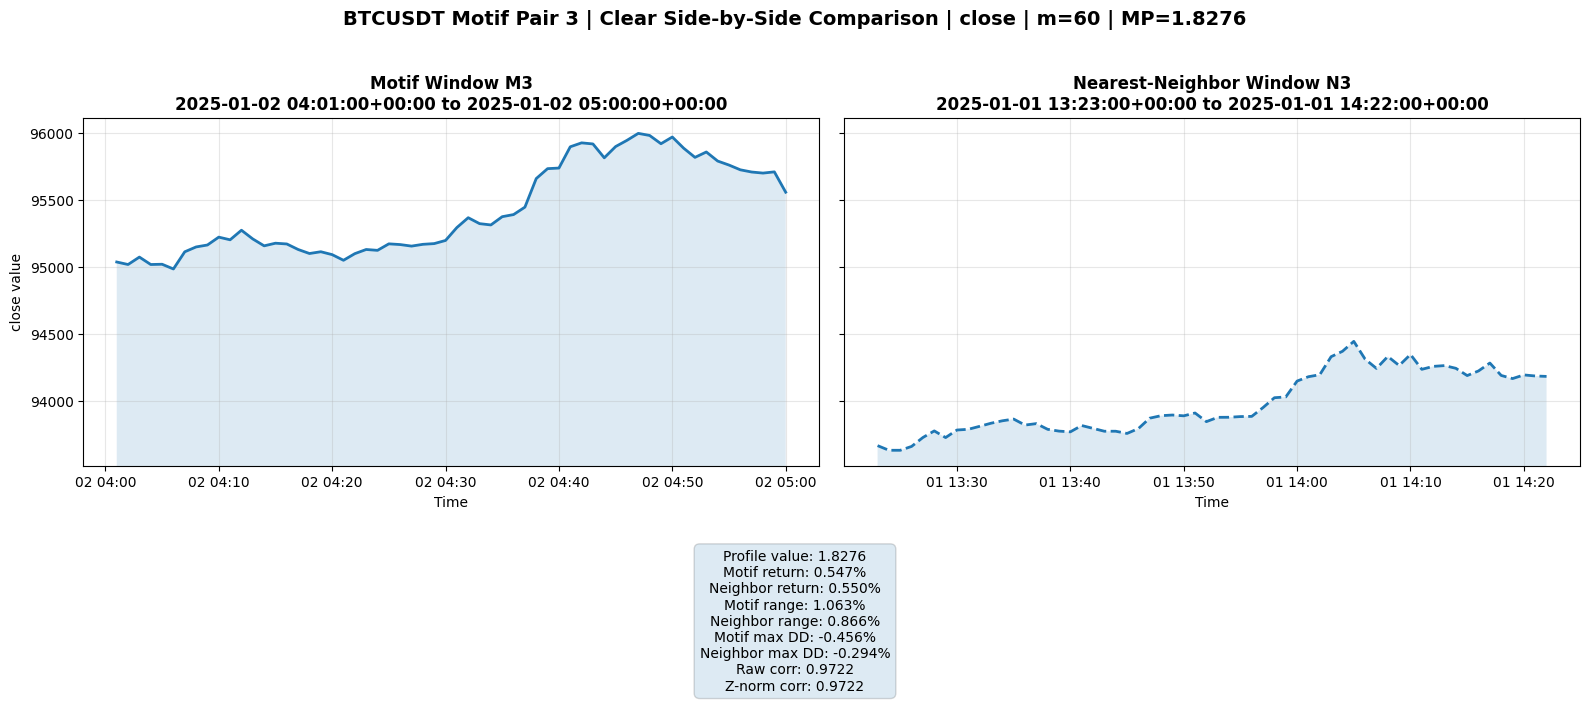

Clear motif-pair dashboard visualization completed.


In [15]:
# ============================================================
# CELL 14: CLEAR ZOOMED MOTIF-PAIR DASHBOARD
# ============================================================

if motifs_df.empty:
    print("No motifs available for dashboard visualization.")
else:
    for _, row in motifs_df.iterrows():
        rank = int(row["rank"])
        motif_idx = int(row["motif_idx"])
        neighbor_idx = int(row["neighbor_idx"])

        motif_window_df = analysis_df.iloc[motif_idx:motif_idx + m].copy()
        neighbor_window_df = analysis_df.iloc[neighbor_idx:neighbor_idx + m].copy()

        motif_values = motif_window_df[TARGET_COLUMN].astype(float).to_numpy()
        neighbor_values = neighbor_window_df[TARGET_COLUMN].astype(float).to_numpy()

        # Shared y-axis limits for fair visual comparison
        y_min = min(motif_values.min(), neighbor_values.min())
        y_max = max(motif_values.max(), neighbor_values.max())
        y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
        y_min -= y_pad
        y_max += y_pad

        # Pull stats for the current rank
        stats_row = motif_stats_df[motif_stats_df["rank"] == rank].iloc[0]

        fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

        # ----------------------------------------------------
        # Left panel: Motif window
        # ----------------------------------------------------
        axes[0].plot(
            motif_window_df["timestamp"],
            motif_values,
            linewidth=2
        )
        axes[0].fill_between(
            motif_window_df["timestamp"],
            motif_values,
            alpha=0.15
        )
        axes[0].set_title(
            f"Motif Window M{rank}\n{row['motif_start']} to {row['motif_end']}",
            fontsize=12,
            fontweight="bold"
        )
        axes[0].set_xlabel("Time")
        axes[0].set_ylabel(f"{TARGET_COLUMN} value")
        axes[0].set_ylim(y_min, y_max)
        axes[0].grid(True, alpha=0.3)

        # ----------------------------------------------------
        # Right panel: Neighbor window
        # ----------------------------------------------------
        axes[1].plot(
            neighbor_window_df["timestamp"],
            neighbor_values,
            linewidth=2,
            linestyle="--"
        )
        axes[1].fill_between(
            neighbor_window_df["timestamp"],
            neighbor_values,
            alpha=0.15
        )
        axes[1].set_title(
            f"Nearest-Neighbor Window N{rank}\n{row['neighbor_start']} to {row['neighbor_end']}",
            fontsize=12,
            fontweight="bold"
        )
        axes[1].set_xlabel("Time")
        axes[1].set_ylim(y_min, y_max)
        axes[1].grid(True, alpha=0.3)

        # ----------------------------------------------------
        # Main title
        # ----------------------------------------------------
        fig.suptitle(
            f"{ASSET} Motif Pair {rank} | Clear Side-by-Side Comparison | "
            f"{TARGET_COLUMN} | m={m} | MP={row['profile_value']:.4f}",
            fontsize=14,
            fontweight="bold",
            y=1.03
        )

        # ----------------------------------------------------
        # Stats text box
        # ----------------------------------------------------
        stats_text = (
            f"Profile value: {stats_row['profile_value']:.4f}\n"
            f"Motif return: {stats_row['motif_return_pct']:.3f}%\n"
            f"Neighbor return: {stats_row['neighbor_return_pct']:.3f}%\n"
            f"Motif range: {stats_row['motif_range_pct']:.3f}%\n"
            f"Neighbor range: {stats_row['neighbor_range_pct']:.3f}%\n"
            f"Motif max DD: {stats_row['motif_max_drawdown_pct']:.3f}%\n"
            f"Neighbor max DD: {stats_row['neighbor_max_drawdown_pct']:.3f}%\n"
            f"Raw corr: {stats_row['raw_price_corr']:.4f}\n"
            f"Z-norm corr: {stats_row['z_normalized_corr']:.4f}"
        )

        fig.text(
            0.5, -0.05, stats_text,
            ha="center", va="top",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", alpha=0.15)
        )

        plt.tight_layout()
        plt.show()

print("Clear motif-pair dashboard visualization completed.")

Motif Atlas Heatmap

It stacks all motif windows and neighbor windows together as rows:

M1, N1, M2, N2, M3, N3
each row is z-normalized
x-axis = minute index inside the 60-minute window
color = relative movement shape

This is very good because it lets you see:

whether motif families look similar
whether different motif pairs share common structure
whether there are “shape clusters”

## Motif Atlas Heatmap

The motif atlas gives a compact overview of all selected motif and nearest-neighbor windows.

Each row represents one window:

- `M1` means motif window for rank 1
- `N1` means nearest-neighbor window for rank 1
- and so on

Each row is z-normalized so that the heatmap compares internal shape rather than price level.

The x-axis represents the minute index inside the motif window.

This visualization helps detect whether:

- motif-neighbor pairs have similar shape
- different motif pairs share common structure
- some motifs belong to the same pattern family
- some motif pairs are visually distinct from others

This is useful for moving from individual motif inspection toward motif family analysis.

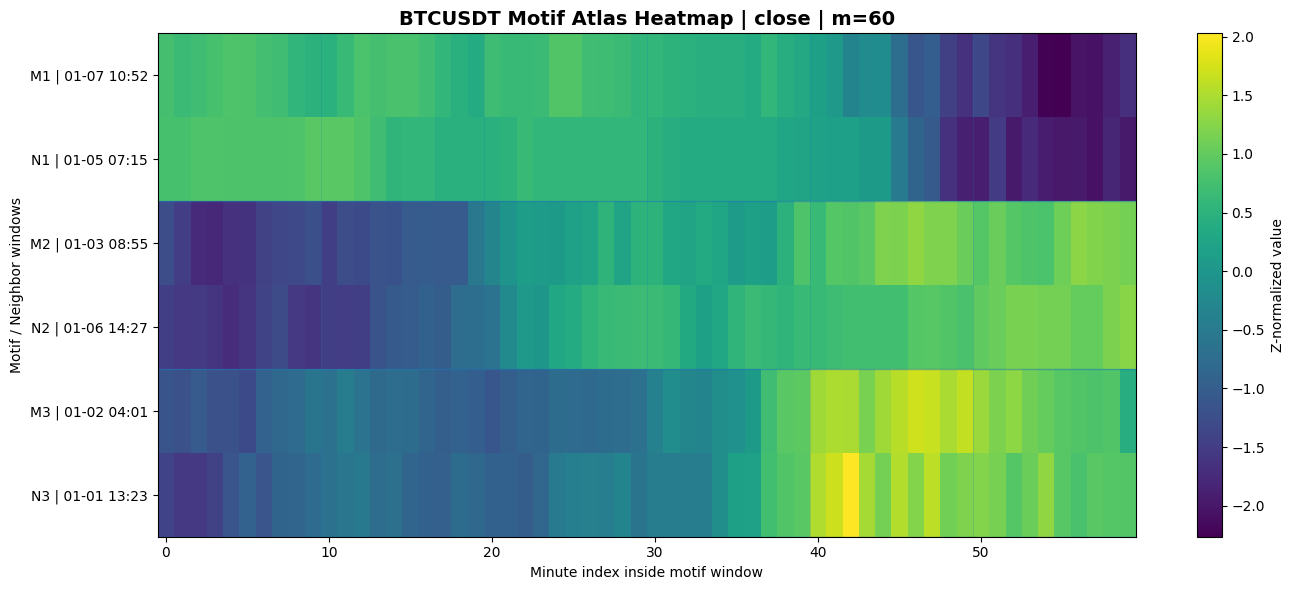

Interpretation:
- Each row is one motif window or its nearest-neighbor window.
- Similar color patterns across rows indicate similar internal shape evolution.
- M1 vs N1, M2 vs N2, etc. should visually resemble each other if the motif match is strong.


In [16]:
# ============================================================
# CELL 15: MOTIF ATLAS HEATMAP
# ============================================================

if motifs_df.empty:
    print("No motifs available for heatmap visualization.")
else:
    heatmap_rows = []
    row_labels = []

    for _, row in motifs_df.iterrows():
        rank = int(row["rank"])
        motif_idx = int(row["motif_idx"])
        neighbor_idx = int(row["neighbor_idx"])

        motif_seq = series[motif_idx:motif_idx + m]
        neighbor_seq = series[neighbor_idx:neighbor_idx + m]

        motif_seq_z = z_normalize(motif_seq)
        neighbor_seq_z = z_normalize(neighbor_seq)

        heatmap_rows.append(motif_seq_z)
        row_labels.append(f"M{rank} | {pd.Timestamp(row['motif_start']).strftime('%m-%d %H:%M')}")

        heatmap_rows.append(neighbor_seq_z)
        row_labels.append(f"N{rank} | {pd.Timestamp(row['neighbor_start']).strftime('%m-%d %H:%M')}")

    heatmap_data = np.vstack(heatmap_rows)

    fig, ax = plt.subplots(figsize=(14, 6))

    im = ax.imshow(
        heatmap_data,
        aspect="auto",
        interpolation="nearest"
    )

    ax.set_title(
        f"{ASSET} Motif Atlas Heatmap | {TARGET_COLUMN} | m={m}",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Minute index inside motif window")
    ax.set_ylabel("Motif / Neighbor windows")

    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)

    # Vertical guide lines every 10 minutes
    for x in range(0, m, 10):
        ax.axvline(x - 0.5, linewidth=0.5, alpha=0.3)

    # Horizontal separators between motif pairs
    for y in range(1, len(row_labels), 2):
        ax.axhline(y + 0.5, linewidth=1.0, alpha=0.5)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Z-normalized value")

    plt.tight_layout()
    plt.show()

    print("Interpretation:")
    print("- Each row is one motif window or its nearest-neighbor window.")
    print("- Similar color patterns across rows indicate similar internal shape evolution.")
    print("- M1 vs N1, M2 vs N2, etc. should visually resemble each other if the motif match is strong.")

## Motif Consistency Score: Moving Beyond Matrix Profile Distance

At this stage, I have already extracted motif pairs using the Matrix Profile. However, the raw Matrix Profile distance alone is not enough to judge whether a detected motif is financially meaningful.

A low Matrix Profile value tells me that two windows have similar shape under the distance function, but it does not automatically mean that both windows behave similarly in terms of return, range, drawdown, or trading activity.

For this reason, I define a simple motif consistency score from 0 to 10.

The score combines:

| Component | Interpretation |
|---|---|
| Matrix Profile quality | Lower distance is better |
| Shape similarity | Higher z-normalized correlation is better |
| Return similarity | Similar window returns are better |
| Range similarity | Similar movement amplitude is better |
| Drawdown similarity | Similar downside behavior is better |
| Volume similarity | Similar trading activity is better |

The purpose is not to claim that this is a final universal score. Instead, it is a practical prototype metric that helps separate visually similar motifs from financially consistent motifs.

This is important because in financial data, two windows can look similar after normalization but still have very different economic behavior.

In [17]:
# ============================================================
# CELL 16: MOTIF CONSISTENCY SCORE 0 TO 10
# ============================================================

def minmax_score_lower_is_better(values):
    """
    Convert values to 0-1 score where lower original values are better.
    """
    values = np.asarray(values, dtype=float)

    if np.allclose(values.max(), values.min()):
        return np.ones_like(values)

    return 1 - ((values - values.min()) / (values.max() - values.min()))


def similarity_from_absolute_difference(diff_values):
    """
    Convert absolute differences into 0-1 similarity score.
    Smaller difference = higher similarity.
    """
    diff_values = np.asarray(diff_values, dtype=float)

    if np.allclose(diff_values.max(), diff_values.min()):
        return np.ones_like(diff_values)

    return 1 - ((diff_values - diff_values.min()) / (diff_values.max() - diff_values.min()))


if motif_stats_df.empty:
    print("No motif statistics available for consistency scoring.")
else:
    consistency_df = motif_stats_df.copy()

    # --------------------------------------------------------
    # Difference-based features
    # --------------------------------------------------------

    consistency_df["return_abs_diff"] = (
        consistency_df["motif_return_pct"] - consistency_df["neighbor_return_pct"]
    ).abs()

    consistency_df["range_abs_diff"] = (
        consistency_df["motif_range_pct"] - consistency_df["neighbor_range_pct"]
    ).abs()

    consistency_df["drawdown_abs_diff"] = (
        consistency_df["motif_max_drawdown_pct"] - consistency_df["neighbor_max_drawdown_pct"]
    ).abs()

    consistency_df["volume_abs_diff_pct"] = (
        (
            consistency_df["motif_volume_sum"] - consistency_df["neighbor_volume_sum"]
        ).abs()
        / consistency_df[["motif_volume_sum", "neighbor_volume_sum"]].mean(axis=1)
    ) * 100

    # --------------------------------------------------------
    # Convert raw metrics to 0-1 quality components
    # --------------------------------------------------------

    consistency_df["mp_quality"] = minmax_score_lower_is_better(
        consistency_df["profile_value"]
    )

    consistency_df["shape_quality"] = consistency_df["z_normalized_corr"].clip(-1, 1)
    consistency_df["shape_quality"] = (consistency_df["shape_quality"] + 1) / 2

    consistency_df["return_quality"] = similarity_from_absolute_difference(
        consistency_df["return_abs_diff"]
    )

    consistency_df["range_quality"] = similarity_from_absolute_difference(
        consistency_df["range_abs_diff"]
    )

    consistency_df["drawdown_quality"] = similarity_from_absolute_difference(
        consistency_df["drawdown_abs_diff"]
    )

    consistency_df["volume_quality"] = similarity_from_absolute_difference(
        consistency_df["volume_abs_diff_pct"]
    )

    # --------------------------------------------------------
    # Weighted consistency score
    # --------------------------------------------------------
    # Reasoning:
    # - Shape and MP distance should matter most.
    # - Return/range/drawdown provide financial interpretation.
    # - Volume is useful but secondary.

    WEIGHTS = {
        "mp_quality": 0.25,
        "shape_quality": 0.30,
        "return_quality": 0.15,
        "range_quality": 0.15,
        "drawdown_quality": 0.10,
        "volume_quality": 0.05,
    }

    consistency_df["consistency_score_0_10"] = 10 * (
        WEIGHTS["mp_quality"] * consistency_df["mp_quality"]
        + WEIGHTS["shape_quality"] * consistency_df["shape_quality"]
        + WEIGHTS["return_quality"] * consistency_df["return_quality"]
        + WEIGHTS["range_quality"] * consistency_df["range_quality"]
        + WEIGHTS["drawdown_quality"] * consistency_df["drawdown_quality"]
        + WEIGHTS["volume_quality"] * consistency_df["volume_quality"]
    )

    consistency_df["consistency_score_0_10"] = consistency_df[
        "consistency_score_0_10"
    ].round(3)

    # --------------------------------------------------------
    # Human-readable label
    # --------------------------------------------------------

    def label_consistency(score):
        if score >= 8:
            return "Very strong"
        elif score >= 6:
            return "Strong"
        elif score >= 4:
            return "Moderate"
        else:
            return "Weak"

    consistency_df["consistency_label"] = consistency_df[
        "consistency_score_0_10"
    ].apply(label_consistency)

    # --------------------------------------------------------
    # Display final ranking table
    # --------------------------------------------------------

    display_cols = [
        "rank",
        "profile_value",
        "z_normalized_corr",
        "return_abs_diff",
        "range_abs_diff",
        "drawdown_abs_diff",
        "volume_abs_diff_pct",
        "consistency_score_0_10",
        "consistency_label",
        "motif_start",
        "neighbor_start",
    ]

    consistency_df = consistency_df.sort_values(
        "consistency_score_0_10", ascending=False
    ).reset_index(drop=True)

    print("Motif consistency score created.")
    display(consistency_df[display_cols])

Motif consistency score created.


,rank,profile_value,z_normalized_corr,return_abs_diff,range_abs_diff,drawdown_abs_diff,volume_abs_diff_pct,consistency_score_0_10,consistency_label,motif_start,neighbor_start
0,1,1.576078,0.979300,0.300123,0.478145,0.477939,129.652131,8.165,Very strong,2025-01-07 10:52:00+00:00,2025-01-05 07:15:00+00:00
1,3,1.827565,0.972167,0.003468,0.196755,0.162877,51.312878,7.458,Strong,2025-01-02 04:01:00+00:00,2025-01-01 13:23:00+00:00
2,2,1.817904,0.972460,2.021663,2.104613,0.349096,159.399900,3.464,Weak,2025-01-03 08:55:00+00:00,2025-01-06 14:27:00+00:00


## Consistency Score Findings

The consistency scoring produced three different motif-quality outcomes.

| Rank | Score | Label | Interpretation |
|---|---:|---|---|
| Rank 1 | 8.165 | Very strong | Strong Matrix Profile match and strong shape similarity |
| Rank 3 | 7.458 | Strong | Slightly weaker Matrix Profile distance but better financial-behavior similarity |
| Rank 2 | 3.464 | Weak | High shape correlation but weak financial consistency |

The most important finding is that **high shape similarity alone is not enough**.

Rank 2 has a high z-normalized correlation, but its return, range, and volume behavior differ strongly between the motif and its nearest neighbor. This suggests that Matrix Profile can find mathematically similar shapes that may not always represent similar financial behavior.

This supports the need for additional evaluation metrics beyond motif distance.

## Visualizing the Consistency Score

The next step is to visualize the consistency score and its internal components.

The bar chart shows the final 0 to 10 score for each motif pair.

The heatmap breaks the score into its components:

- Matrix Profile quality
- Shape quality
- Return quality
- Range quality
- Drawdown quality
- Volume quality

This component-level view is useful because it explains *why* a motif receives a strong or weak score.

For example, a motif may have excellent shape quality but poor return or volume similarity. In that case, it may be visually similar but financially less reliable.

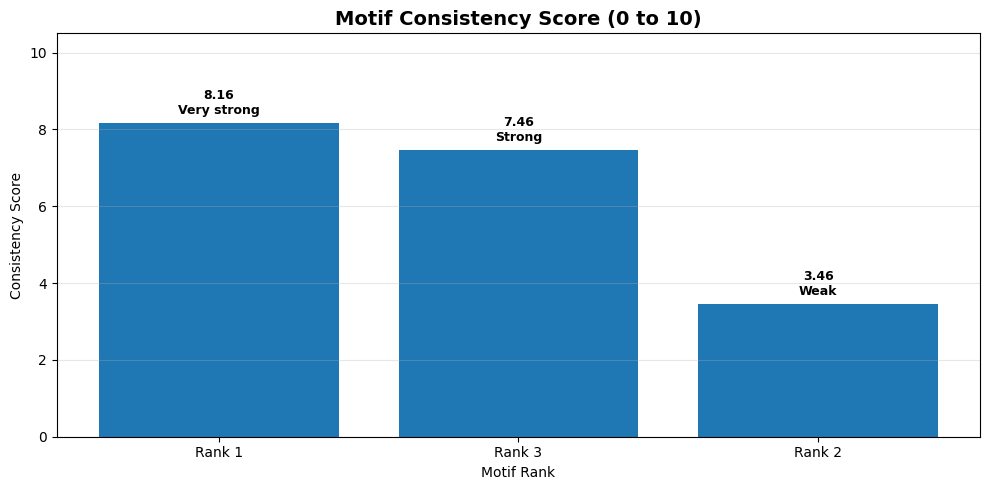

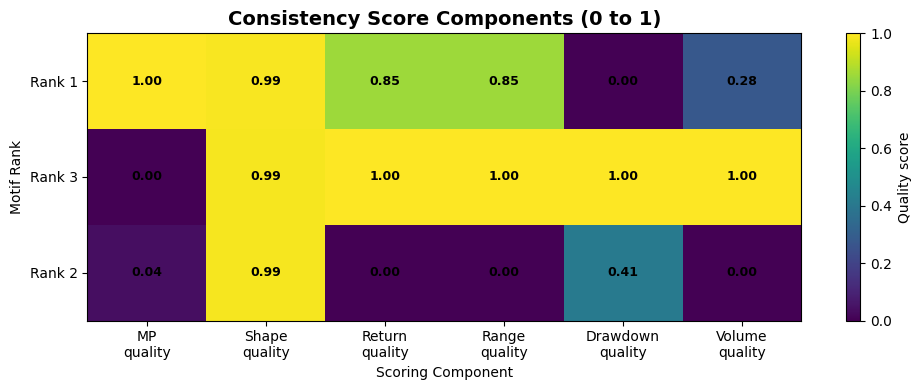

Interpretation:
- The bar chart shows the final 0-10 consistency score for each motif pair.
- The heatmap shows which components made a motif strong or weak.
- A strong motif should have both good shape quality and good financial-behavior similarity.


In [18]:
# ============================================================
# CELL 17: CONSISTENCY SCORE VISUALIZATION
# ============================================================

if consistency_df.empty:
    print("No consistency scores available to visualize.")
else:
    viz_df = consistency_df.copy()

    # Keep original rank order for clean labels
    viz_df["rank_label"] = viz_df["rank"].apply(lambda x: f"Rank {x}")

    # --------------------------------------------------------
    # 1. Overall 0-10 consistency score
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))

    score_values = viz_df["consistency_score_0_10"].to_numpy()
    labels = viz_df["rank_label"].tolist()

    bars = ax.bar(labels, score_values)

    ax.set_title("Motif Consistency Score (0 to 10)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Motif Rank")
    ax.set_ylabel("Consistency Score")
    ax.set_ylim(0, 10.5)
    ax.grid(True, axis="y", alpha=0.3)

    # Add value labels
    for bar, val, label in zip(bars, score_values, viz_df["consistency_label"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.15,
            f"{val:.2f}\n{label}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 2. Component-level quality heatmap
    # --------------------------------------------------------
    component_cols = [
        "mp_quality",
        "shape_quality",
        "return_quality",
        "range_quality",
        "drawdown_quality",
        "volume_quality",
    ]

    component_labels = [
        "MP\nquality",
        "Shape\nquality",
        "Return\nquality",
        "Range\nquality",
        "Drawdown\nquality",
        "Volume\nquality",
    ]

    heatmap_data = viz_df[component_cols].to_numpy()

    fig, ax = plt.subplots(figsize=(10, 4))

    im = ax.imshow(
        heatmap_data,
        aspect="auto",
        vmin=0,
        vmax=1
    )

    ax.set_title("Consistency Score Components (0 to 1)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Scoring Component")
    ax.set_ylabel("Motif Rank")

    ax.set_xticks(np.arange(len(component_labels)))
    ax.set_xticklabels(component_labels)

    ax.set_yticks(np.arange(len(viz_df)))
    ax.set_yticklabels(viz_df["rank_label"].tolist())

    # Annotate cells with values
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            ax.text(
                j, i,
                f"{heatmap_data[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Quality score")

    plt.tight_layout()
    plt.show()

    print("Interpretation:")
    print("- The bar chart shows the final 0-10 consistency score for each motif pair.")
    print("- The heatmap shows which components made a motif strong or weak.")
    print("- A strong motif should have both good shape quality and good financial-behavior similarity.")

## Boxplots for Motif Behavior

The boxplots summarize the distribution of motif-level behavior.

For now, the first experiment uses only a small number of motifs, so these boxplots are mainly illustrative. However, once I extract the top 15 motifs or run the notebook on longer time periods, these plots become more useful.

The boxplots compare motif windows and nearest-neighbor windows for:

| Metric | Purpose |
|---|---|
| Return | Direction and magnitude of movement |
| Intrawindow range | Local price amplitude |
| Max drawdown | Downside movement inside the window |
| Realized volatility | Local variability |
| Volume | Trading activity |
| Consistency score | Overall motif reliability |

The main purpose is to check whether the matched motif windows behave similarly as a group, not only as individual pairs.

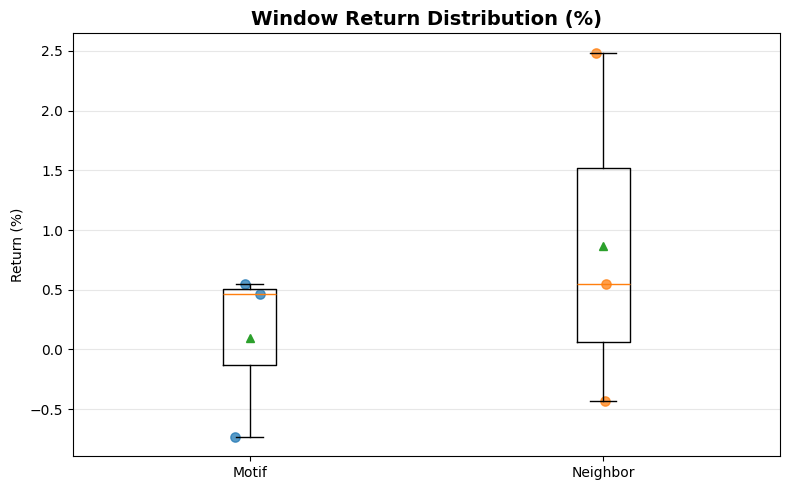

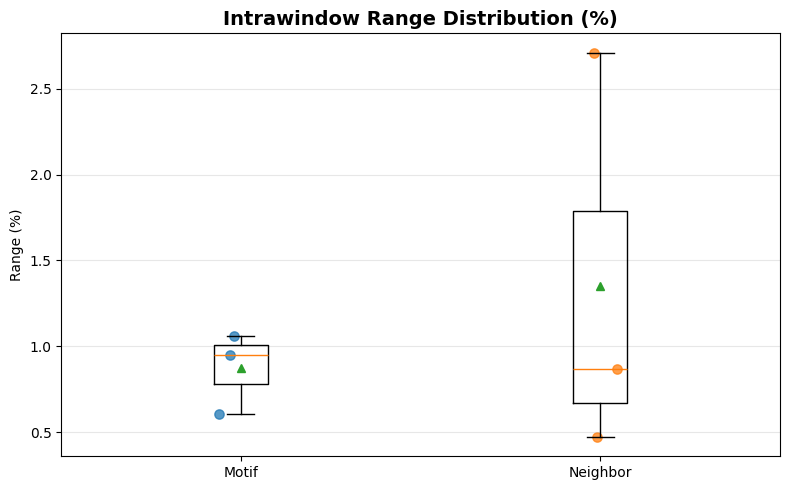

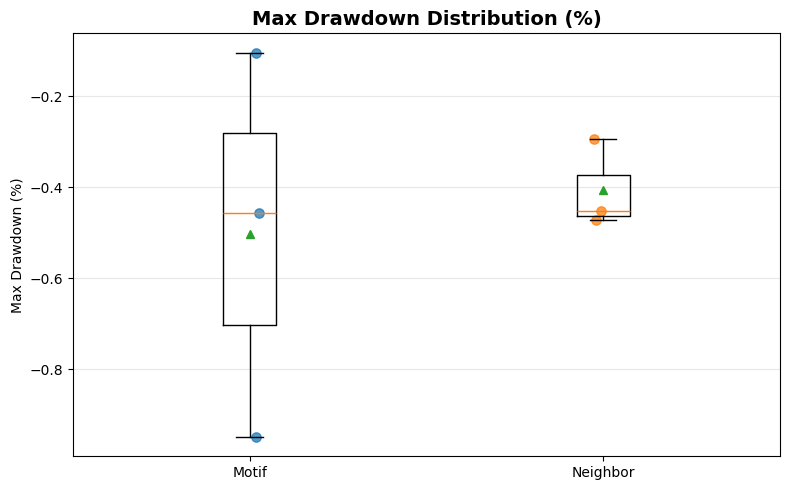

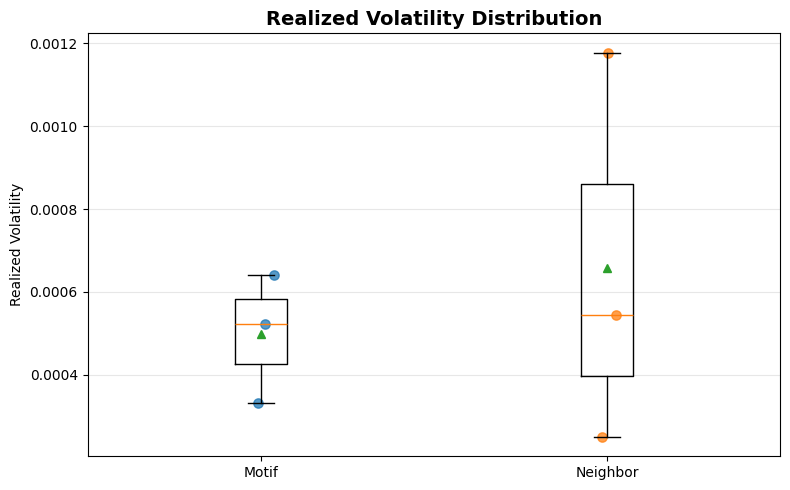

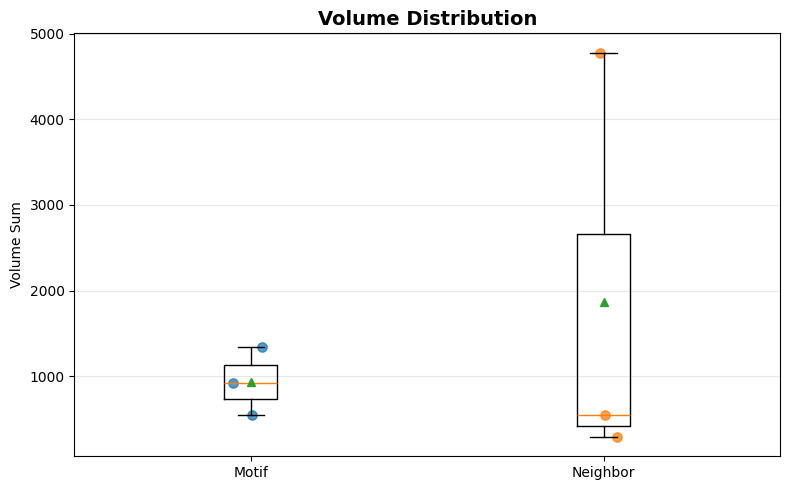

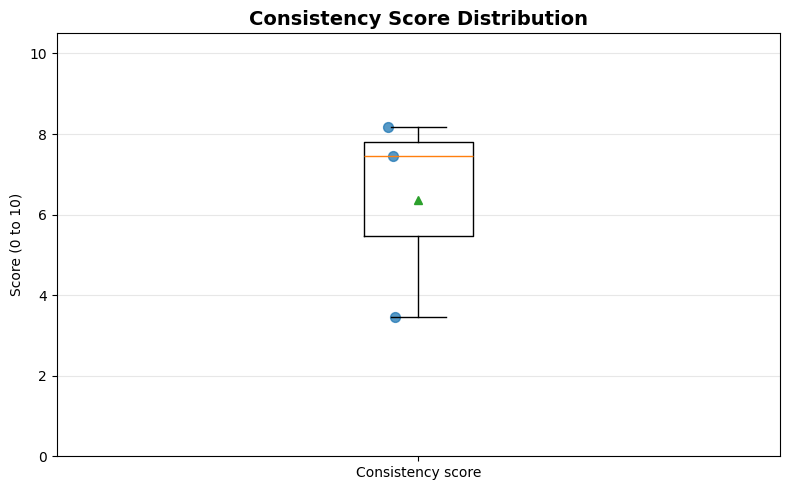

Boxplot interpretation:
- Box plots summarize the distribution of motif-level behavior.
- With TOP_K_MOTIFS=3, they are mainly illustrative.
- With TOP_K_MOTIFS=15 or more, they become useful for comparing motif populations.
- Large differences between motif and neighbor distributions suggest shape similarity may not imply financial similarity.


In [19]:
# ============================================================
# CELL 18: BOXPLOTS FOR MOTIF BEHAVIOR DISTRIBUTIONS
# ============================================================

if motif_stats_df.empty:
    print("No motif statistics available for box plots.")
else:
    boxplot_df = motif_stats_df.copy()

    # --------------------------------------------------------
    # Prepare paired distributions
    # --------------------------------------------------------

    boxplot_specs = [
        {
            "title": "Window Return Distribution (%)",
            "ylabel": "Return (%)",
            "motif_col": "motif_return_pct",
            "neighbor_col": "neighbor_return_pct",
            "labels": ["Motif", "Neighbor"],
        },
        {
            "title": "Intrawindow Range Distribution (%)",
            "ylabel": "Range (%)",
            "motif_col": "motif_range_pct",
            "neighbor_col": "neighbor_range_pct",
            "labels": ["Motif", "Neighbor"],
        },
        {
            "title": "Max Drawdown Distribution (%)",
            "ylabel": "Max Drawdown (%)",
            "motif_col": "motif_max_drawdown_pct",
            "neighbor_col": "neighbor_max_drawdown_pct",
            "labels": ["Motif", "Neighbor"],
        },
        {
            "title": "Realized Volatility Distribution",
            "ylabel": "Realized Volatility",
            "motif_col": "motif_realized_vol",
            "neighbor_col": "neighbor_realized_vol",
            "labels": ["Motif", "Neighbor"],
        },
        {
            "title": "Volume Distribution",
            "ylabel": "Volume Sum",
            "motif_col": "motif_volume_sum",
            "neighbor_col": "neighbor_volume_sum",
            "labels": ["Motif", "Neighbor"],
        },
    ]

    for spec in boxplot_specs:
        data = [
            boxplot_df[spec["motif_col"]].dropna().to_numpy(),
            boxplot_df[spec["neighbor_col"]].dropna().to_numpy(),
        ]

        fig, ax = plt.subplots(figsize=(8, 5))

        ax.boxplot(
            data,
            labels=spec["labels"],
            showmeans=True
        )

        # Add individual points for transparency
        for i, values in enumerate(data, start=1):
            x_jitter = np.random.normal(loc=i, scale=0.025, size=len(values))
            ax.scatter(
                x_jitter,
                values,
                alpha=0.75,
                s=45
            )

        ax.set_title(spec["title"], fontsize=14, fontweight="bold")
        ax.set_ylabel(spec["ylabel"])
        ax.grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # Consistency score distribution
    # --------------------------------------------------------

    if "consistency_df" in globals() and not consistency_df.empty:
        fig, ax = plt.subplots(figsize=(8, 5))

        scores = consistency_df["consistency_score_0_10"].dropna().to_numpy()

        ax.boxplot(
            [scores],
            labels=["Consistency score"],
            showmeans=True
        )

        x_jitter = np.random.normal(loc=1, scale=0.025, size=len(scores))
        ax.scatter(
            x_jitter,
            scores,
            alpha=0.75,
            s=50
        )

        ax.set_title("Consistency Score Distribution", fontsize=14, fontweight="bold")
        ax.set_ylabel("Score (0 to 10)")
        ax.set_ylim(0, 10.5)
        ax.grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

    print("Boxplot interpretation:")
    print("- Box plots summarize the distribution of motif-level behavior.")
    print("- With TOP_K_MOTIFS=3, they are mainly illustrative.")
    print("- With TOP_K_MOTIFS=15 or more, they become useful for comparing motif populations.")
    print("- Large differences between motif and neighbor distributions suggest shape similarity may not imply financial similarity.")

## Boxplot Findings

The boxplots show that the current top motifs are not equally consistent across all financial dimensions.

The return and range plots show that some nearest-neighbor windows have larger movement magnitude than their corresponding motif windows. This is especially visible in the neighbor distribution, which has wider spread.

The max drawdown plot also shows differences in downside behavior. This means that even when Matrix Profile detects similar shapes, the risk behavior inside the windows may differ.

The volume distribution is especially important. Some matched windows have much higher trading activity than others. This suggests that price-shape similarity and market-activity similarity are not always the same thing.

The consistency score distribution summarizes this clearly: the current set contains strong motifs, but also at least one weak motif. This is a useful result because it shows why motif evaluation needs multiple dimensions.

## Motif Distance in Pattern Space

To understand motif relationships more clearly, I represent each motif window as a point in a pattern space.

The process is:

1. Extract each motif and nearest-neighbor window.
2. Z-normalize each window.
3. Treat each window as a vector of length `m`.
4. Compute pairwise Euclidean distances between these vectors.
5. Project the vectors into two dimensions using PCA.

This allows me to ask:

> Are matched motif pairs close to each other in shape space?

If the Matrix Profile match is meaningful, then each motif and its nearest neighbor should appear close together in this space.

This is useful because it turns motif discovery into a geometric interpretation.

Pairwise Euclidean distance matrix between motif windows:


label,M1,N1,M2,N2,M3,N3
label,,,,,,
M1,0.000,1.576,14.296,14.150,14.552,14.447
N1,1.576,0.000,14.392,14.314,14.461,14.362
M2,14.296,14.392,0.000,1.818,4.624,4.301
N2,14.150,14.314,1.818,0.000,5.340,4.862
M3,14.552,14.461,4.624,5.340,0.000,1.828
N3,14.447,14.362,4.301,4.862,1.828,0.000


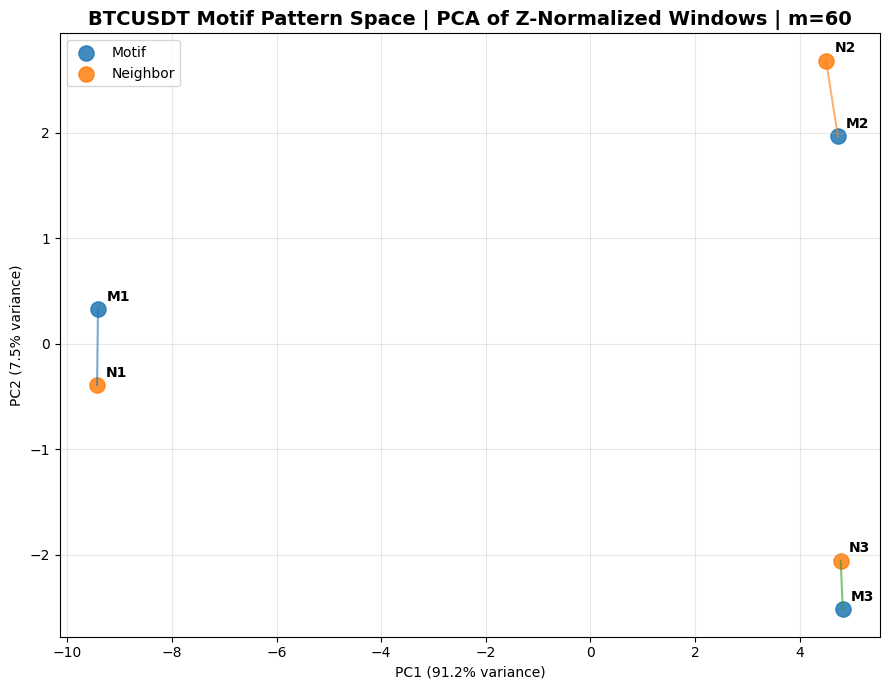

Interpretation:
- Each point is one motif or nearest-neighbor window.
- Points close together have similar z-normalized shape.
- Lines connect Matrix Profile matched pairs.
- If matched pairs are close in PCA space, the motif relation is visually supported.


In [20]:
# ============================================================
# CELL 19: MOTIF DISTANCE SPACE WITH PCA
# ============================================================

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

if motifs_df.empty:
    print("No motifs available for distance-space analysis.")
else:
    # --------------------------------------------------------
    # Collect motif and neighbor sequences
    # --------------------------------------------------------

    pattern_records = []
    pattern_vectors = []

    for _, row in motifs_df.iterrows():
        rank = int(row["rank"])

        motif_idx = int(row["motif_idx"])
        neighbor_idx = int(row["neighbor_idx"])

        motif_seq = series[motif_idx:motif_idx + m]
        neighbor_seq = series[neighbor_idx:neighbor_idx + m]

        motif_seq_z = z_normalize(motif_seq)
        neighbor_seq_z = z_normalize(neighbor_seq)

        pattern_vectors.append(motif_seq_z)
        pattern_records.append({
            "label": f"M{rank}",
            "rank": rank,
            "type": "Motif",
            "start_time": row["motif_start"],
            "end_time": row["motif_end"],
            "profile_value": row["profile_value"],
        })

        pattern_vectors.append(neighbor_seq_z)
        pattern_records.append({
            "label": f"N{rank}",
            "rank": rank,
            "type": "Neighbor",
            "start_time": row["neighbor_start"],
            "end_time": row["neighbor_end"],
            "profile_value": row["profile_value"],
        })

    pattern_matrix = np.vstack(pattern_vectors)
    pattern_space_df = pd.DataFrame(pattern_records)

    # --------------------------------------------------------
    # Pairwise distance matrix in z-normalized sequence space
    # --------------------------------------------------------

    distance_matrix = pairwise_distances(pattern_matrix, metric="euclidean")

    distance_df = pd.DataFrame(
        distance_matrix,
        index=pattern_space_df["label"],
        columns=pattern_space_df["label"]
    )

    print("Pairwise Euclidean distance matrix between motif windows:")
    display(distance_df.round(3))

    # --------------------------------------------------------
    # PCA projection to 2D pattern space
    # --------------------------------------------------------

    if pattern_matrix.shape[0] >= 2:
        pca = PCA(n_components=2)
        coords = pca.fit_transform(pattern_matrix)

        pattern_space_df["pc1"] = coords[:, 0]
        pattern_space_df["pc2"] = coords[:, 1]

        explained = pca.explained_variance_ratio_

        fig, ax = plt.subplots(figsize=(9, 7))

        for pattern_type in pattern_space_df["type"].unique():
            subset = pattern_space_df[pattern_space_df["type"] == pattern_type]

            ax.scatter(
                subset["pc1"],
                subset["pc2"],
                s=120,
                label=pattern_type,
                alpha=0.85
            )

            for _, r in subset.iterrows():
                ax.annotate(
                    r["label"],
                    (r["pc1"], r["pc2"]),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=10,
                    fontweight="bold"
                )

        # Draw lines between matched motif-neighbor pairs
        for rank in pattern_space_df["rank"].unique():
            pair = pattern_space_df[pattern_space_df["rank"] == rank]

            if len(pair) == 2:
                ax.plot(
                    pair["pc1"],
                    pair["pc2"],
                    linewidth=1.5,
                    alpha=0.6
                )

        ax.set_title(
            f"{ASSET} Motif Pattern Space | PCA of Z-Normalized Windows | m={m}",
            fontsize=14,
            fontweight="bold"
        )
        ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}% variance)")
        ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}% variance)")
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

        print("Interpretation:")
        print("- Each point is one motif or nearest-neighbor window.")
        print("- Points close together have similar z-normalized shape.")
        print("- Lines connect Matrix Profile matched pairs.")
        print("- If matched pairs are close in PCA space, the motif relation is visually supported.")

## Motif Space Findings

The PCA motif-space plot gives a very clear result.

The matched pairs are close to each other:

| Pair | Euclidean distance |
|---|---:|
| M1 vs N1 | 1.576 |
| M2 vs N2 | 1.818 |
| M3 vs N3 | 1.828 |

This confirms that the Matrix Profile matches are geometrically close in z-normalized pattern space.

At the same time, different motif families are far apart. For example, M1 is very far from M2 and M3, with distances around 14. This means that the top motifs are not all the same pattern. They form separate local pattern families.

The PCA plot also supports this visually. PC1 explains most of the variation, so the main separation between motif families is captured clearly on the first principal component.

This is a strong interpretability result: the algorithm is not only finding individual matches, but also revealing different types of repeated structures.

## Window-Size Sensitivity Study

The window size controls the length of the market pattern being searched.

Since the data is sampled at 1-minute frequency:

| Window size | Meaning |
|---:|---|
| 15 | 15-minute pattern |
| 30 | 30-minute pattern |
| 60 | 1-hour pattern |
| 120 | 2-hour pattern |

This matters because short windows can capture micro-patterns, while longer windows capture broader intraday structures.

The purpose of this study is to check whether motif discovery is sensitive to the selected window length.

A robust motif-discovery workflow should not depend blindly on one arbitrary value of `m`. Instead, I need to understand how motif distances and motif quality change when the window size changes.

In [21]:
# ============================================================
# CELL 20: WINDOW-SIZE SENSITIVITY STUDY
# ============================================================

WINDOW_SIZES_TO_TEST = [15, 30, 60, 120]

# Keep this small for prototype.
# Later set this to 15 when you want thesis-style analysis.
WINDOW_STUDY_TOP_K = min(TOP_K_MOTIFS, 5)

window_study_records = []
window_study_motifs = {}

print("Starting window-size sensitivity study...")
print(f"Window sizes tested: {WINDOW_SIZES_TO_TEST}")
print(f"Top motifs per window size: {WINDOW_STUDY_TOP_K}")

for test_m in WINDOW_SIZES_TO_TEST:
    if len(series) <= test_m:
        print(f"Skipping m={test_m}: series too short.")
        continue

    print("\n" + "=" * 80)
    print(f"Processing window size m={test_m}")

    # --------------------------------------------------------
    # Use separate cache file for each window size
    # --------------------------------------------------------

    test_cache_path = make_mp_cache_path(
        asset=ASSET,
        analysis_type=ANALYSIS_TYPE,
        target_column=TARGET_COLUMN,
        window_minutes=test_m,
        run_mode=RUN_MODE,
        start_date=START_DATE,
        end_date=END_DATE,
    )

    test_cached = None if FORCE_RECOMPUTE else load_mp_cache(test_cache_path)

    if test_cached is not None:
        test_mp = test_cached["mp"]
        test_mpi = test_cached["mpi"]
        test_cache_used = True
        test_elapsed = 0.0
    else:
        print(f"Computing Matrix Profile for m={test_m}...")
        t0 = time.time()

        test_mp_raw = stumpy.stump(series, m=test_m)

        test_elapsed = time.time() - t0

        test_mp = test_mp_raw[:, 0].astype(float)
        test_mpi = test_mp_raw[:, 1].astype(int)

        save_mp_cache(
            test_cache_path,
            mp=test_mp,
            mpi=test_mpi,
            series=series,
            timestamps=timestamps.astype(str).to_numpy(),
            m=np.array([test_m]),
            asset=np.array([ASSET]),
            analysis_type=np.array([ANALYSIS_TYPE]),
            target_column=np.array([TARGET_COLUMN]),
            run_mode=np.array([RUN_MODE]),
            start_date=np.array([str(START_DATE)]),
            end_date=np.array([str(END_DATE)]),
        )

        test_cache_used = False

    # --------------------------------------------------------
    # Extract motifs for this window size
    # --------------------------------------------------------

    test_motifs_df = extract_top_k_motifs(
        mp=test_mp,
        mpi=test_mpi,
        timestamps=timestamps,
        m=test_m,
        top_k=WINDOW_STUDY_TOP_K,
    )

    window_study_motifs[test_m] = test_motifs_df

    # --------------------------------------------------------
    # Compute basic summary metrics
    # --------------------------------------------------------

    finite_mp = test_mp[np.isfinite(test_mp)]

    top_profile_values = (
        test_motifs_df["profile_value"].to_numpy()
        if not test_motifs_df.empty
        else np.array([])
    )

    if len(top_profile_values) > 0:
        top_min = float(np.min(top_profile_values))
        top_mean = float(np.mean(top_profile_values))
        top_median = float(np.median(top_profile_values))
        top_std = float(np.std(top_profile_values))
    else:
        top_min = np.nan
        top_mean = np.nan
        top_median = np.nan
        top_std = np.nan

    window_study_records.append({
        "window_minutes": test_m,
        "subsequence_count": int(len(series) - test_m + 1),
        "cache_used": test_cache_used,
        "elapsed_seconds": float(test_elapsed),
        "finite_mp_count": int(len(finite_mp)),
        "global_mp_min": float(np.min(finite_mp)),
        "global_mp_mean": float(np.mean(finite_mp)),
        "global_mp_median": float(np.median(finite_mp)),
        "top_k_used": int(len(test_motifs_df)),
        "top_motif_min_distance": top_min,
        "top_motif_mean_distance": top_mean,
        "top_motif_median_distance": top_median,
        "top_motif_std_distance": top_std,
    })

window_study_df = pd.DataFrame(window_study_records)

print("\nWindow-size sensitivity summary:")
display(window_study_df)

Starting window-size sensitivity study...
Window sizes tested: [15, 30, 60, 120]
Top motifs per window size: 3

Processing window size m=15
No cache found. Matrix Profile will be computed.
Computing Matrix Profile for m=15...
Saved Matrix Profile cache:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\matrix_profiles\BTCUSDT_raw_close_close_m15_quick_2025-01-01_to_2025-01-08.npz

Processing window size m=30
No cache found. Matrix Profile will be computed.
Computing Matrix Profile for m=30...
Saved Matrix Profile cache:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\matrix_profiles\BTCUSDT_raw_close_close_m30_quick_2025-01-01_to_2025-01-08.npz

Processing window size m=60
Loaded Matrix Profile cache:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\matrix_profiles\BTCUSDT_raw_close_close_m60_quick_2025-01-01_to_2025-01-08.npz

Processing window size m=120
No cache found. Matrix Profile will be computed.
C

,window_minutes,subsequence_count,cache_used,elapsed_seconds,finite_mp_count,global_mp_min,global_mp_mean,global_mp_median,top_k_used,top_motif_min_distance,top_motif_mean_distance,top_motif_median_distance,top_motif_std_distance
0,15,10066,False,24.515024,10066,0.434005,1.384250,1.340545,3,0.434005,0.455728,0.454868,0.018098
1,30,10051,False,0.102421,10051,0.830394,2.395488,2.350963,3,0.830394,0.886404,0.913342,0.039615
2,60,10021,True,0.000000,10021,1.576078,3.760645,3.650943,3,1.576078,1.740516,1.817904,0.116342
3,120,9961,False,0.114624,9961,2.281122,5.628580,5.525169,3,2.281122,2.640961,2.803126,0.254858


## Window-Size Sensitivity Findings

The window-size study produced the expected pattern: longer windows have larger Matrix Profile distances.

| Window size | Mean top motif distance |
|---:|---:|
| 15 | 0.456 |
| 30 | 0.886 |
| 60 | 1.741 |
| 120 | 2.641 |

This makes sense because matching a longer subsequence is harder than matching a short one. A 15-minute pattern has fewer points and more chances to find a close match. A 120-minute pattern requires similarity over a much longer period.

The key interpretation is not that smaller windows are automatically better. Instead:

- smaller windows capture local microstructure
- larger windows capture broader intraday behavior
- distance values naturally increase with window length
- comparisons should be made within the same window size

This gives a strong basis for later sensitivity analysis in the thesis.

## Visualizing Window-Size Sensitivity

The next plots summarize how motif quality changes as the subsequence length changes.

The visualizations include:

1. Window size versus top motif distance.
2. Window size versus the overall Matrix Profile level.
3. Runtime by window size.
4. Boxplots of top motif distances across window sizes.

These plots help answer whether the motif-discovery result is stable or highly dependent on the chosen window length.

This is important for the thesis because window length is one of the main methodological parameters in Matrix Profile based motif discovery.

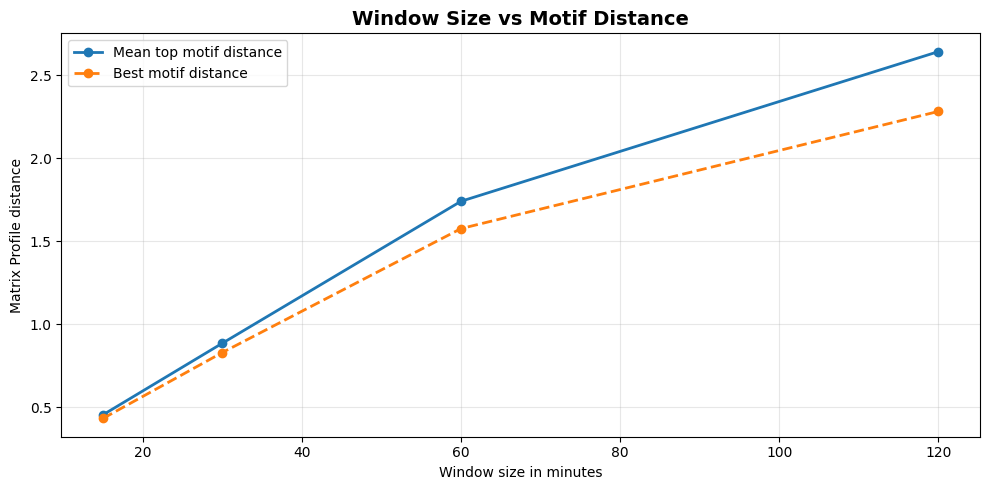

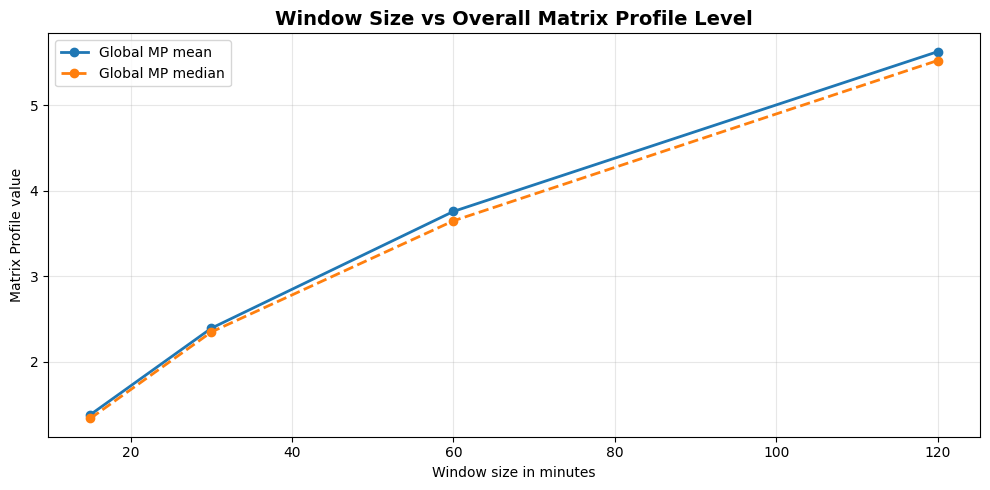

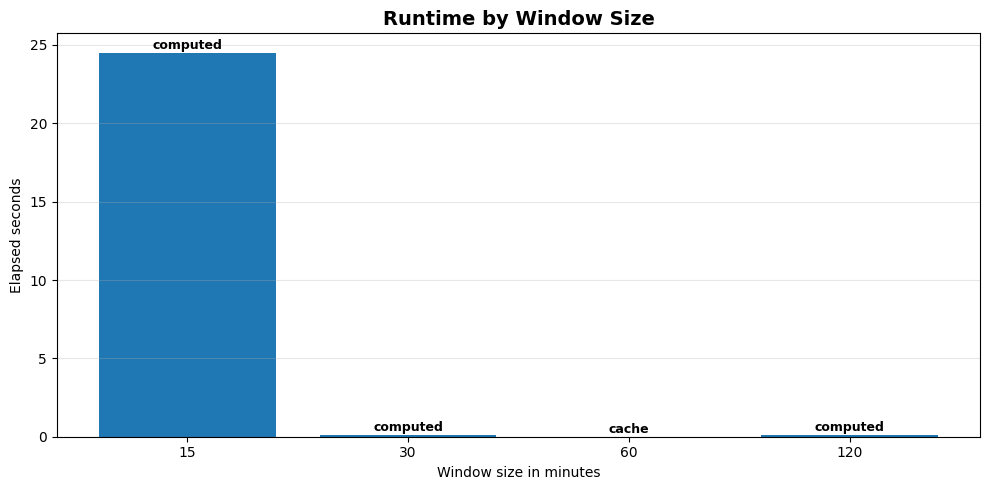

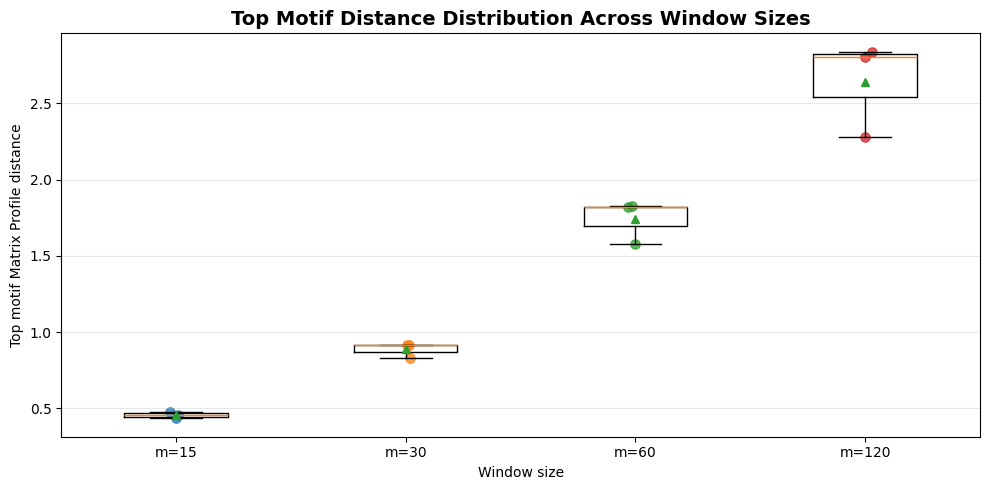

Window-size sensitivity interpretation:
- Larger windows usually have larger MP distances because matching longer patterns is harder.
- If the best motifs remain strong across nearby window sizes, that supports robustness.
- If motif quality changes sharply with m, the result is window-size sensitive.
- This is directly useful for thesis sensitivity analysis.


In [22]:
# ============================================================
# CELL 21: WINDOW-SIZE SENSITIVITY VISUALIZATIONS
# ============================================================

if window_study_df.empty:
    print("No window-size study results available.")
else:
    ws_df = window_study_df.copy()

    # --------------------------------------------------------
    # 1. Window size vs top motif distance
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        ws_df["window_minutes"],
        ws_df["top_motif_mean_distance"],
        marker="o",
        linewidth=2,
        label="Mean top motif distance"
    )

    ax.plot(
        ws_df["window_minutes"],
        ws_df["top_motif_min_distance"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Best motif distance"
    )

    ax.set_title(
        "Window Size vs Motif Distance",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Window size in minutes")
    ax.set_ylabel("Matrix Profile distance")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 2. Window size vs global Matrix Profile level
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        ws_df["window_minutes"],
        ws_df["global_mp_mean"],
        marker="o",
        linewidth=2,
        label="Global MP mean"
    )

    ax.plot(
        ws_df["window_minutes"],
        ws_df["global_mp_median"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Global MP median"
    )

    ax.set_title(
        "Window Size vs Overall Matrix Profile Level",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Window size in minutes")
    ax.set_ylabel("Matrix Profile value")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 3. Runtime / cache behavior
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        ws_df["window_minutes"].astype(str),
        ws_df["elapsed_seconds"]
    )

    ax.set_title(
        "Runtime by Window Size",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Window size in minutes")
    ax.set_ylabel("Elapsed seconds")
    ax.grid(True, axis="y", alpha=0.3)

    for i, row in ws_df.iterrows():
        label = "cache" if row["cache_used"] else "computed"
        ax.text(
            i,
            row["elapsed_seconds"] + 0.05,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 4. Boxplot of top motif distances across window sizes
    # --------------------------------------------------------

    distance_box_data = []
    distance_box_labels = []

    for test_m, df_motifs in window_study_motifs.items():
        if df_motifs is not None and not df_motifs.empty:
            distance_box_data.append(df_motifs["profile_value"].to_numpy())
            distance_box_labels.append(f"m={test_m}")

    if len(distance_box_data) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))

        ax.boxplot(
            distance_box_data,
            labels=distance_box_labels,
            showmeans=True
        )

        for i, values in enumerate(distance_box_data, start=1):
            x_jitter = np.random.normal(loc=i, scale=0.025, size=len(values))
            ax.scatter(
                x_jitter,
                values,
                alpha=0.75,
                s=45
            )

        ax.set_title(
            "Top Motif Distance Distribution Across Window Sizes",
            fontsize=14,
            fontweight="bold"
        )
        ax.set_xlabel("Window size")
        ax.set_ylabel("Top motif Matrix Profile distance")
        ax.grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

    print("Window-size sensitivity interpretation:")
    print("- Larger windows usually have larger MP distances because matching longer patterns is harder.")
    print("- If the best motifs remain strong across nearby window sizes, that supports robustness.")
    print("- If motif quality changes sharply with m, the result is window-size sensitive.")
    print("- This is directly useful for thesis sensitivity analysis.")

## Window-Size Visualization Findings

The plots confirm that Matrix Profile distances increase as the window size becomes longer.

This is visible both in the top motif distance plot and in the overall Matrix Profile level plot.

The boxplot also shows that each window size has its own distance scale. Therefore, raw Matrix Profile values should not be compared directly across different window sizes without interpretation.

The runtime plot confirms that caching is useful. Once a Matrix Profile is computed and stored, repeated analysis becomes much faster.

This supports the notebook design decision to cache every run using asset, feature, window size, and timeframe as key components.

## Extracting the Top 15 Motifs

The first visual prototype used only the top 3 motifs to keep the notebook readable.

However, for a more serious analysis, I need a larger motif set. Therefore, I extract the top 15 non-overlapping motifs from the already computed Matrix Profile.

This step is cheap because the expensive Matrix Profile computation has already been cached.

The important distinction is:

| Step | Computational cost |
|---|---|
| Computing Matrix Profile | Expensive |
| Extracting more motifs from saved profile | Cheap |

This means I can use top 3 for visual debugging and top 15 for analysis without recomputing the Matrix Profile.

In [23]:
# ============================================================
# CELL 22: TOP-15 MOTIF EXTRACTION FROM CACHED MATRIX PROFILE
# ============================================================

TOP_K_EXTENDED = 15

extended_motifs_df = extract_top_k_motifs(
    mp=mp,
    mpi=mpi,
    timestamps=timestamps,
    m=m,
    top_k=TOP_K_EXTENDED,
)

print(f"Extracted top {len(extended_motifs_df)} non-overlapping motif pairs from cached Matrix Profile.")
print(f"Window size: m={m}")
print(f"Target column: {TARGET_COLUMN}")
print(f"Analysis type: {ANALYSIS_TYPE}")

display_cols = [
    "rank",
    "motif_start",
    "motif_end",
    "neighbor_start",
    "neighbor_end",
    "profile_value",
    "window_minutes",
    "target_column",
    "analysis_type",
]

display(extended_motifs_df[display_cols])

Extracted top 15 non-overlapping motif pairs from cached Matrix Profile.
Window size: m=60
Target column: close
Analysis type: raw_close


,rank,motif_start,motif_end,neighbor_start,neighbor_end,profile_value,window_minutes,target_column,analysis_type
0,1,2025-01-07 10:52:00+00:00,2025-01-07 11:51:00+00:00,2025-01-05 07:15:00+00:00,2025-01-05 08:14:00+00:00,1.576078,60,close,raw_close
1,2,2025-01-03 08:55:00+00:00,2025-01-03 09:54:00+00:00,2025-01-06 14:27:00+00:00,2025-01-06 15:26:00+00:00,1.817904,60,close,raw_close
2,3,2025-01-02 04:01:00+00:00,2025-01-02 05:00:00+00:00,2025-01-01 13:23:00+00:00,2025-01-01 14:22:00+00:00,1.827565,60,close,raw_close
3,4,2025-01-03 15:35:00+00:00,2025-01-03 16:34:00+00:00,2025-01-05 19:30:00+00:00,2025-01-05 20:29:00+00:00,1.946844,60,close,raw_close
4,5,2025-01-05 14:16:00+00:00,2025-01-05 15:15:00+00:00,2025-01-04 04:52:00+00:00,2025-01-04 05:51:00+00:00,1.948452,60,close,raw_close
5,6,2025-01-06 20:56:00+00:00,2025-01-06 21:55:00+00:00,2025-01-06 08:00:00+00:00,2025-01-06 08:59:00+00:00,1.972554,60,close,raw_close
6,7,2025-01-02 15:51:00+00:00,2025-01-02 16:50:00+00:00,2025-01-02 08:18:00+00:00,2025-01-02 09:17:00+00:00,2.015337,60,close,raw_close
7,8,2025-01-01 04:59:00+00:00,2025-01-01 05:58:00+00:00,2025-01-04 18:47:00+00:00,2025-01-04 19:46:00+00:00,2.081173,60,close,raw_close
8,9,2025-01-04 17:20:00+00:00,2025-01-04 18:19:00+00:00,2025-01-04 20:06:00+00:00,2025-01-04 21:05:00+00:00,2.092098,60,close,raw_close
9,10,2025-01-07 14:46:00+00:00,2025-01-07 15:45:00+00:00,2025-01-07 16:39:00+00:00,2025-01-07 17:38:00+00:00,2.106748,60,close,raw_close


## Top 15 Motif Findings

The top 15 raw-close motifs were successfully extracted from the cached Matrix Profile.

The profile values range from approximately:

| Rank | Profile value |
|---:|---:|
| Rank 1 | 1.576 |
| Rank 15 | 2.271 |

This gradual increase is useful. It means the motif quality does not collapse immediately after the first few motifs. Instead, there is a smooth decay in similarity strength.

This gives a broader motif population for later analysis, including timing analysis, event matching, and representation comparison.

## Top 15 Motif Timing and Appearance Analysis

After extracting the top 15 motifs, I analyze where and when they appear.

This is important because motif discovery should not only return distance scores. It should also tell me whether repeated patterns are concentrated in specific market periods.

The next visualizations show:

1. The distance ranking of the top 15 motifs.
2. The distribution of motif start hours.
3. Motif and nearest-neighbor appearances on the original price timeline.

This helps answer:

- Are motifs spread across the full period?
- Do motifs cluster around specific hours?
- Do repeated patterns appear before or after large price moves?
- Are motifs concentrated in calm or volatile regions?

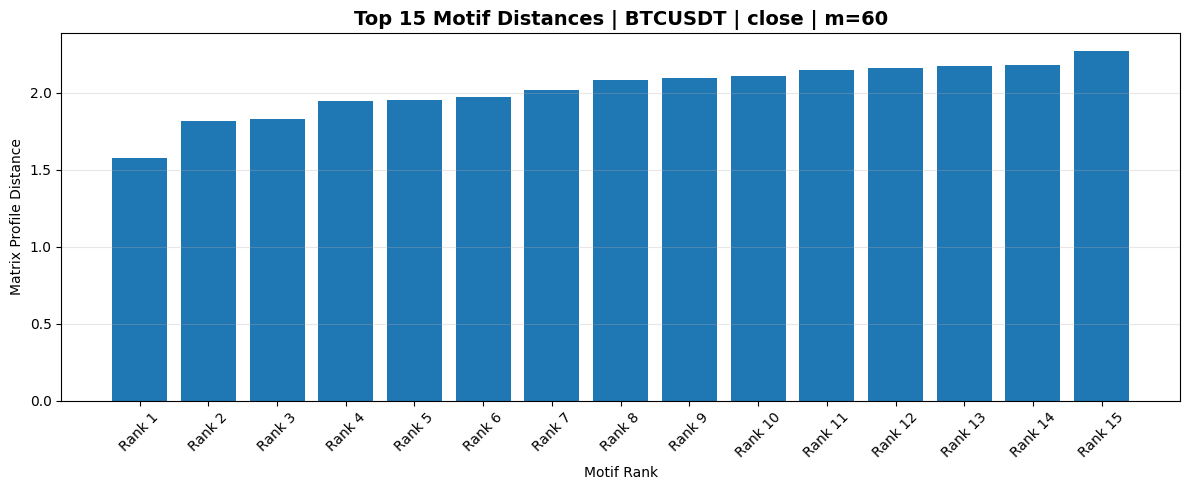

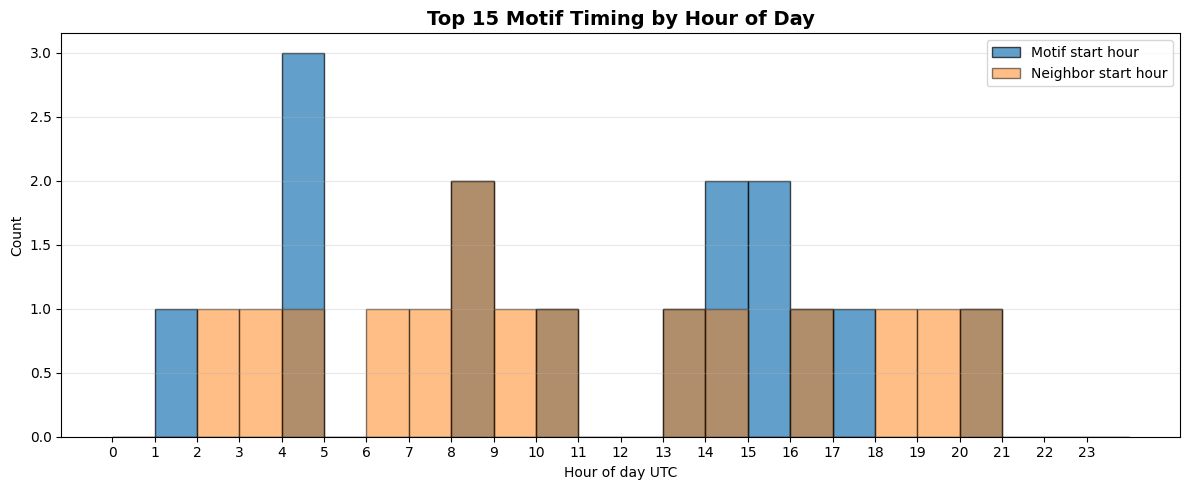

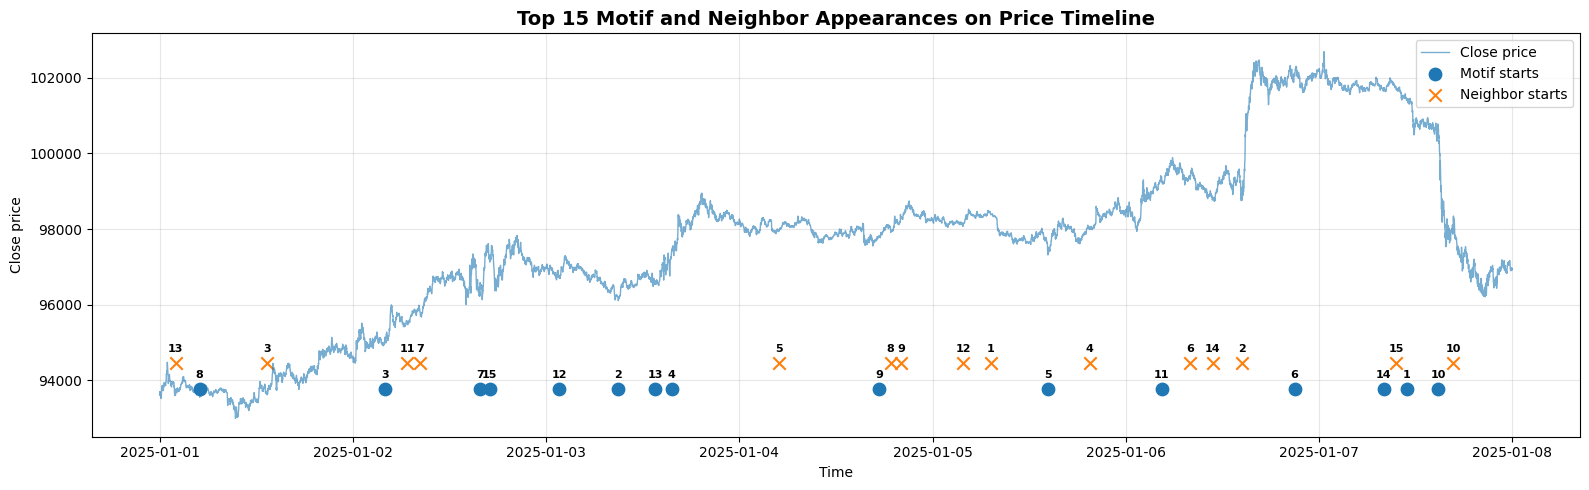

Top-15 timing interpretation:
- The distance ranking shows how motif quality decays from rank 1 to rank 15.
- The hour histogram shows whether motifs cluster around specific UTC trading hours.
- The event strip shows where motif and neighbor appearances occur on the price timeline.


In [24]:
# ============================================================
# CELL 23: TOP-15 MOTIF DISTANCE AND TIMING VISUALIZATION
# ============================================================

if extended_motifs_df.empty:
    print("No extended motifs available for visualization.")
else:
    top15_viz_df = extended_motifs_df.copy()

    top15_viz_df["motif_start"] = pd.to_datetime(top15_viz_df["motif_start"], utc=True)
    top15_viz_df["neighbor_start"] = pd.to_datetime(top15_viz_df["neighbor_start"], utc=True)

    top15_viz_df["rank_label"] = top15_viz_df["rank"].apply(lambda x: f"Rank {x}")
    top15_viz_df["motif_hour"] = top15_viz_df["motif_start"].dt.hour
    top15_viz_df["neighbor_hour"] = top15_viz_df["neighbor_start"].dt.hour
    top15_viz_df["motif_date"] = top15_viz_df["motif_start"].dt.date
    top15_viz_df["neighbor_date"] = top15_viz_df["neighbor_start"].dt.date

    # --------------------------------------------------------
    # 1. Top-15 distance ranking
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(
        top15_viz_df["rank_label"],
        top15_viz_df["profile_value"]
    )

    ax.set_title(
        f"Top {len(top15_viz_df)} Motif Distances | {ASSET} | {TARGET_COLUMN} | m={m}",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Motif Rank")
    ax.set_ylabel("Matrix Profile Distance")
    ax.grid(True, axis="y", alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 2. Motif start hour distribution
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(12, 5))

    hour_bins = np.arange(0, 25)

    ax.hist(
        top15_viz_df["motif_hour"],
        bins=hour_bins,
        alpha=0.7,
        label="Motif start hour",
        edgecolor="black"
    )

    ax.hist(
        top15_viz_df["neighbor_hour"],
        bins=hour_bins,
        alpha=0.5,
        label="Neighbor start hour",
        edgecolor="black"
    )

    ax.set_title(
        f"Top {len(top15_viz_df)} Motif Timing by Hour of Day",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Hour of day UTC")
    ax.set_ylabel("Count")
    ax.set_xticks(np.arange(0, 24, 1))
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 3. Motif event strip on timeline
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(16, 5))

    ax.plot(
        analysis_df["timestamp"],
        analysis_df["close"],
        linewidth=1.0,
        alpha=0.6,
        label="Close price"
    )

    y_base = analysis_df["close"].min()
    y_range = analysis_df["close"].max() - analysis_df["close"].min()
    y_motif = y_base + 0.08 * y_range
    y_neighbor = y_base + 0.15 * y_range

    ax.scatter(
        top15_viz_df["motif_start"],
        [y_motif] * len(top15_viz_df),
        s=80,
        marker="o",
        label="Motif starts"
    )

    ax.scatter(
        top15_viz_df["neighbor_start"],
        [y_neighbor] * len(top15_viz_df),
        s=80,
        marker="x",
        label="Neighbor starts"
    )

    for _, row in top15_viz_df.iterrows():
        ax.annotate(
            f"{int(row['rank'])}",
            (row["motif_start"], y_motif),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
            fontweight="bold"
        )

        ax.annotate(
            f"{int(row['rank'])}",
            (row["neighbor_start"], y_neighbor),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
            fontweight="bold"
        )

    ax.set_title(
        f"Top {len(top15_viz_df)} Motif and Neighbor Appearances on Price Timeline",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Close price")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print("Top-15 timing interpretation:")
    print("- The distance ranking shows how motif quality decays from rank 1 to rank 15.")
    print("- The hour histogram shows whether motifs cluster around specific UTC trading hours.")
    print("- The event strip shows where motif and neighbor appearances occur on the price timeline.")

## Top 15 Timing Findings

The top 15 motif distances show a smooth increase from rank 1 to rank 15. This confirms that the motif list contains a range of strong to moderately strong repeated patterns.

The timing histogram suggests that motif appearances are not uniformly distributed across the day. In this 7-day prototype slice, several motif starts appear around early morning and afternoon UTC hours.

The event strip is especially useful because it places motif and nearest-neighbor appearances directly on the price timeline. This makes it possible to connect motif occurrences with visible market movement.

This is the first step toward later event-level analysis, where motif timestamps can be compared against:

- large BTC movements
- volatility spikes
- external crypto events
- VIX movement for equity experiments
- regime labels

## Raw Close vs Log-Return Motif Discovery

The next comparison checks whether motif discovery depends on the input representation.

I compare:

| Representation | Input series | Interpretation |
|---|---|---|
| Raw close | `close` | Repeated local price-level shapes |
| Log return | `log_return` | Repeated local return behavior |

This comparison is important because raw prices and returns represent different views of the market.

Raw close motifs may capture similar visual price shapes, while log-return motifs may capture similar movement behavior independent of price level.

The goal is not to decide which one is universally better. The goal is to understand how sensitive motif discovery is to representation choice.

In [25]:
# ============================================================
# CELL 24: RAW CLOSE VS LOG-RETURN MOTIF COMPARISON
# ============================================================

COMPARISON_FEATURES = {
    "raw_close": "close",
    "log_return": "log_return",
}

COMPARISON_TOP_K = 15

comparison_records = []
comparison_motifs = {}

print("Starting raw vs univariate feature comparison...")
print(f"Window size: m={m}")
print(f"Top K: {COMPARISON_TOP_K}")
print(f"Features compared: {COMPARISON_FEATURES}")

for comparison_name, comparison_col in COMPARISON_FEATURES.items():

    if comparison_col not in analysis_df.columns and comparison_col not in df.columns:
        print(f"Skipping {comparison_name}: column not found -> {comparison_col}")
        continue

    print("\n" + "=" * 80)
    print(f"Processing comparison: {comparison_name} | column={comparison_col}")

    # --------------------------------------------------------
    # Build comparison dataframe
    # --------------------------------------------------------

    if comparison_col in analysis_df.columns:
        comp_df = analysis_df[["timestamp", "open", "high", "low", "close", "volume", comparison_col]].copy()
    else:
        comp_df = df[["timestamp", "open", "high", "low", "close", "volume", comparison_col]].copy()

    # Avoid duplicate column issue when comparison_col == close
    comp_df = comp_df.loc[:, ~comp_df.columns.duplicated()].copy()

    comp_df[comparison_col] = pd.to_numeric(comp_df[comparison_col], errors="coerce")
    comp_df = comp_df.replace([np.inf, -np.inf], np.nan)
    comp_df = comp_df.dropna(subset=[comparison_col]).reset_index(drop=True)

    comp_series = comp_df[comparison_col].astype(float).to_numpy()
    comp_timestamps = comp_df["timestamp"].reset_index(drop=True)

    if len(comp_series) <= m:
        print(f"Skipping {comparison_name}: series too short after cleaning.")
        continue

    # --------------------------------------------------------
    # Cache path for this comparison
    # --------------------------------------------------------

    comp_cache_path = make_mp_cache_path(
        asset=ASSET,
        analysis_type=comparison_name,
        target_column=comparison_col,
        window_minutes=m,
        run_mode=RUN_MODE,
        start_date=START_DATE,
        end_date=END_DATE,
    )

    comp_cached = None if FORCE_RECOMPUTE else load_mp_cache(comp_cache_path)

    if comp_cached is not None:
        comp_mp = comp_cached["mp"]
        comp_mpi = comp_cached["mpi"]
        comp_cache_used = True
        comp_elapsed = 0.0
    else:
        print(f"Computing Matrix Profile for {comparison_name}...")
        t0 = time.time()

        comp_mp_raw = stumpy.stump(comp_series, m=m)

        comp_elapsed = time.time() - t0

        comp_mp = comp_mp_raw[:, 0].astype(float)
        comp_mpi = comp_mp_raw[:, 1].astype(int)

        save_mp_cache(
            comp_cache_path,
            mp=comp_mp,
            mpi=comp_mpi,
            series=comp_series,
            timestamps=comp_timestamps.astype(str).to_numpy(),
            m=np.array([m]),
            asset=np.array([ASSET]),
            analysis_type=np.array([comparison_name]),
            target_column=np.array([comparison_col]),
            run_mode=np.array([RUN_MODE]),
            start_date=np.array([str(START_DATE)]),
            end_date=np.array([str(END_DATE)]),
        )

        comp_cache_used = False

    # --------------------------------------------------------
    # Extract motifs
    # --------------------------------------------------------

    comp_motifs_df = extract_top_k_motifs(
        mp=comp_mp,
        mpi=comp_mpi,
        timestamps=comp_timestamps,
        m=m,
        top_k=COMPARISON_TOP_K,
    )

    comparison_motifs[comparison_name] = comp_motifs_df

    finite_comp_mp = comp_mp[np.isfinite(comp_mp)]

    comparison_records.append({
        "analysis_name": comparison_name,
        "target_column": comparison_col,
        "rows_used": int(len(comp_df)),
        "window_minutes": int(m),
        "top_k_requested": int(COMPARISON_TOP_K),
        "top_k_extracted": int(len(comp_motifs_df)),
        "cache_used": bool(comp_cache_used),
        "elapsed_seconds": float(comp_elapsed),
        "global_mp_min": float(np.min(finite_comp_mp)),
        "global_mp_mean": float(np.mean(finite_comp_mp)),
        "global_mp_median": float(np.median(finite_comp_mp)),
        "top_motif_min_distance": float(comp_motifs_df["profile_value"].min()),
        "top_motif_mean_distance": float(comp_motifs_df["profile_value"].mean()),
        "top_motif_median_distance": float(comp_motifs_df["profile_value"].median()),
        "top_motif_std_distance": float(comp_motifs_df["profile_value"].std()),
    })

comparison_summary_df = pd.DataFrame(comparison_records)

print("\nRaw vs univariate comparison summary:")
display(comparison_summary_df)

print("\nExtracted motif tables:")
for name, motifs_table in comparison_motifs.items():
    print(f"\n{name}:")
    display(motifs_table[[
        "rank",
        "motif_start",
        "neighbor_start",
        "profile_value",
        "window_minutes",
        "target_column",
        "analysis_type",
    ]].head(10))

Starting raw vs univariate feature comparison...
Window size: m=60
Top K: 15
Features compared: {'raw_close': 'close', 'log_return': 'log_return'}

Processing comparison: raw_close | column=close
Loaded Matrix Profile cache:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\matrix_profiles\BTCUSDT_raw_close_close_m60_quick_2025-01-01_to_2025-01-08.npz

Processing comparison: log_return | column=log_return
No cache found. Matrix Profile will be computed.
Computing Matrix Profile for log_return...
Saved Matrix Profile cache:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\matrix_profiles\BTCUSDT_log_return_log_return_m60_quick_2025-01-01_to_2025-01-08.npz

Raw vs univariate comparison summary:


,analysis_name,target_column,rows_used,window_minutes,top_k_requested,top_k_extracted,cache_used,elapsed_seconds,global_mp_min,global_mp_mean,global_mp_median,top_motif_min_distance,top_motif_mean_distance,top_motif_median_distance,top_motif_std_distance
0,raw_close,close,10080,60,15,15,True,0.000000,1.576078,3.760645,3.650943,1.576078,2.021175,2.081173,0.179772
1,log_return,log_return,10080,60,15,15,False,0.107223,5.700572,7.816817,7.868744,5.700572,6.739009,6.813526,0.397225



Extracted motif tables:

raw_close:


,rank,motif_start,neighbor_start,profile_value,window_minutes,target_column,analysis_type
0,1,2025-01-07 10:52:00+00:00,2025-01-05 07:15:00+00:00,1.576078,60,close,raw_close
1,2,2025-01-03 08:55:00+00:00,2025-01-06 14:27:00+00:00,1.817904,60,close,raw_close
2,3,2025-01-02 04:01:00+00:00,2025-01-01 13:23:00+00:00,1.827565,60,close,raw_close
3,4,2025-01-03 15:35:00+00:00,2025-01-05 19:30:00+00:00,1.946844,60,close,raw_close
4,5,2025-01-05 14:16:00+00:00,2025-01-04 04:52:00+00:00,1.948452,60,close,raw_close
5,6,2025-01-06 20:56:00+00:00,2025-01-06 08:00:00+00:00,1.972554,60,close,raw_close
6,7,2025-01-02 15:51:00+00:00,2025-01-02 08:18:00+00:00,2.015337,60,close,raw_close
7,8,2025-01-01 04:59:00+00:00,2025-01-04 18:47:00+00:00,2.081173,60,close,raw_close
8,9,2025-01-04 17:20:00+00:00,2025-01-04 20:06:00+00:00,2.092098,60,close,raw_close
9,10,2025-01-07 14:46:00+00:00,2025-01-07 16:39:00+00:00,2.106748,60,close,raw_close



log_return:


,rank,motif_start,neighbor_start,profile_value,window_minutes,target_column,analysis_type
0,1,2025-01-04 06:21:00+00:00,2025-01-02 13:36:00+00:00,5.700572,60,close,raw_close
1,2,2025-01-05 07:04:00+00:00,2025-01-01 07:29:00+00:00,6.305193,60,close,raw_close
2,3,2025-01-05 06:04:00+00:00,2025-01-07 02:18:00+00:00,6.442745,60,close,raw_close
3,4,2025-01-04 22:07:00+00:00,2025-01-03 13:37:00+00:00,6.485726,60,close,raw_close
4,5,2025-01-06 23:36:00+00:00,2025-01-05 19:19:00+00:00,6.514144,60,close,raw_close
5,6,2025-01-04 14:30:00+00:00,2025-01-07 13:39:00+00:00,6.644001,60,close,raw_close
6,7,2025-01-05 10:40:00+00:00,2025-01-05 08:36:00+00:00,6.775513,60,close,raw_close
7,8,2025-01-02 04:17:00+00:00,2025-01-05 00:48:00+00:00,6.813526,60,close,raw_close
8,9,2025-01-01 14:02:00+00:00,2025-01-05 16:04:00+00:00,6.987025,60,close,raw_close
9,10,2025-01-06 19:00:00+00:00,2025-01-01 18:04:00+00:00,6.994069,60,close,raw_close


## Raw Close vs Log-Return Findings

Both raw close and log-return motif discovery were successfully executed using the same timeframe, same window size, and top 15 extraction.

The summary results were:

| Representation | Mean top 15 motif distance |
|---|---:|
| Raw close | 2.021 |
| Log return | 6.739 |

However, these values should not be interpreted as raw close being automatically better. The two representations live in different numerical spaces.

The correct interpretation is:

- raw close motifs capture repeated local price shapes
- log-return motifs capture repeated local movement behavior
- Matrix Profile distances are meaningful within a representation
- timestamps and motif behavior are better for comparing across representations

This motivates the next step: compare whether raw-close motifs and log-return motifs occur around the same market times.

## Visual Comparison of Raw Close and Log-Return Motifs

The next plots compare raw-close and log-return motif discovery visually.

The plots include:

1. Mean top motif distance by representation.
2. Overall Matrix Profile level by representation.
3. Top motif distance distribution.
4. Motif start-hour distribution.

These plots help understand how the choice of input representation changes the motif-discovery result.

A key caution is that Matrix Profile values are not directly comparable across raw close and log-return. The better comparison is based on timing, overlap, and interpretability.

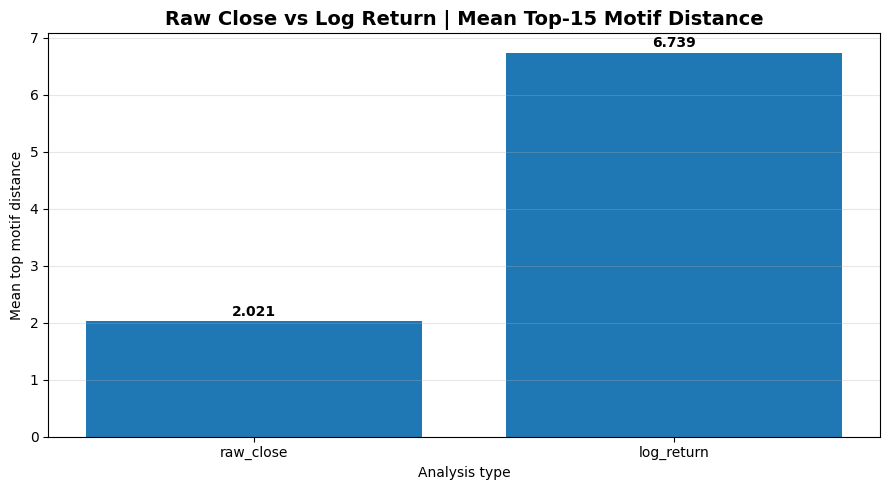

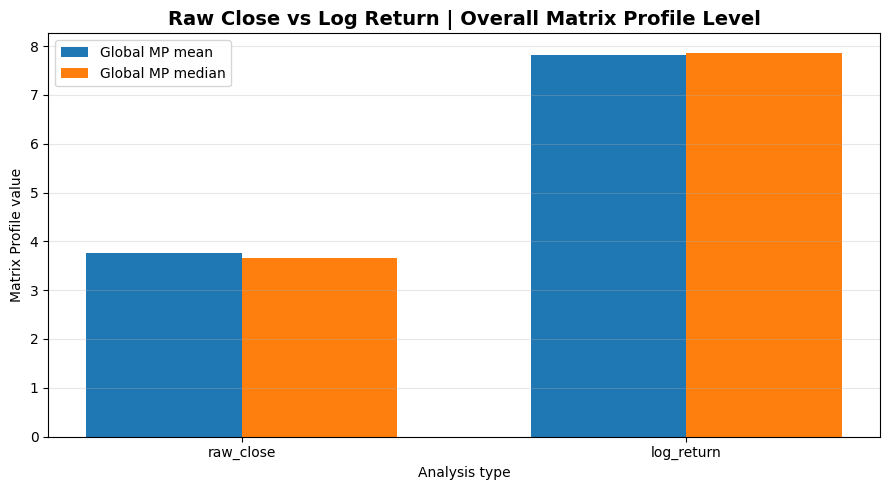

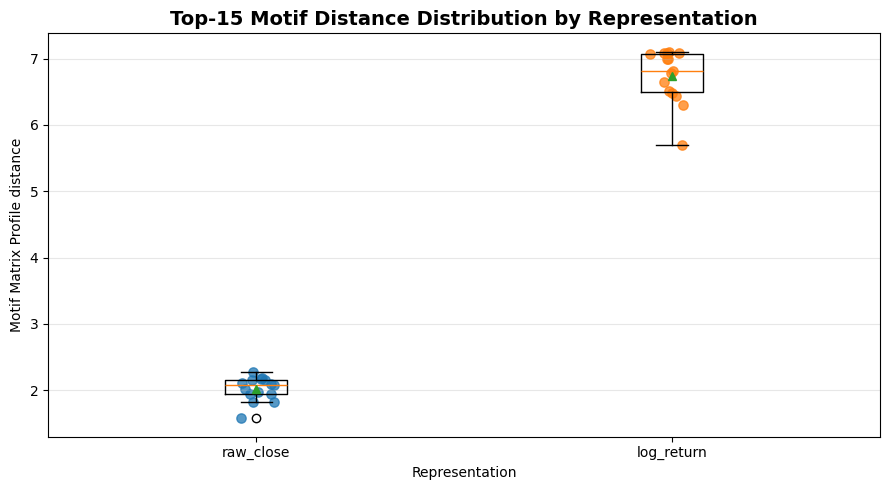

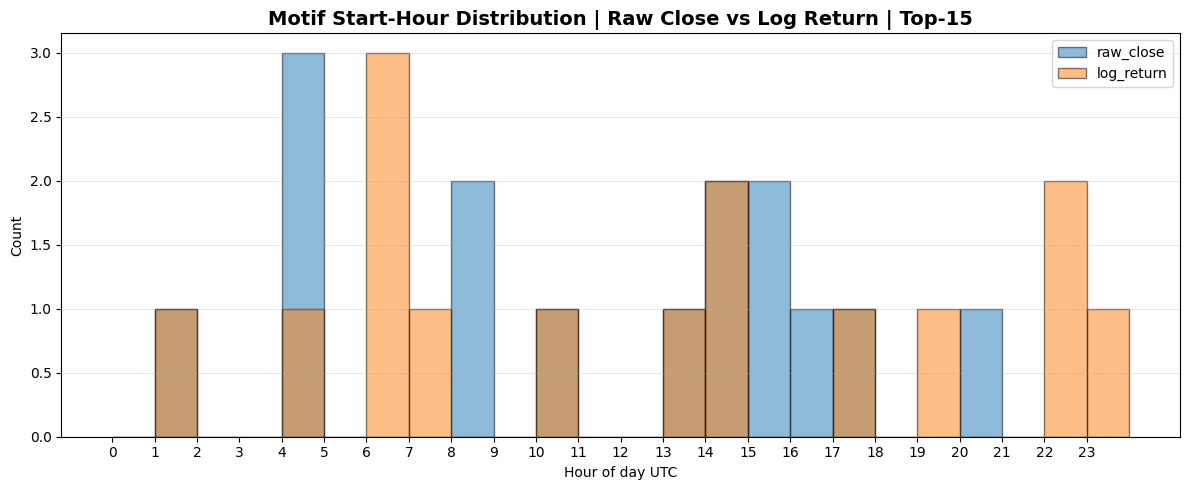

Interpretation:
- Raw close and log_return are not directly comparable by MP value alone because their data distributions differ.
- Raw close motifs often capture local price-shape similarity.
- Log-return motifs capture local movement/return behavior rather than price level.
- The timing plots help check whether different representations discover motifs in similar or different market periods.


In [26]:
# ============================================================
# CELL 25: RAW CLOSE VS LOG-RETURN COMPARISON VISUALIZATIONS
# ============================================================

if comparison_summary_df.empty:
    print("No comparison summary available.")
else:
    # --------------------------------------------------------
    # Fix metadata labels inside comparison_motifs
    # --------------------------------------------------------

    for comparison_name, comparison_col in COMPARISON_FEATURES.items():
        if comparison_name in comparison_motifs:
            comparison_motifs[comparison_name]["analysis_type"] = comparison_name
            comparison_motifs[comparison_name]["target_column"] = comparison_col

    # --------------------------------------------------------
    # 1. Summary bar chart: top motif mean distance
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(
        comparison_summary_df["analysis_name"],
        comparison_summary_df["top_motif_mean_distance"]
    )

    ax.set_title(
        f"Raw Close vs Log Return | Mean Top-{COMPARISON_TOP_K} Motif Distance",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Analysis type")
    ax.set_ylabel("Mean top motif distance")
    ax.grid(True, axis="y", alpha=0.3)

    for i, row in comparison_summary_df.iterrows():
        ax.text(
            i,
            row["top_motif_mean_distance"] + 0.05,
            f"{row['top_motif_mean_distance']:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 2. Global Matrix Profile comparison
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(9, 5))

    x = np.arange(len(comparison_summary_df))
    width = 0.35

    ax.bar(
        x - width / 2,
        comparison_summary_df["global_mp_mean"],
        width,
        label="Global MP mean"
    )

    ax.bar(
        x + width / 2,
        comparison_summary_df["global_mp_median"],
        width,
        label="Global MP median"
    )

    ax.set_title(
        "Raw Close vs Log Return | Overall Matrix Profile Level",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Analysis type")
    ax.set_ylabel("Matrix Profile value")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_summary_df["analysis_name"])
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 3. Boxplot of top motif distances by representation
    # --------------------------------------------------------

    box_data = []
    box_labels = []

    for comparison_name, motifs_table in comparison_motifs.items():
        if motifs_table is not None and not motifs_table.empty:
            box_data.append(motifs_table["profile_value"].dropna().to_numpy())
            box_labels.append(comparison_name)

    if len(box_data) > 0:
        fig, ax = plt.subplots(figsize=(9, 5))

        ax.boxplot(
            box_data,
            labels=box_labels,
            showmeans=True
        )

        for i, values in enumerate(box_data, start=1):
            x_jitter = np.random.normal(loc=i, scale=0.025, size=len(values))
            ax.scatter(
                x_jitter,
                values,
                alpha=0.75,
                s=45
            )

        ax.set_title(
            f"Top-{COMPARISON_TOP_K} Motif Distance Distribution by Representation",
            fontsize=14,
            fontweight="bold"
        )
        ax.set_xlabel("Representation")
        ax.set_ylabel("Motif Matrix Profile distance")
        ax.grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 4. Timing comparison: motif start hours
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(12, 5))

    hour_bins = np.arange(0, 25)

    for comparison_name, motifs_table in comparison_motifs.items():
        if motifs_table is None or motifs_table.empty:
            continue

        temp = motifs_table.copy()
        temp["motif_start"] = pd.to_datetime(temp["motif_start"], utc=True)
        temp["motif_hour"] = temp["motif_start"].dt.hour

        ax.hist(
            temp["motif_hour"],
            bins=hour_bins,
            alpha=0.5,
            label=comparison_name,
            edgecolor="black"
        )

    ax.set_title(
        f"Motif Start-Hour Distribution | Raw Close vs Log Return | Top-{COMPARISON_TOP_K}",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Hour of day UTC")
    ax.set_ylabel("Count")
    ax.set_xticks(np.arange(0, 24, 1))
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print("Interpretation:")
    print("- Raw close and log_return are not directly comparable by MP value alone because their data distributions differ.")
    print("- Raw close motifs often capture local price-shape similarity.")
    print("- Log-return motifs capture local movement/return behavior rather than price level.")
    print("- The timing plots help check whether different representations discover motifs in similar or different market periods.")

## Motif Overlap Between Raw Close and Log Return

Since raw close and log-return distances are not directly comparable, I compare the motif timestamps instead.

The question is:

> Do raw-close motifs and log-return motifs appear around the same market times?

To answer this, I treat both motif starts and nearest-neighbor starts as motif events. Then I check how many events overlap within different tolerance windows.

The tolerance windows are:

| Tolerance | Meaning |
|---:|---|
| 15 minutes | Very strict overlap |
| 30 minutes | Strict overlap |
| 60 minutes | Same local market hour |
| 180 minutes | Same broad intraday region |
| 360 minutes | Same half-day region |

This analysis is more meaningful than directly comparing Matrix Profile values across different feature spaces.

Raw close vs log-return motif overlap summary:


,tolerance_minutes,raw_events_total,log_return_events_total,raw_events_matched,log_return_events_matched,raw_match_rate_pct,log_return_match_rate_pct
0,15,30,30,3,3,10.000000,10.000000
1,30,30,30,4,4,13.333333,13.333333
2,60,30,30,7,7,23.333333,23.333333
3,180,30,30,23,18,76.666667,60.000000
4,360,30,30,30,18,100.000000,60.000000



Closest matched event pairs:


,tolerance_minutes,raw_rank,raw_event_type,raw_time,log_return_rank,log_return_event_type,log_return_time,absolute_time_gap_minutes
2,15,13,motif,2025-01-03 13:33:00+00:00,4,neighbor,2025-01-03 13:37:00+00:00,4.0
0,15,1,neighbor,2025-01-05 07:15:00+00:00,2,motif,2025-01-05 07:04:00+00:00,11.0
1,15,4,neighbor,2025-01-05 19:30:00+00:00,5,neighbor,2025-01-05 19:19:00+00:00,11.0
6,30,13,motif,2025-01-03 13:33:00+00:00,4,neighbor,2025-01-03 13:37:00+00:00,4.0
3,30,1,neighbor,2025-01-05 07:15:00+00:00,2,motif,2025-01-05 07:04:00+00:00,11.0
5,30,4,neighbor,2025-01-05 19:30:00+00:00,5,neighbor,2025-01-05 19:19:00+00:00,11.0
4,30,3,motif,2025-01-02 04:01:00+00:00,8,motif,2025-01-02 04:17:00+00:00,16.0
13,60,13,motif,2025-01-03 13:33:00+00:00,4,neighbor,2025-01-03 13:37:00+00:00,4.0
7,60,1,neighbor,2025-01-05 07:15:00+00:00,2,motif,2025-01-05 07:04:00+00:00,11.0
10,60,4,neighbor,2025-01-05 19:30:00+00:00,5,neighbor,2025-01-05 19:19:00+00:00,11.0


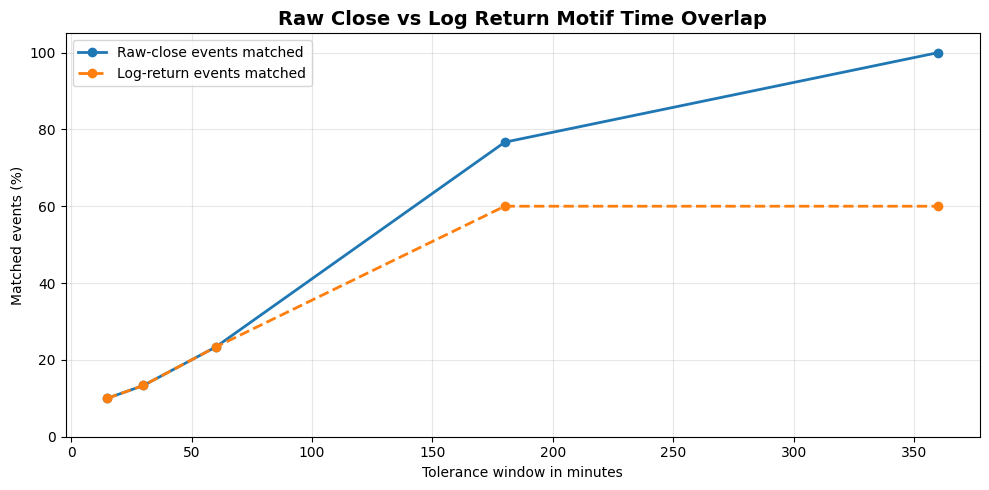

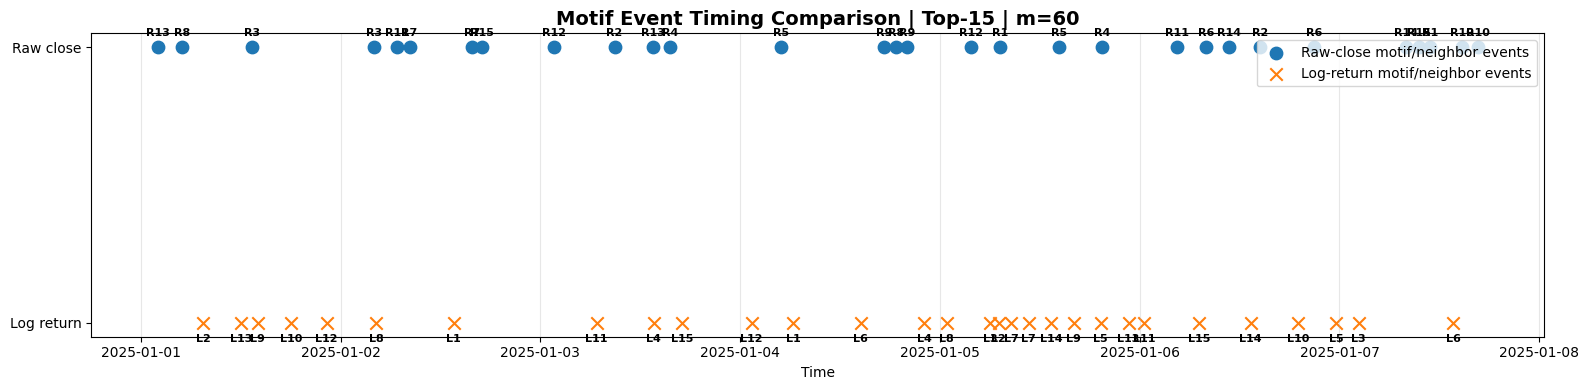

Interpretation:
- This comparison uses motif timestamps, not MP distances.
- High overlap means raw close and log-return detect patterns around similar market times.
- Low overlap means the two representations detect different types of market structure.
- This is more meaningful than directly comparing raw MP values across different feature spaces.


In [27]:
# ============================================================
# CELL 26: RAW CLOSE VS LOG-RETURN MOTIF OVERLAP ANALYSIS
# ============================================================

if "comparison_motifs" not in globals() or len(comparison_motifs) < 2:
    print("Need at least two motif sets in comparison_motifs.")
else:
    raw_motifs = comparison_motifs.get("raw_close", pd.DataFrame()).copy()
    ret_motifs = comparison_motifs.get("log_return", pd.DataFrame()).copy()

    if raw_motifs.empty or ret_motifs.empty:
        print("Raw-close or log-return motif table is empty.")
    else:
        # ----------------------------------------------------
        # Clean timestamps
        # ----------------------------------------------------

        for table in [raw_motifs, ret_motifs]:
            table["motif_start"] = pd.to_datetime(table["motif_start"], utc=True)
            table["neighbor_start"] = pd.to_datetime(table["neighbor_start"], utc=True)

        # ----------------------------------------------------
        # Build event tables: motif and neighbor starts
        # ----------------------------------------------------

        raw_events = []
        ret_events = []

        for _, row in raw_motifs.iterrows():
            raw_events.append({
                "analysis": "raw_close",
                "rank": int(row["rank"]),
                "event_type": "motif",
                "event_time": row["motif_start"],
                "profile_value": float(row["profile_value"]),
            })
            raw_events.append({
                "analysis": "raw_close",
                "rank": int(row["rank"]),
                "event_type": "neighbor",
                "event_time": row["neighbor_start"],
                "profile_value": float(row["profile_value"]),
            })

        for _, row in ret_motifs.iterrows():
            ret_events.append({
                "analysis": "log_return",
                "rank": int(row["rank"]),
                "event_type": "motif",
                "event_time": row["motif_start"],
                "profile_value": float(row["profile_value"]),
            })
            ret_events.append({
                "analysis": "log_return",
                "rank": int(row["rank"]),
                "event_type": "neighbor",
                "event_time": row["neighbor_start"],
                "profile_value": float(row["profile_value"]),
            })

        raw_events_df = pd.DataFrame(raw_events)
        ret_events_df = pd.DataFrame(ret_events)

        # ----------------------------------------------------
        # Match events by time tolerance
        # ----------------------------------------------------

        TOLERANCES_MINUTES = [15, 30, 60, 180, 360]

        overlap_records = []
        matched_pairs_records = []

        for tol_min in TOLERANCES_MINUTES:
            tolerance = pd.Timedelta(minutes=tol_min)

            matched_raw_indices = set()
            matched_ret_indices = set()

            for raw_idx, raw_row in raw_events_df.iterrows():
                time_diffs = (ret_events_df["event_time"] - raw_row["event_time"]).abs()
                within_tol = time_diffs <= tolerance

                if within_tol.any():
                    nearest_idx = time_diffs.idxmin()

                    matched_raw_indices.add(raw_idx)
                    matched_ret_indices.add(nearest_idx)

                    matched_pairs_records.append({
                        "tolerance_minutes": tol_min,
                        "raw_rank": raw_row["rank"],
                        "raw_event_type": raw_row["event_type"],
                        "raw_time": raw_row["event_time"],
                        "log_return_rank": int(ret_events_df.loc[nearest_idx, "rank"]),
                        "log_return_event_type": ret_events_df.loc[nearest_idx, "event_type"],
                        "log_return_time": ret_events_df.loc[nearest_idx, "event_time"],
                        "absolute_time_gap_minutes": time_diffs.loc[nearest_idx].total_seconds() / 60,
                    })

            overlap_records.append({
                "tolerance_minutes": tol_min,
                "raw_events_total": int(len(raw_events_df)),
                "log_return_events_total": int(len(ret_events_df)),
                "raw_events_matched": int(len(matched_raw_indices)),
                "log_return_events_matched": int(len(matched_ret_indices)),
                "raw_match_rate_pct": 100 * len(matched_raw_indices) / len(raw_events_df),
                "log_return_match_rate_pct": 100 * len(matched_ret_indices) / len(ret_events_df),
            })

        overlap_summary_df = pd.DataFrame(overlap_records)
        matched_pairs_df = pd.DataFrame(matched_pairs_records)

        print("Raw close vs log-return motif overlap summary:")
        display(overlap_summary_df)

        print("\nClosest matched event pairs:")
        display(
            matched_pairs_df.sort_values(
                ["tolerance_minutes", "absolute_time_gap_minutes"]
            ).head(20)
        )

        # ----------------------------------------------------
        # Visualization 1: overlap rate by tolerance
        # ----------------------------------------------------

        fig, ax = plt.subplots(figsize=(10, 5))

        ax.plot(
            overlap_summary_df["tolerance_minutes"],
            overlap_summary_df["raw_match_rate_pct"],
            marker="o",
            linewidth=2,
            label="Raw-close events matched"
        )

        ax.plot(
            overlap_summary_df["tolerance_minutes"],
            overlap_summary_df["log_return_match_rate_pct"],
            marker="o",
            linewidth=2,
            linestyle="--",
            label="Log-return events matched"
        )

        ax.set_title(
            "Raw Close vs Log Return Motif Time Overlap",
            fontsize=14,
            fontweight="bold"
        )
        ax.set_xlabel("Tolerance window in minutes")
        ax.set_ylabel("Matched events (%)")
        ax.set_ylim(0, 105)
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

        # ----------------------------------------------------
        # Visualization 2: event strip comparison
        # ----------------------------------------------------

        fig, ax = plt.subplots(figsize=(16, 4))

        raw_y = 1
        ret_y = 0

        ax.scatter(
            raw_events_df["event_time"],
            [raw_y] * len(raw_events_df),
            s=80,
            marker="o",
            label="Raw-close motif/neighbor events"
        )

        ax.scatter(
            ret_events_df["event_time"],
            [ret_y] * len(ret_events_df),
            s=80,
            marker="x",
            label="Log-return motif/neighbor events"
        )

        for _, row in raw_events_df.iterrows():
            ax.annotate(
                f"R{row['rank']}",
                (row["event_time"], raw_y),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
                fontweight="bold"
            )

        for _, row in ret_events_df.iterrows():
            ax.annotate(
                f"L{row['rank']}",
                (row["event_time"], ret_y),
                textcoords="offset points",
                xytext=(0, -14),
                ha="center",
                fontsize=8,
                fontweight="bold"
            )

        ax.set_yticks([ret_y, raw_y])
        ax.set_yticklabels(["Log return", "Raw close"])

        ax.set_title(
            f"Motif Event Timing Comparison | Top-{COMPARISON_TOP_K} | m={m}",
            fontsize=14,
            fontweight="bold"
        )
        ax.set_xlabel("Time")
        ax.grid(True, axis="x", alpha=0.3)
        ax.legend(loc="upper right")

        plt.tight_layout()
        plt.show()

        print("Interpretation:")
        print("- This comparison uses motif timestamps, not MP distances.")
        print("- High overlap means raw close and log-return detect patterns around similar market times.")
        print("- Low overlap means the two representations detect different types of market structure.")
        print("- This is more meaningful than directly comparing raw MP values across different feature spaces.")

## Raw Close vs Log-Return Overlap Findings

The overlap analysis shows that raw-close and log-return motifs only partially agree in time.

| Tolerance | Raw-close match rate | Log-return match rate |
|---:|---:|---:|
| 15 minutes | 10.00% | 10.00% |
| 30 minutes | 13.33% | 13.33% |
| 60 minutes | 23.33% | 23.33% |
| 180 minutes | 76.67% | 60.00% |
| 360 minutes | 100.00% | 60.00% |

The strict overlap rates are low. This means raw-close and log-return motifs often detect different structures.

However, the broader overlap rates increase substantially, especially at 180 minutes. This suggests that the two representations may identify related market regions, but not necessarily the exact same minute-level windows.

Some close matches are very informative:

| Raw event time | Log-return event time | Gap |
|---|---|---:|
| 2025-01-03 13:33 | 2025-01-03 13:37 | 4 minutes |
| 2025-01-05 07:15 | 2025-01-05 07:04 | 11 minutes |
| 2025-01-05 19:30 | 2025-01-05 19:19 | 11 minutes |

This suggests that representation choice matters. Raw close and log-return may sometimes detect the same market episode, but they are not equivalent.

## Lightweight Multivariate Feature Setup

The next step is to move from univariate motifs to a small multivariate representation.

For this prototype, I deliberately keep the feature set small:

| Feature | Reason |
|---|---|
| `log_return` | Captures local directional movement |
| `volatility_60m` | Captures local risk intensity |

This is enough for a clean first multivariate experiment.

The goal is not to add many features immediately. Too many features would make the notebook harder to interpret. A small two-channel setup is better for understanding whether multivariate motif discovery changes the detected patterns.

Before running multivariate Matrix Profile, both features are standardized so that one feature does not dominate simply because of scale.

Requested multivariate features: ['log_return', 'volatility_60m']
Available multivariate features: ['log_return', 'volatility_60m']

Multivariate dataframe created.
Shape: (10080, 5)
Start: 2025-01-01 00:00:00+00:00
End:   2025-01-07 23:59:00+00:00

Multivariate matrix prepared.
multi_X shape: (2, 10080)
Shape meaning: (number of features, number of time points)


,feature,mean_before_standardization,std_before_standardization,used_in_multivariate_matrix
0,log_return,0.000004,0.000503,True
1,volatility_60m,0.000442,0.000239,True


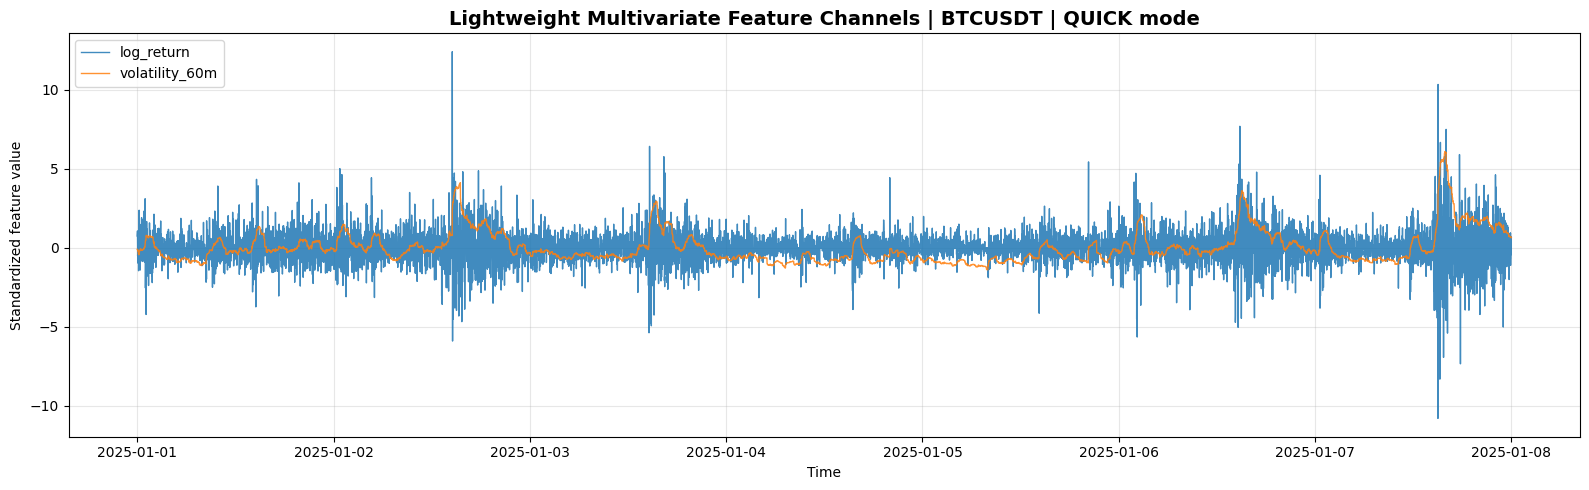

Interpretation:
- This prepares a small multivariate representation using log returns and volatility.
- log_return captures local directional movement.
- volatility_60m captures local risk intensity.
- The features are standardized so that one channel does not dominate only because of scale.


In [29]:
# ============================================================
# CELL 27: LIGHTWEIGHT MULTIVARIATE FEATURE SETUP
# ============================================================

# For prototype, keep multivariate analysis small and interpretable.
# We start with only 2 features:
# 1. log_return
# 2. volatility_60m

MULTIVARIATE_FEATURES = [
    "log_return",
    "volatility_60m",
]

# ------------------------------------------------------------
# Validate available features
# ------------------------------------------------------------

available_multivariate_features = [
    col for col in MULTIVARIATE_FEATURES
    if col in df.columns
]

missing_multivariate_features = [
    col for col in MULTIVARIATE_FEATURES
    if col not in df.columns
]

print("Requested multivariate features:", MULTIVARIATE_FEATURES)
print("Available multivariate features:", available_multivariate_features)

if missing_multivariate_features:
    print("Missing features:", missing_multivariate_features)

if len(available_multivariate_features) < 2:
    raise ValueError(
        "Need at least 2 available features for lightweight multivariate analysis."
    )

# ------------------------------------------------------------
# Build multivariate dataframe using the same time slice
# ------------------------------------------------------------

multi_cols = ["timestamp", "close", "volume"] + available_multivariate_features
multi_df = df[multi_cols].copy()

multi_df = multi_df.replace([np.inf, -np.inf], np.nan)
multi_df = multi_df.dropna(subset=available_multivariate_features)
multi_df = multi_df.reset_index(drop=True)

print("\nMultivariate dataframe created.")
print(f"Shape: {multi_df.shape}")
print(f"Start: {multi_df['timestamp'].min()}")
print(f"End:   {multi_df['timestamp'].max()}")

# ------------------------------------------------------------
# Standardize each feature for fair comparison
# ------------------------------------------------------------

multi_feature_matrix_raw = multi_df[available_multivariate_features].astype(float).to_numpy()

multi_feature_means = multi_feature_matrix_raw.mean(axis=0)
multi_feature_stds = multi_feature_matrix_raw.std(axis=0)

# Avoid division by zero
multi_feature_stds = np.where(multi_feature_stds == 0, 1, multi_feature_stds)

multi_feature_matrix_z = (
    multi_feature_matrix_raw - multi_feature_means
) / multi_feature_stds

# STUMPY mstump expects shape: (dimensions, time)
multi_X = multi_feature_matrix_z.T

multi_timestamps = multi_df["timestamp"].reset_index(drop=True)

print("\nMultivariate matrix prepared.")
print(f"multi_X shape: {multi_X.shape}")
print("Shape meaning: (number of features, number of time points)")

# ------------------------------------------------------------
# Feature summary table
# ------------------------------------------------------------

multi_feature_summary_df = pd.DataFrame({
    "feature": available_multivariate_features,
    "mean_before_standardization": multi_feature_means,
    "std_before_standardization": multi_feature_stds,
    "used_in_multivariate_matrix": True,
})

display(multi_feature_summary_df)

# ------------------------------------------------------------
# Visualize standardized feature channels
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 5))

for i, feature in enumerate(available_multivariate_features):
    ax.plot(
        multi_timestamps,
        multi_feature_matrix_z[:, i],
        linewidth=1.0,
        alpha=0.85,
        label=feature
    )

ax.set_title(
    f"Lightweight Multivariate Feature Channels | {ASSET} | {RUN_MODE.upper()} mode",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("Standardized feature value")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- This prepares a small multivariate representation using log returns and volatility.")
print("- log_return captures local directional movement.")
print("- volatility_60m captures local risk intensity.")
print("- The features are standardized so that one channel does not dominate only because of scale.")

## Multivariate Feature Setup Findings

The lightweight multivariate feature matrix was created successfully using:

- `log_return`
- `volatility_60m`

The final matrix shape is:

```text
(number of features, number of time points) = (2, 10080)

In [30]:
# ============================================================
# CELL 28: LIGHTWEIGHT MSTUMP MULTIVARIATE MOTIF DISCOVERY
# ============================================================

RUN_LIGHTWEIGHT_MSTUMP = True
MULTIVARIATE_TOP_K = 15

if not RUN_LIGHTWEIGHT_MSTUMP:
    print("Skipping lightweight MSTUMP. Set RUN_LIGHTWEIGHT_MSTUMP = True to run.")
else:
    if multi_X.shape[1] <= m:
        raise ValueError(
            f"Multivariate series length {multi_X.shape[1]} is too small for m={m}."
        )

    print("Running lightweight multivariate Matrix Profile using STUMPY MSTUMP...")
    print(f"Features: {available_multivariate_features}")
    print(f"Input shape: {multi_X.shape}")
    print(f"Window size: m={m}")
    print(f"Top K: {MULTIVARIATE_TOP_K}")

    # --------------------------------------------------------
    # Cache path for lightweight multivariate run
    # --------------------------------------------------------

    multi_feature_name = "_".join(available_multivariate_features)

    multi_cache_path = make_mp_cache_path(
        asset=ASSET,
        analysis_type="multivariate",
        target_column=multi_feature_name,
        window_minutes=m,
        run_mode=RUN_MODE,
        start_date=START_DATE,
        end_date=END_DATE,
    )

    multi_cached = None if FORCE_RECOMPUTE else load_mp_cache(multi_cache_path)

    if multi_cached is not None:
        multi_mp = multi_cached["mp"]
        multi_mpi = multi_cached["mpi"]
        multi_cache_used = True
        multi_elapsed = 0.0
    else:
        print("Computing MSTUMP...")
        t0 = time.time()

        multi_mp_raw, multi_mpi_raw = stumpy.mstump(multi_X, m=m)

        multi_elapsed = time.time() - t0

        # mstump returns profile per dimension.
        # Last row is the full-dimensional profile after considering all channels.
        multi_mp = multi_mp_raw[-1].astype(float)
        multi_mpi = multi_mpi_raw[-1].astype(int)

        save_mp_cache(
            multi_cache_path,
            mp=multi_mp,
            mpi=multi_mpi,
            series=multi_X,
            timestamps=multi_timestamps.astype(str).to_numpy(),
            m=np.array([m]),
            asset=np.array([ASSET]),
            analysis_type=np.array(["multivariate"]),
            target_column=np.array([multi_feature_name]),
            run_mode=np.array([RUN_MODE]),
            start_date=np.array([str(START_DATE)]),
            end_date=np.array([str(END_DATE)]),
            features=np.array(available_multivariate_features),
        )

        multi_cache_used = False

    # --------------------------------------------------------
    # Extract multivariate motifs
    # --------------------------------------------------------

    multi_motifs_df = extract_top_k_motifs(
        mp=multi_mp,
        mpi=multi_mpi,
        timestamps=multi_timestamps,
        m=m,
        top_k=MULTIVARIATE_TOP_K,
    )

    multi_motifs_df["analysis_type"] = "multivariate"
    multi_motifs_df["target_column"] = multi_feature_name

    finite_multi_mp = multi_mp[np.isfinite(multi_mp)]

    multivariate_summary = {
        "analysis_type": "multivariate",
        "features": available_multivariate_features,
        "window_minutes": int(m),
        "top_k": int(MULTIVARIATE_TOP_K),
        "rows_used": int(multi_X.shape[1]),
        "cache_used": bool(multi_cache_used),
        "elapsed_seconds": float(multi_elapsed),
        "global_mp_min": float(np.min(finite_multi_mp)),
        "global_mp_mean": float(np.mean(finite_multi_mp)),
        "global_mp_median": float(np.median(finite_multi_mp)),
        "top_motif_min_distance": float(multi_motifs_df["profile_value"].min()),
        "top_motif_mean_distance": float(multi_motifs_df["profile_value"].mean()),
        "top_motif_median_distance": float(multi_motifs_df["profile_value"].median()),
    }

    print("\nLightweight multivariate summary:")
    print(json.dumps(multivariate_summary, indent=2))

    print("\nTop multivariate motifs:")
    display(multi_motifs_df[[
        "rank",
        "motif_start",
        "motif_end",
        "neighbor_start",
        "neighbor_end",
        "profile_value",
        "window_minutes",
        "target_column",
        "analysis_type",
    ]])

Running lightweight multivariate Matrix Profile using STUMPY MSTUMP...
Features: ['log_return', 'volatility_60m']
Input shape: (2, 10080)
Window size: m=60
Top K: 15
No cache found. Matrix Profile will be computed.
Computing MSTUMP...
Saved Matrix Profile cache:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\matrix_profiles\BTCUSDT_multivariate_log_return_volatility_60m_m60_quick_2025-01-01_to_2025-01-08.npz

Lightweight multivariate summary:
{
  "analysis_type": "multivariate",
  "features": [
    "log_return",
    "volatility_60m"
  ],
  "window_minutes": 60,
  "top_k": 15,
  "rows_used": 10080,
  "cache_used": false,
  "elapsed_seconds": 8.90631628036499,
  "global_mp_min": 4.28215833311586,
  "global_mp_mean": 5.986036962551967,
  "global_mp_median": 5.87865141796596,
  "top_motif_min_distance": 4.28215833311586,
  "top_motif_mean_distance": 4.7475214066565945,
  "top_motif_median_distance": 4.796014984054693
}

Top multivariate motifs:


,rank,motif_start,motif_end,neighbor_start,neighbor_end,profile_value,window_minutes,target_column,analysis_type
0,1,2025-01-05 07:49:00+00:00,2025-01-05 08:48:00+00:00,2025-01-04 15:14:00+00:00,2025-01-04 16:13:00+00:00,4.282158,60,log_return_volatility_60m,multivariate
1,2,2025-01-02 14:22:00+00:00,2025-01-02 15:21:00+00:00,2025-01-04 07:07:00+00:00,2025-01-04 08:06:00+00:00,4.315556,60,log_return_volatility_60m,multivariate
2,3,2025-01-07 09:49:00+00:00,2025-01-07 10:48:00+00:00,2025-01-05 13:54:00+00:00,2025-01-05 14:53:00+00:00,4.476181,60,log_return_volatility_60m,multivariate
3,4,2025-01-07 13:48:00+00:00,2025-01-07 14:47:00+00:00,2025-01-03 12:27:00+00:00,2025-01-03 13:26:00+00:00,4.649038,60,log_return_volatility_60m,multivariate
4,5,2025-01-05 19:35:00+00:00,2025-01-05 20:34:00+00:00,2025-01-04 19:17:00+00:00,2025-01-04 20:16:00+00:00,4.676791,60,log_return_volatility_60m,multivariate
5,6,2025-01-07 10:50:00+00:00,2025-01-07 11:49:00+00:00,2025-01-06 13:28:00+00:00,2025-01-06 14:27:00+00:00,4.775558,60,log_return_volatility_60m,multivariate
6,7,2025-01-05 04:45:00+00:00,2025-01-05 05:44:00+00:00,2025-01-04 16:51:00+00:00,2025-01-04 17:50:00+00:00,4.778973,60,log_return_volatility_60m,multivariate
7,8,2025-01-02 04:11:00+00:00,2025-01-02 05:10:00+00:00,2025-01-01 19:16:00+00:00,2025-01-01 20:15:00+00:00,4.796015,60,log_return_volatility_60m,multivariate
8,9,2025-01-07 01:06:00+00:00,2025-01-07 02:05:00+00:00,2025-01-02 21:01:00+00:00,2025-01-02 22:00:00+00:00,4.843357,60,log_return_volatility_60m,multivariate
9,10,2025-01-03 15:24:00+00:00,2025-01-03 16:23:00+00:00,2025-01-02 05:25:00+00:00,2025-01-02 06:24:00+00:00,4.904696,60,log_return_volatility_60m,multivariate



 
 
## Multivariate Motif Findings

The lightweight multivariate MSTUMP run completed successfully.

The experiment used:

| Setting | Value |
|---|---|
| Features | `log_return`, `volatility_60m` |
| Window size | 60 minutes |
| Rows used | 10,080 |
| Top motifs | 15 |
| Runtime | about 8.91 seconds |
| Mean top 15 motif distance | 4.748 |
| Best motif distance | 4.282 |

The multivariate motifs are different from both raw-close motifs and pure log-return motifs.

This is expected because the multivariate method searches for repeated joint behavior across return and volatility channels.

This is an important prototype result because it shows that the notebook can support raw, univariate, and multivariate motif discovery within the same framework.

## Raw vs Univariate vs Multivariate Comparison

At this point, I compare three motif-discovery representations:

| Representation | Input | Meaning |
|---|---|---|
| Raw close | `close` | Repeated price-level shape |
| Univariate | `log_return` | Repeated return behavior |
| Multivariate | `log_return + volatility_60m` | Repeated return-volatility behavior |

This comparison is central to the thesis prototype.

The goal is to understand whether changing the representation changes:

- motif distances
- motif ranking behavior
- motif timing
- motif interpretability

Again, Matrix Profile distances should not be compared blindly across representations. The stronger comparison is based on stability, timing overlap, and financial meaning.

Representation comparison summary:


,representation,target,features,rows_used,window_minutes,top_k,global_mp_mean,global_mp_median,top_motif_min_distance,top_motif_mean_distance,top_motif_median_distance
0,raw_close,close,close,10080,60,15,3.760645,3.650943,1.576078,2.021175,2.081173
1,log_return,log_return,log_return,10080,60,15,7.816817,7.868744,5.700572,6.739009,6.813526
2,multivariate,log_return + volatility_60m,log_return + volatility_60m,10080,60,15,5.986037,5.878651,4.282158,4.747521,4.796015


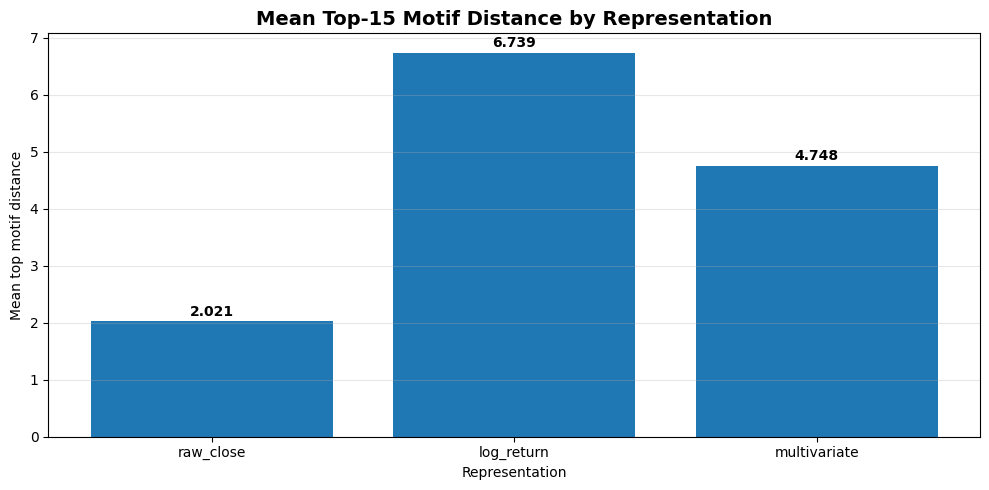

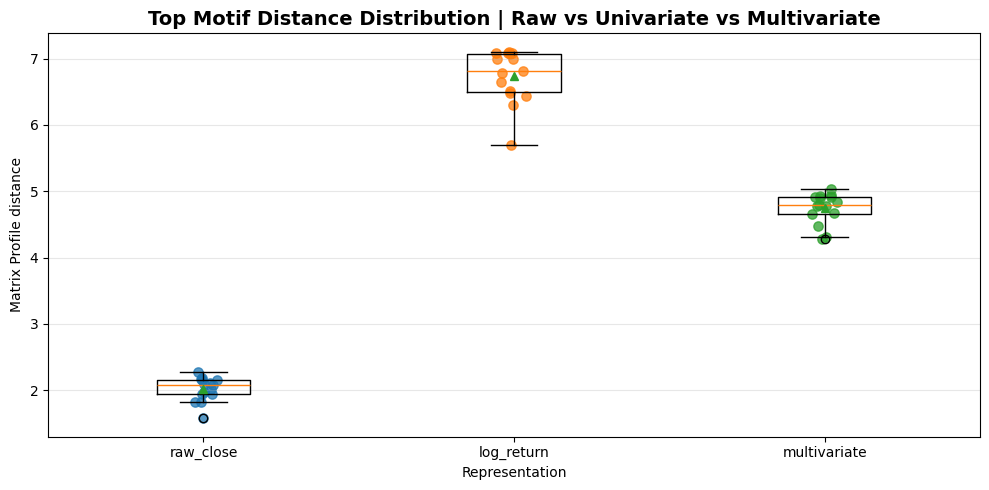

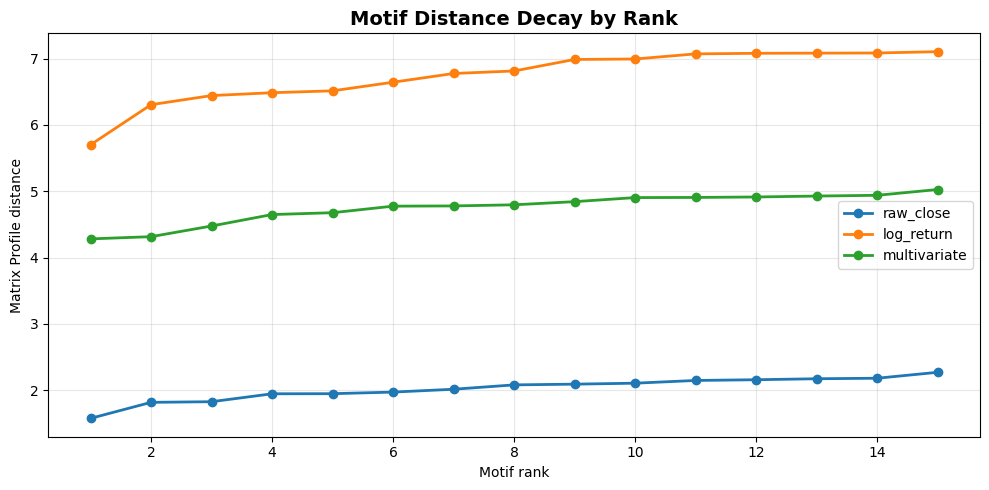

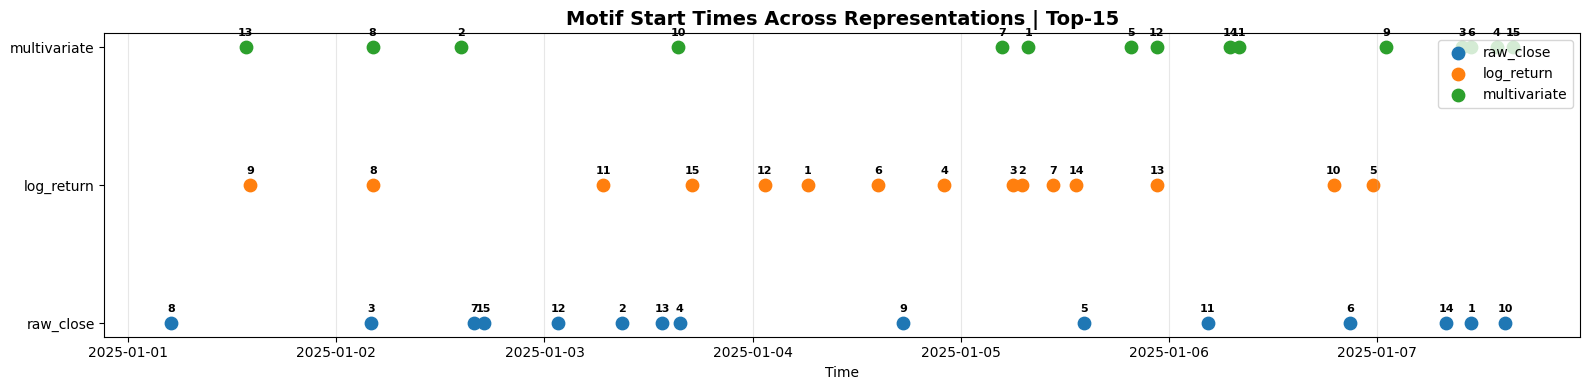

Interpretation:
- These representations should not be judged only by raw MP value because they live in different feature spaces.
- Raw close captures repeated price-level shapes.
- Log-return captures repeated local return behavior.
- Multivariate motifs capture joint return-volatility behavior.
- The strongest comparison is whether motif timings overlap and whether discovered motifs are interpretable.


In [31]:
# ============================================================
# CELL 29: RAW VS LOG-RETURN VS MULTIVARIATE COMPARISON
# ============================================================

# ------------------------------------------------------------
# Build combined summary table
# ------------------------------------------------------------

summary_rows = []

# Raw + log_return summaries from Cell 24
if "comparison_summary_df" in globals() and not comparison_summary_df.empty:
    for _, row in comparison_summary_df.iterrows():
        summary_rows.append({
            "representation": row["analysis_name"],
            "target": row["target_column"],
            "features": row["target_column"],
            "rows_used": row["rows_used"],
            "window_minutes": row["window_minutes"],
            "top_k": row["top_k_extracted"],
            "global_mp_mean": row["global_mp_mean"],
            "global_mp_median": row["global_mp_median"],
            "top_motif_min_distance": row["top_motif_min_distance"],
            "top_motif_mean_distance": row["top_motif_mean_distance"],
            "top_motif_median_distance": row["top_motif_median_distance"],
        })

# Multivariate summary from Cell 28
if "multivariate_summary" in globals():
    summary_rows.append({
        "representation": "multivariate",
        "target": " + ".join(multivariate_summary["features"]),
        "features": " + ".join(multivariate_summary["features"]),
        "rows_used": multivariate_summary["rows_used"],
        "window_minutes": multivariate_summary["window_minutes"],
        "top_k": multivariate_summary["top_k"],
        "global_mp_mean": multivariate_summary["global_mp_mean"],
        "global_mp_median": multivariate_summary["global_mp_median"],
        "top_motif_min_distance": multivariate_summary["top_motif_min_distance"],
        "top_motif_mean_distance": multivariate_summary["top_motif_mean_distance"],
        "top_motif_median_distance": multivariate_summary["top_motif_median_distance"],
    })

representation_summary_df = pd.DataFrame(summary_rows)

print("Representation comparison summary:")
display(representation_summary_df)

# ------------------------------------------------------------
# Build combined motif-distance table
# ------------------------------------------------------------

combined_motif_distance_records = []

if "comparison_motifs" in globals():
    for name, table in comparison_motifs.items():
        if table is None or table.empty:
            continue

        temp = table.copy()
        temp["representation"] = name

        for _, row in temp.iterrows():
            combined_motif_distance_records.append({
                "representation": name,
                "rank": int(row["rank"]),
                "profile_value": float(row["profile_value"]),
                "motif_start": row["motif_start"],
                "neighbor_start": row["neighbor_start"],
            })

if "multi_motifs_df" in globals() and not multi_motifs_df.empty:
    for _, row in multi_motifs_df.iterrows():
        combined_motif_distance_records.append({
            "representation": "multivariate",
            "rank": int(row["rank"]),
            "profile_value": float(row["profile_value"]),
            "motif_start": row["motif_start"],
            "neighbor_start": row["neighbor_start"],
        })

combined_motif_distance_df = pd.DataFrame(combined_motif_distance_records)

# ------------------------------------------------------------
# 1. Mean top motif distance by representation
# ------------------------------------------------------------

if not representation_summary_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        representation_summary_df["representation"],
        representation_summary_df["top_motif_mean_distance"]
    )

    ax.set_title(
        f"Mean Top-{COMPARISON_TOP_K} Motif Distance by Representation",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Representation")
    ax.set_ylabel("Mean top motif distance")
    ax.grid(True, axis="y", alpha=0.3)

    for i, row in representation_summary_df.iterrows():
        ax.text(
            i,
            row["top_motif_mean_distance"] + 0.05,
            f"{row['top_motif_mean_distance']:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 2. Boxplot of top motif distances by representation
# ------------------------------------------------------------

if not combined_motif_distance_df.empty:
    reps = combined_motif_distance_df["representation"].unique()

    box_data = []
    box_labels = []

    for rep in reps:
        values = combined_motif_distance_df.loc[
            combined_motif_distance_df["representation"] == rep,
            "profile_value"
        ].dropna().to_numpy()

        box_data.append(values)
        box_labels.append(rep)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.boxplot(
        box_data,
        labels=box_labels,
        showmeans=True
    )

    for i, values in enumerate(box_data, start=1):
        x_jitter = np.random.normal(loc=i, scale=0.025, size=len(values))
        ax.scatter(
            x_jitter,
            values,
            alpha=0.75,
            s=45
        )

    ax.set_title(
        f"Top Motif Distance Distribution | Raw vs Univariate vs Multivariate",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Representation")
    ax.set_ylabel("Matrix Profile distance")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 3. Rank-distance curves
# ------------------------------------------------------------

if not combined_motif_distance_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))

    for rep in combined_motif_distance_df["representation"].unique():
        temp = combined_motif_distance_df[
            combined_motif_distance_df["representation"] == rep
        ].sort_values("rank")

        ax.plot(
            temp["rank"],
            temp["profile_value"],
            marker="o",
            linewidth=2,
            label=rep
        )

    ax.set_title(
        "Motif Distance Decay by Rank",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Motif rank")
    ax.set_ylabel("Matrix Profile distance")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 4. Motif start-time event strip across representations
# ------------------------------------------------------------

if not combined_motif_distance_df.empty:
    event_df = combined_motif_distance_df.copy()
    event_df["motif_start"] = pd.to_datetime(event_df["motif_start"], utc=True)

    rep_order = list(event_df["representation"].unique())
    y_map = {rep: i for i, rep in enumerate(rep_order)}

    fig, ax = plt.subplots(figsize=(16, 4))

    for rep in rep_order:
        temp = event_df[event_df["representation"] == rep]

        ax.scatter(
            temp["motif_start"],
            [y_map[rep]] * len(temp),
            s=80,
            label=rep
        )

        for _, row in temp.iterrows():
            ax.annotate(
                str(int(row["rank"])),
                (row["motif_start"], y_map[rep]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
                fontweight="bold"
            )

    ax.set_yticks(list(y_map.values()))
    ax.set_yticklabels(list(y_map.keys()))

    ax.set_title(
        f"Motif Start Times Across Representations | Top-{COMPARISON_TOP_K}",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Time")
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

print("Interpretation:")
print("- These representations should not be judged only by raw MP value because they live in different feature spaces.")
print("- Raw close captures repeated price-level shapes.")
print("- Log-return captures repeated local return behavior.")
print("- Multivariate motifs capture joint return-volatility behavior.")
print("- The strongest comparison is whether motif timings overlap and whether discovered motifs are interpretable.")

## Representation Comparison Findings

The three representations produced clearly different motif-discovery behavior.

| Representation | Mean top 15 motif distance |
|---|---:|
| Raw close | 2.021 |
| Log return | 6.739 |
| Multivariate | 4.748 |

The raw-close representation has the lowest distance scale, log-return has the highest, and the multivariate representation is between them.

This does not mean raw close is automatically best. The representations have different scales and different meanings.

The more important finding is that motif start times differ across representations. This means the input representation changes what the algorithm considers a repeated market pattern.

Interpretation:

- Raw close detects repeated local price shapes.
- Log return detects repeated local movement behavior.
- Multivariate discovery detects repeated joint return-volatility states.

This supports the thesis direction: motif discovery in finance should be evaluated under multiple representations, not only on raw prices.

## Saving Results and Managing Timeframe Scalability

The final step is to save all important outputs from the notebook.

This is necessary because the notebook is not only a visual demo. It is part of a reproducible research pipeline.

The saved outputs include:

- current top motifs
- top 15 motifs
- motif movement statistics
- consistency scores
- window-size sensitivity results
- raw vs log-return comparison
- raw vs log-return overlap results
- multivariate motif results
- representation comparison results
- run configuration and scalability plan

The key design decision is that every Matrix Profile cache and every result folder is tied to the experiment configuration:

| Key | Purpose |
|---|---|
| Asset | Example: BTCUSDT |
| Analysis type | raw, feature, multivariate |
| Target column or feature set | close, log_return, log_return + volatility |
| Window size | 15, 30, 60, 120 minutes |
| Run mode | quick, medium, full |
| Start date | beginning of experiment slice |
| End date | end of experiment slice |

This makes the notebook scalable. To run on a larger timeframe, I do not need to rewrite the notebook. I only need to change the configuration.

In [32]:
# ============================================================
# CELL 30: SAVE RESULTS AND TIMEFRAME SCALABILITY PLAN
# ============================================================

# ------------------------------------------------------------
# Create output directory for this exact run
# ------------------------------------------------------------

run_tag = (
    f"{ASSET}_"
    f"{RUN_MODE}_"
    f"{ANALYSIS_TYPE}_"
    f"{TARGET_COLUMN}_"
    f"m{m}_"
    f"{safe_name(START_DATE)}_to_{safe_name(END_DATE)}"
)

RUN_OUTPUT_DIR = RESULTS_DIR / run_tag
RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving notebook outputs to:")
print(RUN_OUTPUT_DIR)

# ------------------------------------------------------------
# Save key tables
# ------------------------------------------------------------

saved_files = []

def save_table_if_exists(obj_name, filename):
    if obj_name in globals():
        obj = globals()[obj_name]
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            path = RUN_OUTPUT_DIR / filename
            obj.to_csv(path, index=False)
            saved_files.append(path)
            print(f"Saved: {path.name}")

save_table_if_exists("motifs_df", "top_k_motifs_current.csv")
save_table_if_exists("extended_motifs_df", "top_15_motifs.csv")
save_table_if_exists("motif_stats_df", "motif_movement_statistics.csv")
save_table_if_exists("consistency_df", "motif_consistency_scores.csv")
save_table_if_exists("window_study_df", "window_size_sensitivity_summary.csv")
save_table_if_exists("comparison_summary_df", "raw_vs_logreturn_summary.csv")
save_table_if_exists("overlap_summary_df", "raw_vs_logreturn_overlap_summary.csv")
save_table_if_exists("matched_pairs_df", "raw_vs_logreturn_matched_pairs.csv")
save_table_if_exists("multi_motifs_df", "multivariate_top_15_motifs.csv")
save_table_if_exists("representation_summary_df", "representation_comparison_summary.csv")
save_table_if_exists("combined_motif_distance_df", "combined_representation_motif_distances.csv")

# ------------------------------------------------------------
# Save run configuration
# ------------------------------------------------------------

scalability_plan = {
    "current_run": {
        "asset": ASSET,
        "run_mode": RUN_MODE,
        "analysis_type": ANALYSIS_TYPE,
        "target_column": TARGET_COLUMN,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "window_minutes": int(m),
        "top_k_initial": int(TOP_K_MOTIFS),
        "top_k_extended": int(TOP_K_EXTENDED) if "TOP_K_EXTENDED" in globals() else None,
        "rows_used": int(len(analysis_df)) if "analysis_df" in globals() else None,
        "subsequence_count": int(len(series) - m + 1) if "series" in globals() else None,
    },
    "timeframe_scaling_strategy": {
        "quick_mode": "Use 7 days for fast debugging and visualization.",
        "medium_mode": "Use 1 to 3 months for more stable motif statistics.",
        "full_mode": "Use full available history only after caching and validation are working.",
        "recommended_full_data_strategy": [
            "Avoid blindly running one huge full-history experiment first.",
            "Split full data by year, month, or market regime.",
            "Compute and cache Matrix Profiles separately for each slice.",
            "Extract top motifs per slice.",
            "Compare motif recurrence across slices, regimes, assets, and features.",
            "Use timestamp overlap, consistency score, and motif-space distance for comparison."
        ],
    },
    "future_experiment_grid": {
        "assets": ["BTCUSDT", "ETHUSDT"],
        "representations": [
            "raw_close",
            "log_return",
            "multivariate_log_return_volatility_60m"
        ],
        "window_minutes": [15, 30, 60, 120],
        "top_k": [15],
        "regime_conditioning_later": [
            "low_volatility",
            "medium_volatility",
            "high_volatility",
            "HMM_regimes"
        ],
    },
    "cache_design": {
        "cache_directory": str(CACHE_DIR),
        "cache_key_components": [
            "asset",
            "analysis_type",
            "target_column_or_feature_set",
            "window_minutes",
            "run_mode",
            "start_date",
            "end_date"
        ],
        "why_cache_matters": [
            "Matrix Profile computation is expensive on minute-level data.",
            "Each configuration is saved once and reused later.",
            "This makes window-size sweeps and representation comparisons practical.",
            "It also makes the research reproducible."
        ],
    },
    "saved_output_files": [str(path) for path in saved_files],
}

config_path = RUN_OUTPUT_DIR / "run_config_and_scalability_plan.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(scalability_plan, f, indent=2, default=str)

saved_files.append(config_path)

print(f"Saved: {config_path.name}")

# ------------------------------------------------------------
# Display final save summary
# ------------------------------------------------------------

saved_summary_df = pd.DataFrame({
    "saved_file": [path.name for path in saved_files],
    "path": [str(path) for path in saved_files],
})

print("\nSaved files summary:")
display(saved_summary_df)

# ------------------------------------------------------------
# Human-readable final interpretation
# ------------------------------------------------------------

print("\nFinal notebook status:")
print("- Matrix Profile caching is working.")
print("- Top-15 motif extraction is working.")
print("- Consistency scoring from 0 to 10 is implemented.")
print("- Motif distance space with PCA is implemented.")
print("- Window-size sensitivity study is implemented.")
print("- Box plots are implemented.")
print("- Raw close vs log-return comparison is implemented.")
print("- Lightweight multivariate analysis using log_return + volatility_60m is implemented.")
print("- Timeframe scalability is handled through START_DATE, END_DATE, RUN_MODE, and cache keys.")
print("\nThis notebook is now a strong fast prototype for the thesis motif-discovery pipeline.")

Saving notebook outputs to:
c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\reports\results\MP_Study_Summary_short\BTCUSDT_quick_raw_close_close_m60_2025-01-01_to_2025-01-08
Saved: top_k_motifs_current.csv
Saved: top_15_motifs.csv
Saved: motif_movement_statistics.csv
Saved: motif_consistency_scores.csv
Saved: window_size_sensitivity_summary.csv
Saved: raw_vs_logreturn_summary.csv
Saved: raw_vs_logreturn_overlap_summary.csv
Saved: raw_vs_logreturn_matched_pairs.csv
Saved: multivariate_top_15_motifs.csv
Saved: representation_comparison_summary.csv
Saved: combined_representation_motif_distances.csv
Saved: run_config_and_scalability_plan.json

Saved files summary:


,saved_file,path
0,top_k_motifs_current.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
1,top_15_motifs.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
2,motif_movement_statistics.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
3,motif_consistency_scores.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
4,window_size_sensitivity_summary.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
5,raw_vs_logreturn_summary.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
6,raw_vs_logreturn_overlap_summary.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
7,raw_vs_logreturn_matched_pairs.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
8,multivariate_top_15_motifs.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...
9,representation_comparison_summary.csv,c:\Users\learn\OneDrive\Desktop\Masters Thesis...



Final notebook status:
- Matrix Profile caching is working.
- Top-15 motif extraction is working.
- Consistency scoring from 0 to 10 is implemented.
- Motif distance space with PCA is implemented.
- Window-size sensitivity study is implemented.
- Box plots are implemented.
- Raw close vs log-return comparison is implemented.
- Lightweight multivariate analysis using log_return + volatility_60m is implemented.
- Timeframe scalability is handled through START_DATE, END_DATE, RUN_MODE, and cache keys.

This notebook is now a strong fast prototype for the thesis motif-discovery pipeline.


## Final Prototype Summary

This notebook now provides a complete fast prototype for Matrix Profile based motif discovery on BTCUSDT 1-minute data.

The notebook demonstrates:

1. Raw-close motif discovery.
2. Top 15 motif extraction.
3. Motif visualization on the original price timeline.
4. Normalized motif overlays.
5. Motif-level financial statistics.
6. Consistency scoring from 0 to 10.
7. Motif distance analysis in pattern space.
8. Window-size sensitivity analysis.
9. Boxplot-based motif behavior summaries.
10. Raw close vs log-return comparison.
11. Motif timestamp overlap across representations.
12. Lightweight multivariate motif discovery using `log_return` and `volatility_60m`.
13. Result saving and cache-based reproducibility.

The main findings from this prototype are:

- Matrix Profile can detect repeated local BTCUSDT price structures quickly on a small 1-minute slice.
- Some motifs are visually and financially consistent, while others are only shape-similar.
- A 0 to 10 consistency score helps separate strong motifs from weaker matches.
- Motif distances naturally increase as the window size becomes longer.
- Raw close, log-return, and multivariate representations detect different types of motifs.
- Representation choice strongly affects motif timing and interpretation.
- Caching makes repeated experiments practical and reproducible.

This notebook is therefore not just a plotting exercise. It is a prototype benchmark pipeline for studying motif discovery under different windows, features, and timeframes.

The next research step is to apply the same structure to:

- ETHUSDT
- BTC vs ETH motif alignment
- longer timeframes
- volatility regimes
- event matching
- eventually LoCoMotif comparison

# Final Conclusions and Next Steps

## What This Notebook Achieves

This notebook builds a complete, fast, and reproducible prototype for motif discovery in financial time series using the Matrix Profile framework.

The full pipeline now supports:

- Raw price motif discovery (close)
- Feature-based motif discovery (log_return)
- Lightweight multivariate motif discovery (log_return + volatility_60m)
- Top-K non-overlapping motif extraction
- Motif visualization on price timelines
- Z-normalized shape comparison
- Motif consistency scoring (0–10 scale)
- Pattern-space analysis using PCA
- Window-size sensitivity study
- Representation comparison (raw vs univariate vs multivariate)
- Motif timing and overlap analysis
- Full result persistence with caching

This is not just an experiment. It is a structured research pipeline.

---

## Key Empirical Findings

### 1. Matrix Profile Successfully Detects Repeated Market Structures

- Strong motif pairs exist even in a short 7-day 1-minute BTC dataset
- Top motif distances are stable and show smooth decay across ranks
- Motifs are not random noise; they form distinct pattern families in PCA space

---

### 2. Shape Similarity ≠ Financial Similarity

- Some motifs with high shape correlation show weak consistency scores
- Differences appear in:
  - returns
  - volatility
  - drawdown
  - volume

This confirms:

> Matrix Profile alone is not sufficient for financial interpretation

The consistency score becomes necessary.

---

### 3. Window Size Controls Pattern Granularity

| Window | Interpretation |
|---|---|
| Small (15–30) | Microstructure patterns |
| Medium (60) | Intraday behavior |
| Large (120) | Broader market regimes |

Findings:

- Motif distances increase with window size
- Larger windows are harder to match
- Comparisons must always be made within the same `m`

---

### 4. Representation Choice Strongly Affects Results

| Representation | Mean motif distance | Interpretation |
|---|---:|---|
| Raw close | 2.021 | Price-shape similarity |
| Log return | 6.739 | Movement similarity |
| Multivariate | 4.748 | Joint behavior (return + volatility) |

Key insight:

> Different representations detect fundamentally different patterns

---

### 5. Motif Timing is Not Fully Stable Across Representations

- Strict overlap (≤ 60 min): ~23%
- Relaxed overlap (≤ 180 min): ~60–77%

Interpretation:

- Representations often detect related regions
- But not identical motif windows

This is a **critical thesis result**:
> Motif discovery is representation-dependent

---

### 6. Multivariate Motifs Capture More Financial Structure

Using:
- log_return
- volatility_60m

Results:

- Motifs reflect joint behavior, not just shape
- Distances lie between raw and log-return scales
- Patterns align better with financial intuition

This is the first step toward **financially meaningful motif discovery**

---

### 7. Caching Enables Scalable Research

- Matrix Profiles stored per configuration
- Reuse across experiments
- Enables:
  - fast iteration
  - reproducibility
  - multi-asset extension

---

## Limitations of Current Prototype

This notebook is intentionally lightweight.

Current limitations:

- Short time window (7 days)
- Single asset (BTCUSDT)
- Only 2-feature multivariate setup
- No regime conditioning yet
- No external event validation
- No LoCoMotif comparison yet

This is acceptable because this stage focuses on **method validation**, not final results.

---

## Next Steps for Thesis Work

### 1. Scale the Data

- Extend to multiple months / years
- Add ETH, FX, equities

---

### 2. Add Regime Conditioning

- Volatility quantiles
- HMM regimes

Goal:
> Test whether motifs persist across regimes

---

### 3. Cross-Asset Motif Alignment

- BTC vs ETH motif intersection
- Timing tolerance analysis
- Shared vs asset-specific patterns

---

### 4. Extend Multivariate Features

Add:

- hl_range
- volume_zscore
- realized volatility variants
- cross-asset features

---

### 5. Benchmark Against Other Methods

- LoCoMotif (time-warped motifs)
- DTW-based matching
- SAX representations

---

### 6. Define Evaluation Metrics

Develop formal metrics for:

- motif stability
- motif consistency
- regime robustness
- cross-representation agreement

---

## Final Insight

This notebook establishes a critical foundation:

> Motif discovery in financial time series is not just about finding similar shapes.

It is about:

- **representation**
- **time scale**
- **market regime**
- **financial consistency**

The Matrix Profile is a powerful starting point.

But meaningful financial motif discovery requires **structured evaluation and context-aware interpretation**.

---

## Status

Prototype: complete  
Pipeline: stable  
Ready for thesis-scale experimentation

---  
End of Notebook  